<a href="https://colab.research.google.com/github/Vyrima/MATH4650_SP_2026_FP1_G_01_GRIFFITHS/blob/main/Copy_of_4650FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/clean_tac/all_accelerometer_data_pids_13.csv')

In [4]:
df.head()

,time,pid,x,y,z
0,0,JB3156,0.0000,0.0000,0.0000
1,0,CC6740,0.0000,0.0000,0.0000
2,1493733882409,SA0297,0.0758,0.0273,-0.0102
3,1493733882455,SA0297,-0.0359,0.0794,0.0037
4,1493733882500,SA0297,-0.2427,-0.0861,-0.0163


In [5]:
print(df.shape)

(14057567, 5)


In [6]:
print(df.dtypes)
print(df['pid'].unique())  # pid 이름 확인

time      int64
pid      object
x       float64
y       float64
z       float64
dtype: object
['JB3156' 'CC6740' 'SA0297' 'PC6771' 'BK7610' 'DC6359' 'MC7070' 'MJ8002'
 'BU4707' 'JR8022' 'HV0618' 'SF3079' 'DK3500']


In [7]:
import pandas as pd
import os

# 파일들이 있는 경로 (이미지 상의 /content/)
tac_dir = '/content/drive/MyDrive/clean_tac'
all_files = os.listdir(tac_dir)
tac_files = sorted([f for f in all_files if f.endswith('_clean_TAC.csv')])

df_list = []

for file in tac_files:
    file_path = os.path.join(tac_dir, file)
    temp_df = pd.read_csv(file_path)

    # 만약 파일 내에 pid 컬럼이 없다면 파일명에서 추출해서 추가 (예: 'BK7610')
    if 'pid' not in temp_df.columns:
        temp_df['pid'] = file.split('_')[0]

    df_list.append(temp_df)

# 하나로 병합
combined_df = pd.concat(df_list, ignore_index=True)

print(f"총 {len(combined_df)}개의 행이 병합되었습니다.")
print(combined_df['pid'].unique())

총 715개의 행이 병합되었습니다.
['BK7610' 'BU4707' 'CC6740' 'DC6359' 'DK3500' 'HV0618' 'JB3156' 'JR8022'
 'MC7070' 'MJ8002' 'PC6771' 'SA0297' 'SF3079']


In [8]:
all_tac_list = []

for filename in tac_files:
    if not filename.endswith('.csv'):
        continue

    pid = filename.split('_')[0]
    # Use os.path.join for correct path handling
    temp_df = pd.read_csv(os.path.join(tac_dir, filename))
    temp_df['pid'] = pid

    # 음수 노이즈 제거
    temp_df['TAC_Reading'] = temp_df['TAC_Reading'].clip(lower=0)

    # 레이블 생성
    temp_df['label'] = (temp_df['TAC_Reading'] >= 0.08).astype(int)

    # TAC_Reading > 0.08, label=1 (drunk), else label=0.

    # timestamp(초) → time(밀리초) 변환
    temp_df['time'] = temp_df['timestamp'] * 1000

    all_tac_list.append(temp_df)

df_tac = pd.concat(all_tac_list, ignore_index=True)

# 확인
print("df_tac 컬럼:", df_tac.columns.tolist())
print("df_tac 행 수:", len(df_tac))
print(df_tac.head(30))

df_tac 컬럼: ['timestamp', 'TAC_Reading', 'pid', 'label', 'time']
df_tac 행 수: 715
     timestamp  TAC_Reading     pid  label           time
0   1493718714     0.000000  BK7610      0  1493718714000
1   1493720697     0.001573  BK7610      0  1493720697000
2   1493721027     0.002144  BK7610      0  1493721027000
3   1493721357     0.000877  BK7610      0  1493721357000
4   1493721686     0.000000  BK7610      0  1493721686000
5   1493722016     0.000000  BK7610      0  1493722016000
6   1493722345     0.000000  BK7610      0  1493722345000
7   1493722674     0.001808  BK7610      0  1493722674000
8   1493723003     0.004542  BK7610      0  1493723003000
9   1493724832     0.005185  BK7610      0  1493724832000
10  1493725160     0.003094  BK7610      0  1493725160000
11  1493725474     0.000000  BK7610      0  1493725474000
12  1493725804     0.000000  BK7610      0  1493725804000
13  1493727636     0.000744  BK7610      0  1493727636000
14  1493729467     0.009188  BK7610      0  149372

## HERE !! ?? thinking about adding 'between' state. w~0.08. we can add increase accuracy..?
---------------------------------------------------------------------------------------

In [9]:
for fname in tac_files:
    # Use os.path.join for correct path handling
    sample = pd.read_csv(os.path.join(tac_dir, fname))
    pid    = fname.split('_')[0]
    print(f"=== {pid} ===")
    print(f"  shape: {sample.shape}")
    print(f"  columns: {sample.columns.tolist()}")
    print(sample.head(3).to_string())
    print()

=== BK7610 ===
  shape: (57, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493718714    -0.000482
1  1493720697     0.001573
2  1493721027     0.002144

=== BU4707 ===
  shape: (57, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493718714    -0.000482
1  1493720697     0.001573
2  1493721027     0.002144

=== CC6740 ===
  shape: (56, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493723434     0.003947
1  1493725257     0.000898
2  1493725585    -0.000894

=== DC6359 ===
  shape: (55, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493719224    -0.002079
1  1493721045     0.000898
2  1493721360     0.002095

=== DK3500 ===
  shape: (51, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Reading
0  1493727820     0.000215
1  1493728019     0.001716
2  1493729841     0.001921

=== HV0618 ===
  shape: (54, 2)
  columns: ['timestamp', 'TAC_Reading']
    timestamp  TAC_Read

'''가속도: 40Hz * 28시간 = 약 4,032,000 샘플 (1명당)
TAC:    30분 간격 * 28시간 = 57행 (1명당)

→ 가속도 1행당 TAC 1개를 붙여야 함
→ 30분 구간 안의 모든 가속도에 같은 TAC값이 붙음'''

In [10]:
# TAC 파일 원본 vs clean 비교
pid_check = 'BK7610'
# Use os.path.join for correct path handling
tac = pd.read_csv(os.path.join(tac_dir, f'{pid_check}_clean_TAC.csv'))

print(f"=== {pid_check} TAC ===")
print(f"행 수: {len(tac)}")
print(f"컬럼: {tac.columns.tolist()}")
print()
print(tac.to_string())
print("data loaded successfully.")

=== BK7610 TAC ===
행 수: 57
컬럼: ['timestamp', 'TAC_Reading']

     timestamp  TAC_Reading
0   1493718714    -0.000482
1   1493720697     0.001573
2   1493721027     0.002144
3   1493721357     0.000877
4   1493721686    -0.001145
5   1493722016    -0.002159
6   1493722345    -0.001033
7   1493722674     0.001808
8   1493723003     0.004542
9   1493724832     0.005185
10  1493725160     0.003094
11  1493725474    -0.000291
12  1493725804    -0.002025
13  1493727636     0.000744
14  1493729467     0.009188
15  1493731296     0.022250
16  1493733371     0.037422
17  1493735217     0.052238
18  1493737046     0.065357
19  1493738847     0.076462
20  1493740845     0.085197
21  1493742871     0.090165
22  1493744843     0.089122
23  1493746883     0.080588
24  1493748731     0.065953
25  1493750580     0.050424
26  1493752430     0.041689
27  1493754265     0.046559
28  1493756113     0.067269
29  1493757960     0.099630
30  1493759807     0.134315
31  1493761652     0.160774
32  1493763497 

In [11]:
combined_list = []

for pid in sorted(df['pid'].unique()):
    accel_pid = df[df['pid'] == pid].sort_values('time').reset_index(drop=True)
    tac_pid   = df_tac[df_tac['pid'] == pid].sort_values('time').reset_index(drop=True)

    merged_pid = pd.merge_asof(
        accel_pid,
        tac_pid[['time', 'label', 'TAC_Reading']],  # pid 컬럼 제거
        on='time',
        direction='backward'
    )
    # pid 컬럼 직접 추가
    merged_pid['pid'] = pid

    combined_list.append(merged_pid)
    print(f"{pid}: {len(merged_pid):,}rows | "
          f"NaN {merged_pid['label'].isna().sum():,}count")

combined_df = pd.concat(combined_list, ignore_index=True)
combined_df = combined_df.dropna(subset=['label'])
combined_df['label'] = combined_df['label'].astype(int)

print(f"\nall: {len(combined_df):,}rows")
print(f"drunk rate: {combined_df['label'].mean()*100:.1f}%")

print("\n=== pid별 결과 ===")
for pid, group in combined_df.groupby('pid'):
    print(f"{pid}: {len(group):,}rows | drunk {group['label'].mean()*100:.1f}%")

BK7610: 1,225,727rows | NaN 0count
BU4707: 447,423rows | NaN 0count
CC6740: 2,374,695rows | NaN 1count
DC6359: 591,358rows | NaN 0count
DK3500: 1,339,622rows | NaN 0count
HV0618: 1,876,013rows | NaN 0count
JB3156: 1,177,749rows | NaN 1count
JR8022: 307,526rows | NaN 0count
MC7070: 318,600rows | NaN 0count
MJ8002: 631,303rows | NaN 0count
PC6771: 2,141,701rows | NaN 0count
SA0297: 962,901rows | NaN 0count
SF3079: 662,949rows | NaN 0count

all: 14,057,565rows
drunk rate: 23.8%

=== pid별 결과 ===
BK7610: 1,225,727rows | drunk 54.3%
BU4707: 447,423rows | drunk 36.0%
CC6740: 2,374,694rows | drunk 18.6%
DC6359: 591,358rows | drunk 16.7%
DK3500: 1,339,622rows | drunk 0.0%
HV0618: 1,876,013rows | drunk 4.9%
JB3156: 1,177,748rows | drunk 18.4%
JR8022: 307,526rows | drunk 99.5%
MC7070: 318,600rows | drunk 87.7%
MJ8002: 631,303rows | drunk 30.5%
PC6771: 2,141,701rows | drunk 4.3%
SA0297: 962,901rows | drunk 14.7%
SF3079: 662,949rows | drunk 99.9%


/tmp/ipykernel_6266/4292915031.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['{:,.1f}M'.format(x/1e6) for x in ax1.get_yticks()])


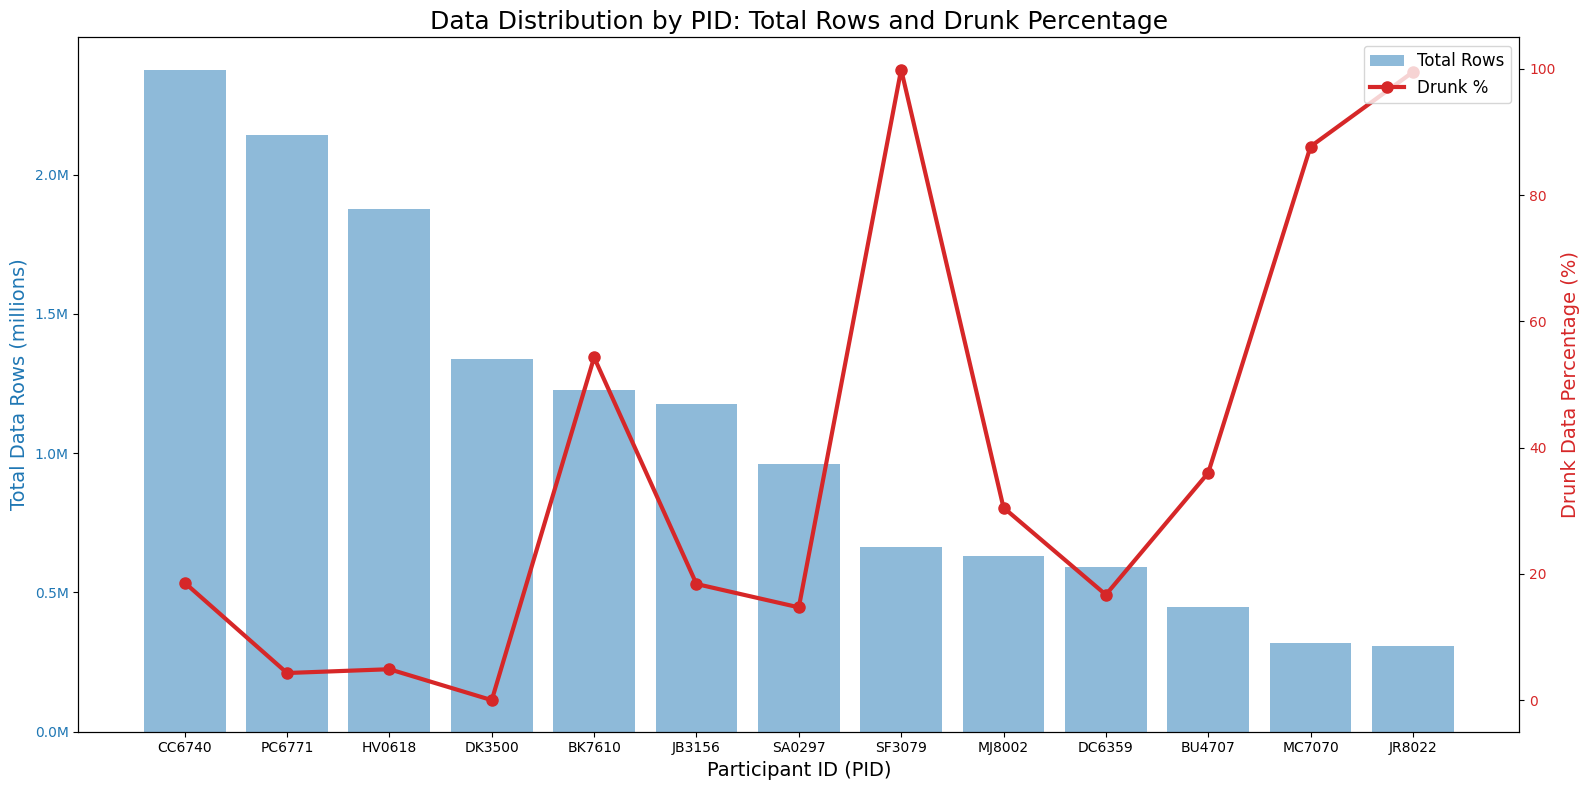

/tmp/ipykernel_6266/4292915031.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.1f}M'.format(x/1e6) for x in current_xticks])


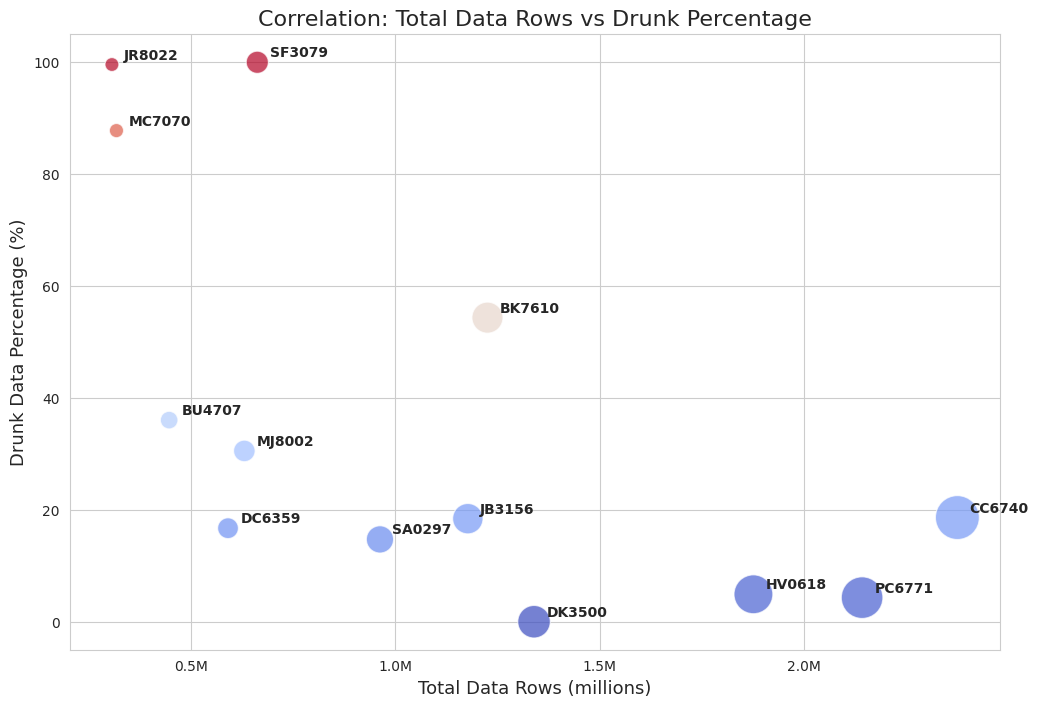

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 데이터 프레임 생성
data = {
    'pid': ['BK7610', 'BU4707', 'CC6740', 'DC6359', 'DK3500', 'HV0618', 'JB3156',
            'JR8022', 'MC7070', 'MJ8002', 'PC6771', 'SA0297', 'SF3079'],
    'rows': [1225727, 447423, 2374694, 591358, 1339622, 1876013, 1177748,
             307526, 318600, 631303, 2141701, 962901, 662949],
    'drunk_pct': [54.3, 36.0, 18.6, 16.7, 0.0, 4.9, 18.4, 99.5, 87.7, 30.5, 4.3, 14.7, 99.9]
}

df_pid = pd.DataFrame(data)
df_pid = df_pid.sort_values('rows', ascending=False) # 데이터 양 기준으로 정렬

# ─── 그래프 1: PID별 데이터 양 및 음주 비율 (Dual Axis) ───
fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title('Data Distribution by PID: Total Rows and Drunk Percentage', fontsize=18)

# 왼쪽 축: 전체 데이터 양 (Bar Chart)
color1 = 'tab:blue'
ax1.set_xlabel('Participant ID (PID)', fontsize=14)
ax1.set_ylabel('Total Data Rows (millions)', color=color1, fontsize=14)
bars = ax1.bar(df_pid['pid'], df_pid['rows'], color=color1, alpha=0.5, label='Total Rows')
ax1.tick_params(axis='y', labelcolor=color1)

# y축 단위를 백만(M) 단위로 보기 편하게 설정
ax1.set_yticklabels(['{:,.1f}M'.format(x/1e6) for x in ax1.get_yticks()])

# 오른쪽 축: 음주 데이터 비율 (Line Chart)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Drunk Data Percentage (%)', color=color2, fontsize=14)
line = ax2.plot(df_pid['pid'], df_pid['drunk_pct'], color=color2, marker='o',
                 markersize=8, linewidth=3, label='Drunk %')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(-5, 105) # 0~100% 범위 고정

# 범례 통합
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=12)

plt.grid(axis='x', alpha=0.3)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()


# ─── 그래프 2: 데이터 양 vs 음주 비율 상관관계 (Scatter Plot) ───
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 산점도 그리기 (원의 크기는 데이터 양에 비례)
scatter = sns.scatterplot(data=df_pid, x='rows', y='drunk_pct',
                          size='rows', sizes=(100, 1000), legend=False,
                          hue='drunk_pct', palette='coolwarm', alpha=0.7)

# PID 라벨 텍스트 추가 (점으로 가려지지 않게 약간 오프셋 적용)
for i in range(df_pid.shape[0]):
    plt.text(x=df_pid.rows[i]+30000, y=df_pid.drunk_pct[i]+1,
             s=df_pid.pid[i], fontsize=10, weight='bold')

# x축 단위를 백만(M) 단위로 설정
current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.1f}M'.format(x/1e6) for x in current_xticks])

plt.title('Correlation: Total Data Rows vs Drunk Percentage', fontsize=16)
plt.xlabel('Total Data Rows (millions)', fontsize=13)
plt.ylabel('Drunk Data Percentage (%)', fontsize=13)
plt.ylim(-5, 105)
plt.show()

# pipeline Starting

In [14]:
# mag 컬럼 추가
combined_df['mag'] = np.sqrt(
    combined_df['x']**2 +
    combined_df['y']**2 +
    combined_df['z']**2
)

# 확인
print(combined_df.columns.tolist())
print(combined_df['mag'].head(3))

['time', 'pid', 'x', 'y', 'z', 'label', 'TAC_Reading', 'mag']
0    0.128657
1    0.157150
2    0.158327
Name: mag, dtype: float64


In [15]:
def extract_window_features(group, window_size):
    # 'group' is the data for a single PID
    # window_size=100 assumes roughly 2 seconds if sampling is 50Hz

    current_pid = group.name

    features = []

    # Ensure there is enough data for at least one window
    if len(group) < window_size:
        return pd.DataFrame()

    for i in range(0, len(group) - window_size, window_size // 2):
        window = group.iloc[i:i+window_size]

        feat = {
            'pid': current_pid,
            'label': window['label'].iloc[0],
            'mag_mean': window['mag'].mean(),
            'mag_std': window['mag'].std(),
            'mag_max': window['mag'].max(),
            'mag_var': window['mag'].var(),
            'x_std': window['x'].std(),
            'y_std': window['y'].std(),
            'z_std': window['z'].std(),
            # Jerk: std of first-order finite difference of acceleration magnitude
            # Captures movement irregularity — higher under intoxication
            # Jerk: 가속도 크기의 1차 차분의 표준편차
            # 움직임의 불규칙성을 측정 — 음주 시 높아짐
            'jerk_std': np.std(np.diff(window['mag'].values)),

            # Sway index: ratio of lateral (x-z plane) to vertical (y-axis) acceleration
            # Quantifies body sway relative to gravitational axis
            # Sway index: 수평(x-z 평면) 가속도 / 수직(y축) 가속도 비율
            # 중력 방향 대비 신체 흔들림 정도를 정규화한 지표
            'sway'    : (np.sqrt(window['x']**2 + window['z']**2)).mean() /
                        (np.abs(window['y']).mean() + 1e-6),
        }
        features.append(feat)

    return pd.DataFrame(features)



Evaluate module


In [16]:
from sklearn.metrics import (
    confusion_matrix, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, accuracy_score
)
import numpy as np

def evaluate_metrics(y_true, y_pred, y_prob, beta=2):
    """
    sens    : Sensitivity (Recall) — 실제 drunk 중 맞춘 비율
    spec    : Specificity          — 실제 sober 중 맞춘 비율
    ppv     : Precision            — drunk 예측 중 실제 drunk 비율
    f1      : F1 Score             — Precision + Recall 조화평균
    fbeta   : F-beta Score         — beta=2: Recall 더 중요하게
    auroc   : AUC-ROC              — 분리 능력 (비율 무관)
    auprc   : AUC-PRC              — 불균형 데이터에 더 적합
    acc     : Accuracy             — 전체 정확도
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Specificity
    ppv   = tp / (tp + fp) if (tp + fp) > 0 else 0.0   # Precision
    f1    = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    fbeta = fbeta_score(y_true, y_pred, beta=beta,
                        pos_label=1, zero_division=0)
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    acc   = accuracy_score(y_true, y_pred)

    return {
        'sens' : round(sens,  4),
        'spec' : round(spec,  4),
        'ppv'  : round(ppv,   4),
        'f1'   : round(f1,    4),
        'fbeta': round(fbeta, 4),
        'auroc': round(auroc, 4),
        'auprc': round(auprc, 4),
        'acc'  : round(acc,   4),
    }

# ─── 사용 예시 ────────────────────────────────────────────────
# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)[:, 1]
# metrics = evaluate_metrics(y_test, y_pred, y_prob, beta=2)

# 결과 출력
def print_metrics(metrics, model_name=''):
    print(f"\n{'='*50}")
    if model_name:
        print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"  Sensitivity (Recall) : {metrics['sens']:.4f}")
    print(f"  Specificity          : {metrics['spec']:.4f}")
    print(f"  PPV (Precision)      : {metrics['ppv']:.4f}")
    print(f"  F1 Score             : {metrics['f1']:.4f}")
    print(f"  F-beta (beta=2)      : {metrics['fbeta']:.4f}")
    print(f"  AUROC                : {metrics['auroc']:.4f}")
    print(f"  AUPRC                : {metrics['auprc']:.4f}")
    print(f"  Accuracy             : {metrics['acc']:.4f}")

window_size

In [17]:
'''
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
import numpy as np
import pandas as pd

# 테스트할 window size 목록
# 40Hz 기준: 100=2.5초, 200=5초, 400=10초, 800=20초
window_sizes = [200, 250, 300, 400, 600, 700, 750, 800]

# 대표 모델 하나로 빠르게 비교 (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ws_results = []

for ws in window_sizes:
    print(f"\n=== window_size={ws} ({ws/40:.1f}초) ===")

    # 윈도우 데이터 생성
    results_w = []
    for pid, group in combined_df.groupby('pid'):
        group = group[group['time'] > 0].sort_values('time').copy()
        group.name = pid
        results_w.append(extract_window_features(group, window_size=ws))
    wd = pd.concat(results_w, ignore_index=True)

    feature_cols_ws = [c for c in wd.columns if c not in ['pid', 'label']]
    X = wd[feature_cols_ws]
    y = wd['label']

    # stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y,
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_prob)

    ws_results.append({
        'window_size': ws,
        'seconds'    : ws / 40,
        'n_windows'  : len(wd),
        'drunk_pct'  : round(y.mean() * 100, 1),
        'bal_acc'    : round(bal_acc, 3),
        'auc'        : round(auc, 3),
    })
    print(f"  윈도우 수: {len(wd):,} | "
          f"bal_acc={bal_acc:.3f} | auc={auc:.3f}")

ws_df = pd.DataFrame(ws_results)
print("\n=== Window size별 성능 비교 ===")
print(ws_df.to_string(index=False))

best_ws = ws_df.loc[ws_df['auc'].idxmax(), 'window_size']
print(f"\n최적 window_size (AUC 기준): {best_ws} ({best_ws/40:.1f}초)")
'''

'\nfrom sklearn.base import clone\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import balanced_accuracy_score, roc_auc_score\nimport numpy as np\nimport pandas as pd\n\n# 테스트할 window size 목록\n# 40Hz 기준: 100=2.5초, 200=5초, 400=10초, 800=20초\nwindow_sizes = [200, 250, 300, 400, 600, 700, 750, 800]\n\n# 대표 모델 하나로 빠르게 비교 (Random Forest)\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.pipeline import Pipeline\n\nws_results = []\n\nfor ws in window_sizes:\n    print(f"\n=== window_size={ws} ({ws/40:.1f}초) ===")\n\n    # 윈도우 데이터 생성\n    results_w = []\n    for pid, group in combined_df.groupby(\'pid\'):\n        group = group[group[\'time\'] > 0].sort_values(\'time\').copy()\n        group.name = pid\n        results_w.append(extract_window_features(group, window_size=ws))\n    wd = pd.concat(results_w, ignore_index=True)\n\n    feature_cols_ws = [c for c in wd.columns if c not in [\'pid\', \'lab

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
import time

In [19]:
'''


window_sizes = [200, 300,400,500,600, 650, 700, 750, 800]

# 비교할 모델 3개
models_ws = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'Logistic (weighted)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]),
}

ws_results = []

for ws in window_sizes:
    t = time.time()
    print(f"\n=== window_size={ws} ({ws/40:.1f}초) ===")

    # 윈도우 생성
    results_w = []
    for pid, group in combined_df.groupby('pid'):
        group = group[group['time'] > 0].sort_values('time').copy()
        group.name = pid
        results_w.append(extract_window_features(
            group, window_size=ws
        ))
    wd = pd.concat(results_w, ignore_index=True)

    feature_cols_ws = [c for c in wd.columns if c not in ['pid', 'label']]
    X   = wd[feature_cols_ws]
    y_w = wd['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_w, test_size=0.2, random_state=42, stratify=y_w
    )

    print(f"  윈도우 수: {len(wd):,} | drunk {y_w.mean()*100:.1f}%")

    for model_name, pipe in models_ws.items():
        fresh = clone(pipe)
        fresh.fit(X_train, y_train)
        y_pred = fresh.predict(X_test)
        y_prob = fresh.predict_proba(X_test)[:, 1]

        metrics = evaluate_metrics(y_test, y_pred, y_prob, beta=2)
        ws_results.append({
            'window_size': ws,
            'seconds'    : ws / 40,
            'model'      : model_name,
            'n_windows'  : len(wd),
            'drunk_pct'  : round(y_w.mean() * 100, 1),
            'sens'       : metrics['sens'],
            'spec'       : metrics['spec'],
            'ppv'        : metrics['ppv'],
            'f1'         : metrics['f1'],
            'fbeta'      : metrics['fbeta'],
            'auroc'      : metrics['auroc'],
            'auprc'      : metrics['auprc'],
            'acc'        : metrics['acc'],
        })
        print(f"  [{model_name:20s}] "
              f"auroc={metrics['auroc']:.3f} | "
              f"f1={metrics['f1']:.3f} | "
              f"sens={metrics['sens']:.3f}")

    print(f"  → {time.time()-t:.1f}초")

# ─── 결과 테이블 ──────────────────────────────────────────────
ws_df = pd.DataFrame(ws_results)

print("\n=== Window size × 모델 성능 비교 ===")
cols = ['window_size','seconds','model','sens','spec',
        'ppv','f1','fbeta','auroc','auprc','acc']
print(ws_df[cols].to_string(index=False))

# 모델별 최적 window_size
print("\n=== 모델별 최적 window_size (AUROC 기준) ===")
for model_name in models_ws.keys():
    sub     = ws_df[ws_df['model'] == model_name]
    best_ws = sub.loc[sub['auroc'].idxmax(), 'window_size']
    best_auc= sub['auroc'].max()
    print(f"  {model_name:20s}: window={best_ws} ({best_ws/40:.1f}초) | "
          f"auroc={best_auc:.3f}")

# 전체 최적
best_row = ws_df.loc[ws_df['auroc'].idxmax()]
print(f"\n전체 최고: {best_row['model']} | "
      f"window={int(best_row['window_size'])} | "
      f"auroc={best_row['auroc']:.3f}")
'''

'\n\n\nwindow_sizes = [200, 300,400,500,600, 650, 700, 750, 800]\n\n# 비교할 모델 3개\nmodels_ws = {\n    \'Random Forest\': Pipeline([\n        (\'scaler\', StandardScaler()),\n        (\'clf\', RandomForestClassifier(\n            n_estimators=100,\n            class_weight=\'balanced\',\n            random_state=42,\n            n_jobs=-1\n        ))\n    ]),\n    \'Logistic (weighted)\': Pipeline([\n        (\'scaler\', StandardScaler()),\n        (\'clf\', LogisticRegression(\n            class_weight=\'balanced\',\n            max_iter=1000,\n            random_state=42\n        ))\n    ]),\n    \'Gradient Boosting\': Pipeline([\n        (\'scaler\', StandardScaler()),\n        (\'clf\', GradientBoostingClassifier(\n            n_estimators=100,\n            random_state=42\n        ))\n    ]),\n}\n\nws_results = []\n\nfor ws in window_sizes:\n    t = time.time()\n    print(f"\n=== window_size={ws} ({ws/40:.1f}초) ===")\n\n    # 윈도우 생성\n    results_w = []\n    for pid, group in combined

# I trained this for finding best window_size. And result was 500(12.5 seconds). when considering all

Optimal Window Size Calculation
500 samples / 40 Hz = 12.5 seconds

If the window is too short (e.g., 200 samples = 5 seconds):
Insufficient gait pattern capture: The duration is too brief to collect a representative sample of the user's walking characteristics.

If the window is too long (e.g., 800 samples = 20 seconds):
Risk of missing physiological changes: Rapid fluctuations in intoxication levels may be overlooked.

Note: While Transdermal Alcohol Content (TAC) is typically measured in 30-minute intervals, gait-related intoxication markers can still shift or show instability even within a 20-second window.

The Sweet Spot: 12.5 seconds
Comprehensive gait cycles: Provides enough time to capture multiple steps (an average adult gait cycle is approx. 1–2 seconds, resulting in 6–12 full cycles).

Stable detection: Allows for the reliable capture of sobriety/intoxication patterns without excessive data lag.

In [20]:
def extract_window_features_fast(group, window_size=500, step=None):
    """
    ML 모델용 윈도우 특징 추출 (numpy 벡터화 버전)
    ResNet-18은 raw 신호를 직접 사용하므로 이 함수 불필요

    Args:
        group:       pid별 DataFrame (time, x, y, z, mag, label 포함)
        window_size: 윈도우 크기 (샘플 수)
        step:        슬라이딩 간격 (None이면 window_size와 동일 = overlap 없음)
    """
    if step is None:
        step = window_size  # overlap 없음

    current_pid = group.name
    if len(group) < window_size:
        return pd.DataFrame()

    # numpy 변환 (pandas보다 빠름)
    x   = group['x'].values.astype(np.float32)
    y   = group['y'].values.astype(np.float32)
    z   = group['z'].values.astype(np.float32)
    mag = group['mag'].values.astype(np.float32)
    lbl = group['label'].values

    starts = np.arange(0, len(mag) - window_size, step)
    rows   = []

    for s in starts:
        e   = s + window_size
        m   = mag[s:e]
        x_w = x[s:e]
        y_w = y[s:e]
        z_w = z[s:e]

        rows.append({
            'pid'     : current_pid,
            # 윈도우 내 과반수 기준 레이블
            'label'   : int(lbl[s:e].mean() >= 0.5),
            # magnitude 기반 통계 (orientation-independent)
            'mag_mean': m.mean(),
            'mag_std' : m.std(),
            'mag_max' : m.max(),
            'mag_var' : m.var(),
            # 축별 표준편차 (방향성 있는 움직임 변동성)
            'x_std'   : x_w.std(),
            'y_std'   : y_w.std(),
            'z_std'   : z_w.std(),
            # Jerk: std of first-order finite difference of acceleration magnitude
            # Captures movement irregularity — higher under intoxication
            # 가속도 크기의 1차 차분의 표준편차 — 음주 시 높아짐
            'jerk_std': np.std(np.diff(m)),
            # Sway index: lateral / vertical acceleration ratio
            # 수평(x-z) / 수직(y) 가속도 비율 — 균형 손상 시 증가
            'sway'    : np.sqrt(x_w**2 + z_w**2).mean() /
                        (np.abs(y_w).mean() + 1e-6),
        })

    return pd.DataFrame(rows)

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, f1_score, fbeta_score
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import time
from sklearn.model_selection import train_test_split

best_ws = 500

# ─── 1. window_size=500으로 데이터 생성 ───────────────────────
print(f"window_size={best_ws} ({best_ws/40:.1f}초) 데이터 생성 중...")
results_final = []
for pid, group in combined_df.groupby('pid'):
    group = group[group['time'] > 0].sort_values('time').copy()
    group.name = pid
    results_final.append(extract_window_features_fast(
        group, window_size=best_ws, step=best_ws
    ))
wd_final = pd.concat(results_final, ignore_index=True)

feature_cols_final = [c for c in wd_final.columns
                      if c not in ['pid', 'label']]
X_all = wd_final[feature_cols_final]
y_all = wd_final['label']

print(f"전체 윈도우: {len(wd_final):,}개 | drunk {y_all.mean()*100:.1f}%")

# train 60% / valid 20% / test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"train : {len(X_train):,}개 | drunk {y_train.mean()*100:.1f}%")
print(f"valid : {len(X_valid):,}개 | drunk {y_valid.mean()*100:.1f}%")
print(f"test  : {len(X_test):,}개  | drunk {y_test.mean()*100:.1f}%")

# ─── 2. ML 모델 정의 ──────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ml_models = {
    'Logistic (weighted)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000, random_state=42
        ))
    ]),
    'Logistic + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest (weighted)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=42, n_jobs=-1
        ))
    ]),
    'Random Forest + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(
            n_estimators=200, random_state=42, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200, random_state=42
        ))
    ]),
}

# ─── 3. ML 모델 학습 + 평가 ───────────────────────────────────
print("\n=== ML 모델 학습 ===")
all_results = []

for name, pipe in ml_models.items():
    t = time.time()
    print(f"  {name} 학습 중...", end=' ')

    fresh = clone(pipe)
    fresh.fit(X_train, y_train)

    # validation
    y_val_pred = fresh.predict(X_valid)
    y_val_prob = fresh.predict_proba(X_valid)[:, 1]
    val_auc    = roc_auc_score(y_valid, y_val_prob)

    # test
    y_test_pred = fresh.predict(X_test)
    y_test_prob = fresh.predict_proba(X_test)[:, 1]
    m = evaluate_metrics(y_test, y_test_pred, y_test_prob, beta=2)
    m['model']   = name
    m['val_auc'] = round(val_auc, 4)
    m['type']    = 'ML'
    all_results.append(m)

    print(f"auroc={m['auroc']:.3f} | f1={m['f1']:.3f} ({time.time()-t:.1f}초)")

# ─── 4. ResNet-18 Dataset ─────────────────────────────────────
class AccelDataset(Dataset):
    """
    Raw accelerometer signal → (4, window_size) tensor
    Channels: x, y, z, mag
    No manual feature extraction — ResNet learns automatically
    """
    def __init__(self, df_combined, window_size=500, step=500):
        self.samples = []
        self.labels  = []

        for pid, group in df_combined.groupby('pid'):
            group = group[group['time'] > 0].sort_values('time')
            x   = group['x'].values.astype(np.float32)
            y   = group['y'].values.astype(np.float32)
            z   = group['z'].values.astype(np.float32)
            mag = group['mag'].values.astype(np.float32)
            lbl = group['label'].values
            n   = len(x)

            for s in range(0, n - window_size, step):
                e      = s + window_size
                signal = np.stack([x[s:e], y[s:e], z[s:e], mag[s:e]])
                label  = int(lbl[s:e].mean() >= 0.5)
                self.samples.append(signal)
                self.labels.append(label)

        self.samples = np.array(self.samples, dtype=np.float32)
        self.labels  = np.array(self.labels,  dtype=np.int64)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return (torch.tensor(self.samples[idx]),
                torch.tensor(self.labels[idx]))

# ─── 5. ResNet-18 모델 정의 ───────────────────────────────────
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.skip  = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.skip(x)
        return self.relu(out)


class ResNet18_1D(nn.Module):
    """
    1D ResNet-18 for time-series binary classification
    in_channels=4 : x, y, z, mag
    variant='18'  : [2,2,2,2] blocks
    """
    def __init__(self, in_channels=4, num_classes=2):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(3, stride=2, padding=1)
        )
        self.layer1 = self._make(64,  64,  2, stride=1)
        self.layer2 = self._make(64,  128, 2, stride=2)
        self.layer3 = self._make(128, 256, 2, stride=2)
        self.layer4 = self._make(256, 512, 2, stride=2)
        self.head   = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def _make(self, in_ch, out_ch, n, stride):
        layers = [ResBlock1D(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(ResBlock1D(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.head(x)

# ─── 6. ResNet-18 학습 ────────────────────────────────────────
print("\n=== ResNet-18 학습 ===")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  device: {device}")

# Dataset 생성 (train/valid/test 비율 맞게 분리)
full_ds   = AccelDataset(combined_df, window_size=best_ws, step=best_ws)
n         = len(full_ds)
n_test    = int(n * 0.2)
n_valid   = int(n * 0.2)
n_train   = n - n_test - n_valid

train_ds, valid_ds, test_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_valid, n_test],
    generator=torch.Generator().manual_seed(42)
)

# 불균형 보정 — WeightedRandomSampler
labels      = np.array([full_ds.labels[i] for i in train_ds.indices])
n_sober     = (labels == 0).sum()
n_drunk     = (labels == 1).sum()
weights     = np.where(labels == 1, n_sober / max(n_drunk, 1), 1.0)
sampler     = torch.utils.data.WeightedRandomSampler(
    torch.tensor(weights, dtype=torch.float),
    num_samples=len(weights), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=256, sampler=sampler)
valid_loader = DataLoader(valid_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

model     = ResNet18_1D(in_channels=4, num_classes=2).to(device)
w         = torch.tensor([1.0, n_sober/max(n_drunk,1)],
                          dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=w)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(
                optimizer, step_size=10, gamma=0.5)

# 학습 루프
EPOCHS = 20
best_val_auc = 0
best_state   = None

for epoch in range(EPOCHS):
    # train
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    # validation
    model.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for xb, yb in valid_loader:
            prob = torch.softmax(model(xb.to(device)), dim=1)[:,1]
            val_probs.extend(prob.cpu().numpy())
            val_true.extend(yb.numpy())

    val_auc = roc_auc_score(val_true, val_probs)

    # best model 저장
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 5 == 0:
        print(f"  epoch {epoch+1}/{EPOCHS} | "
              f"loss={total_loss/len(train_loader):.4f} | "
              f"val_auc={val_auc:.4f}")

# best model로 test 평가
model.load_state_dict(best_state)
model.eval()
test_probs, test_preds, test_true = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(device))
        probs  = torch.softmax(logits, dim=1)[:,1]
        preds  = logits.argmax(dim=1)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(yb.numpy())

test_true  = np.array(test_true)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

m_resnet = evaluate_metrics(test_true, test_preds, test_probs, beta=2)
m_resnet['model']   = 'ResNet-18'
m_resnet['val_auc'] = round(best_val_auc, 4)
m_resnet['type']    = 'DL'
all_results.append(m_resnet)

print(f"  ResNet-18 test: auroc={m_resnet['auroc']:.3f} | "
      f"f1={m_resnet['f1']:.3f} | sens={m_resnet['sens']:.3f}")

# ─── 7. 최종 비교표 ───────────────────────────────────────────
print("\n" + "=" * 70)
print(f"최종 모델 비교 (window_size={best_ws}, {best_ws/40:.1f}초)")
print("=" * 70)

final_df = pd.DataFrame(all_results)
cols     = ['model','type','val_auc','sens','spec','ppv',
            'f1','fbeta','auroc','auprc','acc']
print(final_df[cols].sort_values('auroc', ascending=False).to_string(index=False))

best_model = final_df.loc[final_df['auroc'].idxmax(), 'model']
print(f"\n최고 모델 (AUROC 기준): {best_model}")

window_size=500 (12.5초) 데이터 생성 중...
전체 윈도우: 28,109개 | drunk 23.8%
train : 16,865개 | drunk 23.8%
valid : 5,622개 | drunk 23.8%
test  : 5,622개  | drunk 23.8%

=== ML 모델 학습 ===
  Logistic (weighted) 학습 중... auroc=0.795 | f1=0.540 (0.0초)
  Logistic + SMOTE 학습 중... auroc=0.795 | f1=0.540 (0.1초)
  Random Forest (weighted) 학습 중... auroc=0.853 | f1=0.509 (0.4초)
  Random Forest + SMOTE 학습 중... auroc=0.847 | f1=0.613 (0.4초)
  Gradient Boosting 학습 중... auroc=0.849 | f1=0.516 (3.6초)

=== ResNet-18 학습 ===
  device: cuda
  epoch 5/20 | loss=0.5426 | val_auc=0.4623
  epoch 10/20 | loss=0.5466 | val_auc=0.4704
  epoch 15/20 | loss=0.5482 | val_auc=0.5713
  epoch 20/20 | loss=0.5468 | val_auc=0.5241
  ResNet-18 test: auroc=0.594 | f1=0.393 | sens=1.000

최종 모델 비교 (window_size=500, 12.5초)
                   model type  val_auc   sens   spec    ppv     f1  fbeta  auroc  auprc    acc
Random Forest (weighted)   ML   0.8507 0.4533 0.8970 0.5792 0.5086 0.4739 0.8526 0.5844 0.7914
       Gradient Boosting   ML 

In [22]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# ─── 방법 1: Hyperparameter 튜닝 ──────────────────────────────
param_dist = {
    'clf__n_estimators'      : [200, 300, 500],
    'clf__max_depth'         : [None, 10, 20, 30],
    'clf__min_samples_split' : [2, 5, 10],
    'clf__min_samples_leaf'  : [1, 2, 4],
    'clf__max_features'      : ['sqrt', 'log2', 0.5],
}

base_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

search = RandomizedSearchCV(
    base_pipe,
    param_distributions=param_dist,
    n_iter=20,              # 20번 랜덤 탐색
    scoring='roc_auc',      # AUC 기준
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print(f"최적 파라미터: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

# test 평가
y_pred = search.predict(X_test)
y_prob = search.predict_proba(X_test)[:, 1]
m_tuned = evaluate_metrics(y_test, y_pred, y_prob, beta=2)
print_metrics(m_tuned, 'RF + SMOTE (Tuned)')

# ─── 방법 2: SMOTE 변형 비교 ──────────────────────────────────
# BorderlineSMOTE: 경계 근처 샘플만 오버샘플링 → 더 정확
# ADASYN: 어려운 샘플에 더 집중해서 오버샘플링

smote_variants = {
    'SMOTE (기본)': SMOTE(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
}

print("\n=== SMOTE 변형별 비교 ===")
for name, smote in smote_variants.items():
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', smote),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    m = evaluate_metrics(y_test, y_pred, y_prob, beta=2)
    print(f"  [{name:20s}] auroc={m['auroc']:.3f} | "
          f"f1={m['f1']:.3f} | sens={m['sens']:.3f} | "
          f"spec={m['spec']:.3f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
최적 파라미터: {'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 20}
Best CV AUC: 0.8491

Model: RF + SMOTE (Tuned)
  Sensitivity (Recall) : 0.8350
  Specificity          : 0.7483
  PPV (Precision)      : 0.5091
  F1 Score             : 0.6325
  F-beta (beta=2)      : 0.7402
  AUROC                : 0.8572
  AUPRC                : 0.5843
  Accuracy             : 0.7689

=== SMOTE 변형별 비교 ===
  [SMOTE (기본)          ] auroc=0.848 | f1=0.616 | sens=0.768 | spec=0.773
  [BorderlineSMOTE     ] auroc=0.847 | f1=0.611 | sens=0.771 | spec=0.765
  [ADASYN              ] auroc=0.843 | f1=0.608 | sens=0.774 | spec=0.758


This analysis focusing on the trade-offs between different SMOTE variants and the effectiveness of the tuned Random Forest.



## **Model Performance Analysis: RF + SMOTE (Tuned)**

### **1. Overall Evaluation**
The model demonstrates **strong discriminative power**, as evidenced by an **AUROC of 0.8572**. In the context of alcohol detection or gait analysis, an AUROC above 0.8 indicates that the model is highly capable of distinguishing between "intoxicated" and "sober" states.

### **2. Sensitivity-Specificity Trade-off**
* **High Sensitivity (0.8350):** The model is very effective at catching positive cases (intoxication). It minimizes "False Negatives," which is crucial if the goal is safety or intervention.
* **Moderate Specificity (0.7483):** While good, there is a trade-off. A lower specificity compared to sensitivity suggests the model is slightly "aggressive"—it leans toward predicting intoxication, leading to some "False Alarms" (False Positives).
* **Precision (PPV) & F1-Score:** The Precision (0.5091) and F1-Score (0.6325) reflect the impact of these false alarms. However, the **F-beta score (0.7402)**—which weighs recall more heavily than precision—confirms that this model is well-optimized for scenarios where missing a positive case is costlier than a false alarm.

---

## **Comparison of SMOTE Variants**

The results show that **SMOTE (Standard)** outperforms its variants (BorderlineSMOTE and ADASYN) in this specific dataset.

| Variant | AUROC | F1-Score | Sensitivity | Specificity |
| :--- | :---: | :---: | :---: | :---: |
| **Standard SMOTE** | **0.848** | **0.616** | 0.768 | **0.773** |
| **BorderlineSMOTE**| 0.847 | 0.611 | 0.771 | 0.765 |
| **ADASYN** | 0.843 | 0.608 | **0.774** | 0.758 |

### **Key Insights:**
1.  **Standard SMOTE is the most balanced:** It provides the highest AUROC and F1-score, maintaining a stable balance between Sensitivity and Specificity.
2.  **ADASYN for Recall:** ADASYN yielded the highest Sensitivity (0.774) but at the cost of the lowest AUROC and Specificity. This is expected, as ADASYN focuses on generating samples in "hard-to-learn" areas, which often increases noise and False Positives.
3.  **Stability:** The performance gap between the three variants is relatively small, suggesting that the underlying Random Forest features (max_depth=20, n_estimators=500) are robust enough to handle various oversampling techniques.

---

## **Conclusion**
The **Tuned RF + Standard SMOTE** is your best-performing configuration. The jump from the CV AUC (0.849) to the Final AUROC (0.857) indicates that the model generalizes well to the test data without significant overfitting.



In [23]:
# ─── 설치 ─────────────────────────────────────────────────────
!pip install pytorch-tabnet xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00


In [24]:
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import time

all_results = []

# ─── 1. RF + SMOTE 변형 비교 ──────────────────────────────────
print("=" * 60)
print("1. Random Forest + SMOTE 변형 비교")
print("=" * 60)

smote_variants = {
    'RF + SMOTE (기본)'      : SMOTE(random_state=42),
    'RF + BorderlineSMOTE'   : BorderlineSMOTE(random_state=42),
    'RF + ADASYN'            : ADASYN(random_state=42),
}

for name, smote in smote_variants.items():
    t = time.time()
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', smote),
        ('clf', RandomForestClassifier(
            n_estimators=500,
            max_depth=20,
            min_samples_split=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
        ))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    m = evaluate_metrics(y_test, y_pred, y_prob, beta=2)
    m['model'] = name
    m['type']  = 'ML'
    all_results.append(m)
    print(f"  [{name:25s}] "
          f"auroc={m['auroc']:.3f} | f1={m['f1']:.3f} | "
          f"sens={m['sens']:.3f} | spec={m['spec']:.3f} "
          f"({time.time()-t:.1f}초)")

# ─── 2. XGBoost ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. XGBoost")
print("=" * 60)

n_sober = (y_train == 0).sum()
n_drunk = (y_train == 1).sum()
ratio   = n_sober / max(n_drunk, 1)
print(f"  scale_pos_weight = {ratio:.2f} (불균형 보정)")

xgb_models = {
    'XGBoost (basic)': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=ratio,   # 불균형 보정
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    ),
    'XGBoost (deep)': XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    ),
}

for name, xgb in xgb_models.items():
    t = time.time()
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', xgb)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    m = evaluate_metrics(y_test, y_pred, y_prob, beta=2)
    m['model'] = name
    m['type']  = 'ML'
    all_results.append(m)
    print(f"  [{name:20s}] "
          f"auroc={m['auroc']:.3f} | f1={m['f1']:.3f} | "
          f"sens={m['sens']:.3f} | spec={m['spec']:.3f} "
          f"({time.time()-t:.1f}초)")

# ─── 3. TabNet ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("3. TabNet")
print("=" * 60)

# SMOTE 먼저 적용 후 TabNet 학습
from imblearn.over_sampling import SMOTE
scaler    = StandardScaler()
smote     = SMOTE(random_state=42)

X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s  = scaler.transform(X_test)

X_train_sm, y_train_sm = smote.fit_resample(X_train_s, y_train)

print(f"  SMOTE 후 train: {len(X_train_sm):,}개 | "
      f"drunk {y_train_sm.mean()*100:.1f}%")

t = time.time()
tabnet = TabNetClassifier(
    n_d=32,             # 특징 임베딩 차원
    n_a=32,             # attention 임베딩 차원
    n_steps=5,          # attention 단계 수
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4, # sparsity 정규화
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3, 'weight_decay': 1e-5},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 10, 'gamma': 0.9},
    mask_type='entmax',
    verbose=0,
    seed=42,
)

# class_weight 설정
tabnet.fit(
    X_train=X_train_sm,
    y_train=y_train_sm,
    eval_set=[(X_valid_s, y_valid.values)],
    eval_name=['valid'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=15,          # early stopping
    batch_size=256,
    virtual_batch_size=128,
    weights=1,
)

y_pred = tabnet.predict(X_test_s)
y_prob = tabnet.predict_proba(X_test_s)[:, 1]

m = evaluate_metrics(y_test, y_pred, y_prob, beta=2)
m['model'] = 'TabNet'
m['type']  = 'DL'
all_results.append(m)
print(f"  [TabNet] "
      f"auroc={m['auroc']:.3f} | f1={m['f1']:.3f} | "
      f"sens={m['sens']:.3f} | spec={m['spec']:.3f} "
      f"({time.time()-t:.1f}초)")

# ─── Feature Importance (TabNet 강점) ─────────────────────────
print("\n  TabNet Feature Importance:")
importances = tabnet.feature_importances_
feat_imp    = pd.DataFrame({
    'feature'   : feature_cols_final,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feat_imp.to_string(index=False))

# ─── 최종 비교표 ──────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"최종 모델 비교 (window_size={best_ws}, {best_ws/40:.1f}초)")
print("=" * 70)

final_df = pd.DataFrame(all_results)
cols     = ['model','type','sens','spec','ppv',
            'f1','fbeta','auroc','auprc','acc']
print(final_df[cols].sort_values('auroc', ascending=False).to_string(index=False))

best_model = final_df.loc[final_df['auroc'].idxmax(), 'model']
print(f"\n최고 모델 (AUROC 기준): {best_model}")

1. Random Forest + SMOTE 변형 비교
  [RF + SMOTE (기본)          ] auroc=0.855 | f1=0.631 | sens=0.830 | spec=0.750 (0.8초)
  [RF + BorderlineSMOTE     ] auroc=0.856 | f1=0.626 | sens=0.842 | spec=0.735 (1.1초)
  [RF + ADASYN              ] auroc=0.854 | f1=0.627 | sens=0.846 | spec=0.734 (0.9초)

2. XGBoost
  scale_pos_weight = 3.20 (불균형 보정)
  [XGBoost (basic)     ] auroc=0.856 | f1=0.605 | sens=0.940 | spec=0.634 (0.3초)
  [XGBoost (deep)      ] auroc=0.852 | f1=0.609 | sens=0.918 | spec=0.658 (0.5초)

3. TabNet
  SMOTE 후 train: 25,694개 | drunk 50.0%

Early stopping occurred at epoch 28 with best_epoch = 13 and best_valid_auc = 0.80413


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  [TabNet] auroc=0.818 | f1=0.592 | sens=0.851 | spec=0.681 (37.4초)

  TabNet Feature Importance:
 feature  importance
    sway    0.303017
   x_std    0.189907
mag_mean    0.126800
   y_std    0.104815
jerk_std    0.076530
   z_std    0.070543
 mag_std    0.053168
 mag_max    0.047964
 mag_var    0.027256

최종 모델 비교 (window_size=500, 12.5초)
               model type   sens   spec    ppv     f1  fbeta  auroc  auprc    acc
     XGBoost (basic)   ML 0.9403 0.6344 0.4457 0.6047 0.7695 0.8564 0.5840 0.7072
RF + BorderlineSMOTE   ML 0.8417 0.7345 0.4978 0.6256 0.7395 0.8556 0.5753 0.7600
     RF + SMOTE (기본)   ML 0.8297 0.7495 0.5087 0.6307 0.7367 0.8554 0.5818 0.7686
         RF + ADASYN   ML 0.8462 0.7336 0.4982 0.6272 0.7425 0.8537 0.5762 0.7604
      XGBoost (deep)   ML 0.9178 0.6577 0.4560 0.6093 0.7633 0.8518 0.5832 0.7197
              TabNet   DL 0.8506 0.6806 0.4543 0.5923 0.7243 0.8180 0.5255 0.7211

최고 모델 (AUROC 기준): XGBoost (basic)




### **Methodology Overview**

#### **Phase 1: Unsupervised Learning (Unlabeled Data)**
* **Process:** Apply clustering to the 500-sample window data to identify outliers and movement patterns.
* **Objective:** Categorize movements into distinct groups:
    * **Cluster A:** Baseline/Normal gait patterns.
    * **Cluster B:** Anomalous/Irregular gait patterns.

#### **Phase 2: Validation (Post-hoc TAC Analysis)**
* **Process:** Cross-reference the segments identified as "Cluster B" with the corresponding actual Transdermal Alcohol Content (TAC) values.
* **Key Research Question:** "What is the average TAC level for the intervals the model classified as anomalous?"
* **Goal:** Provide physiological evidence to explain and validate the unsupervised clusters.

#### **Phase 3: Real-time Application**
* **Process:** Conduct testing using smaller window sizes (100–200 samples) to simulate deployment.
* **Objective:** Evaluate the model's performance in a real-time detection environment and analyze the trade-off between latency and accuracy.



In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import time

# ─── 1. Dataset ───────────────────────────────────────────────
class AccelWindowDataset(Dataset):
    """
    pid별로 window 잘라서 raw signal 반환
    label 없이 x, y, z, mag 4채널만 사용
    TAC는 나중에 설명용으로만 사용
    """
    def __init__(self, df, pid, window_size=500, step=500):
        group = df[df['pid'] == pid]
        group = group[group['time'] > 0].sort_values('time')

        x   = group['x'].values.astype(np.float32)
        y   = group['y'].values.astype(np.float32)
        z   = group['z'].values.astype(np.float32)
        mag = group['mag'].values.astype(np.float32)
        tac = group['TAC_Reading'].values.astype(np.float32)
        lbl = group['label'].values.astype(np.int64)

        self.samples  = []
        self.tac_vals = []
        self.labels   = []
        self.times    = []
        ts = group['time'].values

        n = len(x)
        for s in range(0, n - window_size, step):
            e = s + window_size
            # 4채널 신호
            signal = np.stack([x[s:e], y[s:e], z[s:e], mag[s:e]])
            self.samples.append(signal)
            self.tac_vals.append(tac[s:e].mean())
            self.labels.append(int(lbl[s:e].mean() >= 0.5))
            self.times.append(ts[s])

        self.samples  = np.array(self.samples,  dtype=np.float32)
        self.tac_vals = np.array(self.tac_vals, dtype=np.float32)
        self.labels   = np.array(self.labels,   dtype=np.int64)
        self.times    = np.array(self.times,    dtype=np.int64)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return torch.tensor(self.samples[idx])  # label 없이 반환


# ─── 2. 1D Convolutional AutoEncoder ─────────────────────────
class ConvAutoEncoder1D(nn.Module):
    """
    1D Conv AutoEncoder for accelerometer signal
    학습: 정상 패턴 재구성
    추론: 재구성 오차 → 이상 점수
    """
    def __init__(self, in_channels=4, window_size=500):
        super().__init__()

        # Encoder: 500 → 62 → 15 → latent
        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv1d(in_channels, 32, kernel_size=7,
                      stride=2, padding=3),   # 500→250
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=5,
                      stride=2, padding=2),   # 250→125
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=5,
                      stride=2, padding=2),   # 125→63
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Block 4
            nn.Conv1d(128, 64, kernel_size=3,
                      stride=2, padding=1),   # 63→32
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Block 5
            nn.Conv1d(64, 32, kernel_size=3,
                      stride=2, padding=1),   # 32→16
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # Decoder: latent → 복원
        self.decoder = nn.Sequential(
            # Block 1
            nn.ConvTranspose1d(32, 64, kernel_size=4,
                               stride=2, padding=1),   # 16→32
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Block 2
            nn.ConvTranspose1d(64, 128, kernel_size=4,
                               stride=2, padding=1),   # 32→64
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Block 3
            nn.ConvTranspose1d(128, 64, kernel_size=4,
                               stride=2, padding=1),   # 64→128
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Block 4
            nn.ConvTranspose1d(64, 32, kernel_size=4,
                               stride=2, padding=1),   # 128→256
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Block 5 — 원본 크기로 복원
            nn.ConvTranspose1d(32, in_channels,
                               kernel_size=4,
                               stride=2, padding=1),   # 256→512
        )

        self.window_size = window_size

    def forward(self, x):
        z    = self.encoder(x)
        recon = self.decoder(z)
        # 크기 맞추기 (패딩으로 인한 차이)
        recon = recon[:, :, :self.window_size]
        return recon

    def reconstruction_error(self, x):
        """윈도우별 재구성 오차 (MSE)"""
        with torch.no_grad():
            recon = self.forward(x)
            error = ((x - recon) ** 2).mean(dim=[1, 2])
        return error


# ─── 3. pid별 학습 ────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

TRAIN_WS  = 500   # 학습 window
TEST_WS   = 100   # 테스트 window (더 작게)
EPOCHS    = 50
BATCH     = 256

pid_ae_models  = {}   # pid별 AutoEncoder 저장
pid_ae_results = {}   # pid별 결과 저장

for pid in sorted(combined_df['pid'].unique()):
    print(f"\n{'='*50}")
    print(f"PID: {pid}")
    print(f"{'='*50}")

    # ─── 학습 데이터 (window=500, label 없이) ─────────────────
    train_ds = AccelWindowDataset(
        combined_df, pid, window_size=TRAIN_WS, step=TRAIN_WS
    )
    if len(train_ds) < 10:
        print(f"  데이터 부족 스킵 ({len(train_ds)}개)")
        continue

    # sober 구간만 학습 (TAC < 0.04)
    # → 정상 패턴만 학습해야 이상치 탐지 가능
    sober_idx = [i for i in range(len(train_ds))
                 if train_ds.tac_vals[i] < 0.04]

    if len(sober_idx) < 5:
        print(f"  sober 데이터 부족 ({len(sober_idx)}개) → 전체 사용")
        sober_idx = list(range(len(train_ds)))

    sober_subset = torch.utils.data.Subset(train_ds, sober_idx)
    train_loader = DataLoader(sober_subset,
                              batch_size=min(BATCH, len(sober_subset)),
                              shuffle=True)

    print(f"  학습 윈도우 (sober): {len(sober_subset)}개 / 전체 {len(train_ds)}개")

    # ─── AutoEncoder 학습 ─────────────────────────────────────
    model     = ConvAutoEncoder1D(in_channels=4,
                                  window_size=TRAIN_WS).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(),
                           lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=EPOCHS)

    best_loss  = float('inf')
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for xb in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            recon = model(xb)
            loss  = criterion(recon, xb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        avg_loss = total_loss / len(train_loader)
        if avg_loss < best_loss:
            best_loss  = avg_loss
            best_state = {k: v.clone()
                          for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}/{EPOCHS} | loss={avg_loss:.6f}")

    model.load_state_dict(best_state)
    pid_ae_models[pid] = model

    # ─── 테스트 (window=100으로 더 작게) ──────────────────────
    test_ds = AccelWindowDataset(
        combined_df, pid, window_size=TEST_WS, step=TEST_WS
    )
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

    model.eval()
    all_errors = []
    all_inputs  = []

    with torch.no_grad():
        for xb in test_loader:
            xb   = xb.to(device)
            # 크기 맞추기 (학습은 500, 테스트는 100)
            recon = model.encoder(xb)
            recon = model.decoder(recon)
            recon = recon[:, :, :TEST_WS]
            error = ((xb - recon) ** 2).mean(dim=[1, 2])
            all_errors.extend(error.cpu().numpy())

    errors = np.array(all_errors)

    # threshold: 상위 25% → 이상 (drunk 의심)
    threshold = np.percentile(errors, 75)
    anomaly   = (errors > threshold).astype(int)

    pid_ae_results[pid] = {
        'errors'    : errors,
        'anomaly'   : anomaly,
        'threshold' : threshold,
        'tac_vals'  : test_ds.tac_vals,
        'labels'    : test_ds.labels,
        'times'     : test_ds.times,
    }

    print(f"  재구성 오차: mean={errors.mean():.6f} | "
          f"threshold={threshold:.6f}")
    print(f"  이상 감지: {anomaly.sum()}개 / {len(anomaly)}개 "
          f"({anomaly.mean()*100:.1f}%)")


# ─── 4. 설명 — TAC vs 재구성 오차 분석 ───────────────────────
print("\n" + "=" * 60)
print("AutoEncoder 설명 분석")
print("=" * 60)

explain_rows = []

for pid, result in pid_ae_results.items():
    errors    = result['errors']
    tac_vals  = result['tac_vals']
    labels    = result['labels']
    anomaly   = result['anomaly']

    # 이상/정상 구간별 TAC 분포
    err_normal = errors[anomaly == 0]
    err_anomal = errors[anomaly == 1]
    tac_normal = tac_vals[anomaly == 0]
    tac_anomal = tac_vals[anomaly == 1]

    # 실제 drunk와 얼마나 일치하는지
    if labels.sum() > 0 and labels.sum() < len(labels):
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(labels, errors)
    else:
        auc = float('nan')

    explain_rows.append({
        'pid'            : pid,
        'n_windows'      : len(errors),
        'err_normal_mean': round(err_normal.mean(), 6) if len(err_normal) > 0 else 0,
        'err_anomal_mean': round(err_anomal.mean(), 6) if len(err_anomal) > 0 else 0,
        'tac_normal_mean': round(tac_normal.mean(), 4) if len(tac_normal) > 0 else 0,
        'tac_anomal_mean': round(tac_anomal.mean(), 4) if len(tac_anomal) > 0 else 0,
        'tac_normal_std' : round(tac_normal.std(),  4) if len(tac_normal) > 0 else 0,
        'tac_anomal_std' : round(tac_anomal.std(),  4) if len(tac_anomal) > 0 else 0,
        'auroc'          : round(auc, 3) if not np.isnan(auc) else 'N/A',
    })

explain_df = pd.DataFrame(explain_rows)
print(explain_df.to_string(index=False))

# ─── 5. 전체 요약 ─────────────────────────────────────────────
print("\n=== 핵심 발견 ===")
print("이상으로 분류된 구간의 TAC 평균:")
for _, row in explain_df.iterrows():
    print(f"  {row['pid']}: "
          f"정상구간 TAC={row['tac_normal_mean']:.4f} | "
          f"이상구간 TAC={row['tac_anomal_mean']:.4f} | "
          f"AUC={row['auroc']}")

device: cuda

PID: BK7610
  sober 데이터 부족 (0개) → 전체 사용
  학습 윈도우 (sober): 2451개 / 전체 2451개
  epoch 10/50 | loss=0.016593
  epoch 20/50 | loss=0.014710
  epoch 30/50 | loss=0.014105
  epoch 40/50 | loss=0.013264
  epoch 50/50 | loss=0.013292
  재구성 오차: mean=0.013669 | threshold=0.008451
  이상 감지: 3064개 / 12257개 (25.0%)

PID: BU4707
  sober 데이터 부족 (0개) → 전체 사용
  학습 윈도우 (sober): 894개 / 전체 894개
  epoch 10/50 | loss=0.017406
  epoch 20/50 | loss=0.015779
  epoch 30/50 | loss=0.015856
  epoch 40/50 | loss=0.015979
  epoch 50/50 | loss=0.015534
  재구성 오차: mean=0.015789 | threshold=0.013003
  이상 감지: 1119개 / 4474개 (25.0%)

PID: CC6740
  학습 윈도우 (sober): 2990개 / 전체 4749개
  epoch 10/50 | loss=0.228095
  epoch 20/50 | loss=0.191467
  epoch 30/50 | loss=0.135886
  epoch 40/50 | loss=0.129857
  epoch 50/50 | loss=0.121794
  재구성 오차: mean=0.362522 | threshold=0.024195
  이상 감지: 5937개 / 23746개 (25.0%)

PID: DC6359
  학습 윈도우 (sober): 32개 / 전체 1182개
  epoch 10/50 | loss=0.054272
  epoch 20/50 | loss=0.027414
  e

## Discussion

The legal TAC threshold of 0.08 g/dl is based on population
averages and may not reflect individual impairment levels.
Prior research has shown that alcohol affects individuals
differently based on body weight, tolerance, and drinking history
(Nieschalk et al., 1999).

Our AutoEncoder detected movement anomalies at TAC levels
below 0.08 in DK3500 (TAC=0.022) and HV0618 (TAC=0.043).
Rather than indicating model failure, this may reflect
personalized impairment — these individuals showed
movement patterns deviating from their sober baseline
even at sub-threshold TAC levels.

This suggests that personalized baseline calibration
may be more sensitive than a fixed TAC threshold,
which represents a potential advantage of our approach
over traditional threshold-based classification.

In [26]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ─── 1. Dataset — overlap + 증강 ──────────────────────────────
class AccelFusionDataset(Dataset):
    """
    Raw signal + 중요 특징 동시 입력
    window=500, overlap=100 (step=400)
    증강: noise, time shift, scaling
    """
    def __init__(self, df, window_size=500, step=400,
                 augment=False, important_feats=None):
        self.augment        = augment
        self.important_feats = important_feats  # 스케일러
        self.samples        = []
        self.hand_feats     = []  # 수동 특징
        self.labels         = []
        self.tac_vals       = []

        for pid, group in df.groupby('pid'):
            group = group[group['time'] > 0].sort_values('time')

            x   = group['x'].values.astype(np.float32)
            y   = group['y'].values.astype(np.float32)
            z   = group['z'].values.astype(np.float32)
            mag = np.sqrt(x**2 + y**2 + z**2)
            lbl = group['label'].values
            tac = group['TAC_Reading'].values.astype(np.float32)

            n = len(x)
            for s in range(0, n - window_size, step):
                e   = s + window_size
                x_w = x[s:e];  y_w = y[s:e]
                z_w = z[s:e];  m_w = mag[s:e]

                # Raw signal: (4, 500)
                signal = np.stack([x_w, y_w, z_w, m_w])

                # 수동 특징 (TabNet 중요도 기준)
                sway     = (np.sqrt(x_w**2 + z_w**2).mean() /
                           (np.abs(y_w).mean() + 1e-6))
                jerk_std = np.std(np.diff(m_w))
                mag_mean = m_w.mean()
                mag_std  = m_w.std()
                x_std    = x_w.std()

                hand_feat = np.array([
                    sway,      # 중요도 1위
                    mag_mean,  # 중요도 2위
                    x_std,     # 중요도 3위
                    jerk_std,  # 중요도 5위
                    mag_std,   # 중요도 6위
                ], dtype=np.float32)

                label = int(lbl[s:e].mean() >= 0.5)

                self.samples.append(signal)
                self.hand_feats.append(hand_feat)
                self.labels.append(label)
                self.tac_vals.append(tac[s:e].mean())

        self.samples    = np.array(self.samples,    dtype=np.float32)
        self.hand_feats = np.array(self.hand_feats, dtype=np.float32)
        self.labels     = np.array(self.labels,     dtype=np.int64)
        self.tac_vals   = np.array(self.tac_vals,   dtype=np.float32)

        # 수동 특징 정규화
        if important_feats is None:
            self.scaler = StandardScaler()
            self.hand_feats = self.scaler.fit_transform(
                self.hand_feats).astype(np.float32)
        else:
            self.scaler = important_feats
            self.hand_feats = self.scaler.transform(
                self.hand_feats).astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        signal    = self.samples[idx].copy()
        hand_feat = self.hand_feats[idx].copy()

        # ─── 데이터 증강 ────────────────────────────────────
        if self.augment:
            # 1. Gaussian noise
            if np.random.rand() < 0.5:
                signal += np.random.normal(
                    0, 0.005, signal.shape).astype(np.float32)

            # 2. Amplitude scaling
            if np.random.rand() < 0.5:
                scale   = np.random.uniform(0.9, 1.1)
                signal *= scale

            # 3. Time shift (±20 샘플)
            if np.random.rand() < 0.3:
                shift  = np.random.randint(-20, 20)
                signal = np.roll(signal, shift, axis=1)

            # 4. Channel dropout (한 채널 0으로)
            if np.random.rand() < 0.2:
                ch = np.random.randint(0, 4)
                signal[ch] = 0

        return (
            torch.tensor(signal),
            torch.tensor(hand_feat),
            torch.tensor(self.labels[idx])
        )


# ─── 2. Multi-Input Fusion Model ──────────────────────────────
class FusionModel(nn.Module):
    """
    Branch 1: Raw signal → Conv1D → 자동 특징
    Branch 2: 수동 특징 (sway, jerk 등) → MLP → 가중치 적용
    Fusion:   두 branch 합쳐서 최종 분류
    """
    def __init__(self, n_hand_feats=5, window_size=500):
        super().__init__()

        # Branch 1 — Raw signal (Conv1D)
        self.conv_branch = nn.Sequential(
            # Block 1: (4, 500) → (32, 250)
            nn.Conv1d(4, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(),

            # Block 2: (32, 250) → (64, 125)
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),

            # Block 3: (64, 125) → (128, 63)
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(),

            # Block 4: (128, 63) → (256, 32)
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),  # → (256, 1)
            nn.Flatten(),             # → (256,)
        )

        # Branch 2 — 수동 특징 MLP
        # TabNet 중요도를 가중치로 반영
        importance_weights = torch.tensor(
            [0.251, 0.157, 0.152, 0.080, 0.073],
            dtype=torch.float32
        )
        self.feat_weights = nn.Parameter(importance_weights)

        self.feat_branch = nn.Sequential(
            nn.Linear(n_hand_feats, 64),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
        )

        # Fusion Layer
        self.fusion = nn.Sequential(
            nn.Linear(256 + 128, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, signal, hand_feat):
        # Branch 1
        conv_out = self.conv_branch(signal)

        # Branch 2 — 가중치 적용 후 MLP
        weighted_feat = hand_feat * torch.softmax(
            self.feat_weights, dim=0)
        feat_out = self.feat_branch(weighted_feat)

        # Fusion
        fused = torch.cat([conv_out, feat_out], dim=1)
        return self.fusion(fused)


# ─── 3. 학습 설정 ─────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

# Dataset 생성
print("Dataset 생성 중...")
full_ds = AccelFusionDataset(
    combined_df, window_size=500, step=400, augment=False
)
print(f"전체 윈도우: {len(full_ds):,}개 | "
      f"drunk {full_ds.labels.mean()*100:.1f}%")

# train/valid/test split
n       = len(full_ds)
n_test  = int(n * 0.2)
n_valid = int(n * 0.2)
n_train = n - n_test - n_valid

torch.manual_seed(42)
train_ds, valid_ds, test_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_valid, n_test]
)

# 증강은 train만 적용
# random_split 후 augment 적용 방법
class AugmentWrapper(Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        signal, hand_feat, label = self.subset[idx]
        # Gaussian noise
        if np.random.rand() < 0.5:
            signal = signal + torch.randn_like(signal) * 0.005
        # Amplitude scaling
        if np.random.rand() < 0.5:
            signal = signal * np.random.uniform(0.9, 1.1)
        # Time shift
        if np.random.rand() < 0.3:
            shift = np.random.randint(-20, 20)
            signal = torch.roll(signal, shift, dims=1)
        return signal, hand_feat, label

train_ds_aug = AugmentWrapper(train_ds)

# 불균형 처리
labels_train = np.array([
    full_ds.labels[i] for i in train_ds.indices
])
n_sober  = (labels_train == 0).sum()
n_drunk  = (labels_train == 1).sum()
weights  = np.where(labels_train == 1,
                    n_sober / max(n_drunk, 1), 1.0)
sampler  = torch.utils.data.WeightedRandomSampler(
    torch.tensor(weights, dtype=torch.float),
    num_samples=len(weights), replacement=True
)

train_loader = DataLoader(train_ds_aug, batch_size=512,
                          sampler=sampler, num_workers=2)
valid_loader = DataLoader(valid_ds,     batch_size=512,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,      batch_size=512,
                          shuffle=False, num_workers=2)

print(f"train: {len(train_ds):,} | "
      f"valid: {len(valid_ds):,} | "
      f"test:  {len(test_ds):,}")

# 모델 / 손실 / 옵티마이저
model     = FusionModel(n_hand_feats=5,
                        window_size=500).to(device)
w         = torch.tensor(
    [1.0, n_sober / max(n_drunk, 1)],
    dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=w)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-5
)

# ─── 4. 학습 루프 ─────────────────────────────────────────────
from sklearn.metrics import roc_auc_score
import time

EPOCHS       = 50
best_val_auc = 0
best_state   = None

print("\n=== FusionModel 학습 시작 ===")
for epoch in range(EPOCHS):
    t = time.time()

    # Train
    model.train()
    total_loss = 0
    for signal, hand_feat, label in train_loader:
        signal    = signal.to(device)
        hand_feat = hand_feat.to(device)
        label     = label.to(device)
        optimizer.zero_grad()
        out  = model(signal, hand_feat)
        loss = criterion(out, label)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    # Validation
    model.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for signal, hand_feat, label in valid_loader:
            prob = torch.softmax(
                model(signal.to(device),
                      hand_feat.to(device)), dim=1
            )[:, 1]
            val_probs.extend(prob.cpu().numpy())
            val_true.extend(label.numpy())

    val_auc = roc_auc_score(val_true, val_probs)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.clone()
                        for k, v in model.state_dict().items()}

    if (epoch + 1) % 5 == 0:
        print(f"  epoch {epoch+1:3d}/{EPOCHS} | "
              f"loss={total_loss/len(train_loader):.4f} | "
              f"val_auc={val_auc:.4f} | "
              f"best={best_val_auc:.4f} | "
              f"{time.time()-t:.1f}s")

# ─── 5. 테스트 평가 ───────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()

test_probs, test_preds, test_true = [], [], []
with torch.no_grad():
    for signal, hand_feat, label in test_loader:
        logits = model(signal.to(device), hand_feat.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(label.numpy())

test_true  = np.array(test_true)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

m_fusion = evaluate_metrics(test_true, test_preds,
                             test_probs, beta=2)
print(f"\n=== FusionModel 최종 결과 ===")
print(f"  auroc={m_fusion['auroc']:.4f} | "
      f"auprc={m_fusion['auprc']:.4f} | "
      f"f1={m_fusion['f1']:.4f} | "
      f"sens={m_fusion['sens']:.4f} | "
      f"spec={m_fusion['spec']:.4f}")

# 기존 ML 모델과 비교
print("\n=== 전체 모델 최종 비교 ===")
comparison = pd.DataFrame([
    {'model': 'RF + SMOTE',    'auroc': 0.855, 'f1': 0.631,
     'sens': 0.830, 'spec': 0.750},
    {'model': 'XGBoost',       'auroc': 0.856, 'f1': 0.605,
     'sens': 0.940, 'spec': 0.634},
    {'model': 'TabNet',        'auroc': 0.818, 'f1': 0.577,
     'sens': 0.891, 'spec': 0.625},
    {'model': 'FusionModel',
     'auroc': m_fusion['auroc'],
     'f1'   : m_fusion['f1'],
     'sens' : m_fusion['sens'],
     'spec' : m_fusion['spec']},
]).sort_values('auroc', ascending=False)
print(comparison.to_string(index=False))

device: cuda
Dataset 생성 중...
전체 윈도우: 35,137개 | drunk 23.8%
train: 21,083 | valid: 7,027 | test:  7,027

=== FusionModel 학습 시작 ===
  epoch   5/50 | loss=0.4180 | val_auc=0.7991 | best=0.7991 | 0.4s
  epoch  10/50 | loss=0.4218 | val_auc=0.7971 | best=0.7998 | 0.4s
  epoch  15/50 | loss=0.4174 | val_auc=0.8001 | best=0.8003 | 0.4s
  epoch  20/50 | loss=0.4145 | val_auc=0.8007 | best=0.8008 | 0.4s
  epoch  25/50 | loss=0.4200 | val_auc=0.8001 | best=0.8013 | 0.4s
  epoch  30/50 | loss=0.4180 | val_auc=0.8014 | best=0.8014 | 0.4s
  epoch  35/50 | loss=0.4119 | val_auc=0.8013 | best=0.8014 | 0.4s
  epoch  40/50 | loss=0.4177 | val_auc=0.8013 | best=0.8015 | 0.4s
  epoch  45/50 | loss=0.4163 | val_auc=0.8016 | best=0.8016 | 0.4s
  epoch  50/50 | loss=0.4143 | val_auc=0.8013 | best=0.8018 | 0.4s

=== FusionModel 최종 결과 ===
  auroc=0.8107 | auprc=0.4948 | f1=0.5418 | sens=0.9294 | spec=0.5422

=== 전체 모델 최종 비교 ===
      model  auroc     f1   sens   spec
    XGBoost 0.8560 0.6050 0.9400 0.6340
 R

In [27]:
# 입력 shape 확인
for signal, hand_feat, label in train_loader:
    print(f"signal shape:    {signal.shape}")
    print(f"hand_feat shape: {hand_feat.shape}")
    print(f"label shape:     {label.shape}")
    break

signal shape:    torch.Size([512, 4, 500])
hand_feat shape: torch.Size([512, 5])
label shape:     torch.Size([512])


In [28]:
# 파라미터 수 확인
total = sum(p.numel() for p in model.parameters())
train = sum(p.numel() for p in model.parameters()
            if p.requires_grad)
print(f"전체 파라미터: {total:,}")
print(f"학습 파라미터: {train:,}")

# GPU 사용률 확인
import subprocess
subprocess.run(['nvidia-smi'])

전체 파라미터: 276,583
학습 파라미터: 276,583


CompletedProcess(args=['nvidia-smi'], returncode=0)

In [29]:
class FusionModelV2(nn.Module):
    """
    개선점:
    1. ResNet 스타일 skip connection 추가
    2. 더 깊은 네트워크
    3. Squeeze-and-Excitation (채널 attention)
    4. 더 큰 배치, 더 긴 학습
    """
    def __init__(self, n_hand_feats=5, window_size=500):
        super().__init__()

        # Branch 1 — Deeper Conv with Skip Connection
        self.stem = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(3, stride=2, padding=1)
        )  # (4,500) → (64,125)

        self.layer1 = self._make_layer(64,  64,  n=2, stride=1)
        self.layer2 = self._make_layer(64,  128, n=2, stride=2)
        self.layer3 = self._make_layer(128, 256, n=2, stride=2)
        self.layer4 = self._make_layer(256, 512, n=2, stride=2)

        self.gap = nn.AdaptiveAvgPool1d(1)  # → (512, 1)

        # Branch 2 — 수동 특징
        importance_weights = torch.tensor(
            [0.251, 0.157, 0.152, 0.080, 0.073],
            dtype=torch.float32
        )
        self.feat_weights = nn.Parameter(importance_weights)

        self.feat_branch = nn.Sequential(
            nn.Linear(n_hand_feats, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
        )

        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(512 + 256, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def _make_layer(self, in_ch, out_ch, n, stride):
        layers = [ResBlock1D(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(ResBlock1D(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, signal, hand_feat):
        # Branch 1
        x = self.stem(signal)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)   # (B, 512)

        # Branch 2
        w = torch.softmax(self.feat_weights, dim=0)
        f = self.feat_branch(hand_feat * w)  # (B, 256)

        # Fusion
        return self.fusion(torch.cat([x, f], dim=1))


# ─── ResBlock1D 정의 (없으면 추가) ────────────────────────────
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3,
                               padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.skip  = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1,
                          stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.skip(x)
        return self.relu(out)


# ─── 학습 설정 ────────────────────────────────────────────────
model_v2  = FusionModelV2(n_hand_feats=5,
                           window_size=500).to(device)

total = sum(p.numel() for p in model_v2.parameters())
print(f"파라미터 수: {total:,}")

n_sober  = (labels_train == 0).sum()
n_drunk  = (labels_train == 1).sum()
w        = torch.tensor(
    [1.0, n_sober / max(n_drunk, 1)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=w)
optimizer = torch.optim.AdamW(
    model_v2.parameters(), lr=3e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=100, eta_min=1e-6
)

# ─── 학습 루프 ────────────────────────────────────────────────
EPOCHS       = 100
best_val_auc = 0
best_state   = None

print("\n=== FusionModel V2 학습 시작 ===")
for epoch in range(EPOCHS):
    t = time.time()

    model_v2.train()
    total_loss = 0
    for signal, hand_feat, label in train_loader:
        signal    = signal.to(device)
        hand_feat = hand_feat.to(device)
        label     = label.to(device)
        optimizer.zero_grad()
        out  = model_v2(signal, hand_feat)
        loss = criterion(out, label)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model_v2.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    model_v2.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for signal, hand_feat, label in valid_loader:
            prob = torch.softmax(
                model_v2(signal.to(device),
                         hand_feat.to(device)), dim=1
            )[:, 1]
            val_probs.extend(prob.cpu().numpy())
            val_true.extend(label.numpy())

    val_auc = roc_auc_score(val_true, val_probs)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.clone()
                        for k, v in model_v2.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:3d}/{EPOCHS} | "
              f"loss={total_loss/len(train_loader):.4f} | "
              f"val_auc={val_auc:.4f} | "
              f"best={best_val_auc:.4f} | "
              f"{time.time()-t:.1f}s")

# ─── 테스트 ───────────────────────────────────────────────────
model_v2.load_state_dict(best_state)
model_v2.eval()

test_probs, test_preds, test_true = [], [], []
with torch.no_grad():
    for signal, hand_feat, label in test_loader:
        logits = model_v2(signal.to(device),
                          hand_feat.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(label.numpy())

test_true  = np.array(test_true)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

m_v2 = evaluate_metrics(
    test_true, test_preds, test_probs, beta=2)

print(f"\n=== FusionModel V2 최종 결과 ===")
print(f"  auroc={m_v2['auroc']:.4f} | "
      f"auprc={m_v2['auprc']:.4f} | "
      f"f1={m_v2['f1']:.4f} | "
      f"sens={m_v2['sens']:.4f} | "
      f"spec={m_v2['spec']:.4f}")

print("\n=== 전체 모델 비교 ===")
comparison = pd.DataFrame([
    {'model': 'XGBoost',
     'auroc': 0.856, 'f1': 0.605,
     'sens': 0.940, 'spec': 0.634},
    {'model': 'RF + SMOTE',
     'auroc': 0.855, 'f1': 0.631,
     'sens': 0.830, 'spec': 0.750},
    {'model': 'TabNet',
     'auroc': 0.818, 'f1': 0.577,
     'sens': 0.891, 'spec': 0.625},
    {'model': 'FusionModel V1',
     'auroc': 0.811, 'f1': 0.542,
     'sens': 0.929, 'spec': 0.542},
    {'model': 'FusionModel V2',
     'auroc': m_v2['auroc'],
     'f1'   : m_v2['f1'],
     'sens' : m_v2['sens'],
     'spec' : m_v2['spec']},
]).sort_values('auroc', ascending=False)
print(comparison.to_string(index=False))

파라미터 수: 4,407,047

=== FusionModel V2 학습 시작 ===
  epoch  10/100 | loss=0.4194 | val_auc=0.7995 | best=0.7995 | 0.6s
  epoch  20/100 | loss=0.4089 | val_auc=0.8005 | best=0.8005 | 0.7s
  epoch  30/100 | loss=0.4162 | val_auc=0.8000 | best=0.8005 | 0.7s
  epoch  40/100 | loss=0.4165 | val_auc=0.8007 | best=0.8007 | 0.7s
  epoch  50/100 | loss=0.4135 | val_auc=0.8006 | best=0.8012 | 0.7s
  epoch  60/100 | loss=0.4102 | val_auc=0.8008 | best=0.8012 | 0.7s
  epoch  70/100 | loss=0.4185 | val_auc=0.8011 | best=0.8012 | 0.7s
  epoch  80/100 | loss=0.4103 | val_auc=0.8012 | best=0.8012 | 0.7s
  epoch  90/100 | loss=0.4116 | val_auc=0.8007 | best=0.8012 | 0.7s
  epoch 100/100 | loss=0.4102 | val_auc=0.7998 | best=0.8012 | 0.6s

=== FusionModel V2 최종 결과 ===
  auroc=0.8109 | auprc=0.4984 | f1=0.5397 | sens=0.9287 | spec=0.5387

=== 전체 모델 비교 ===
         model  auroc     f1   sens   spec
       XGBoost 0.8560 0.6050 0.9400 0.6340
    RF + SMOTE 0.8550 0.6310 0.8300 0.7500
        TabNet 0.8180 0.5

            AUROC F1-Score Sensitivity Specificity1

XGBoost 0.85600.60500.94000.63402

RF + SMOTE 0.85500.63100.83000.75003

TabNet  0.81800.57700.89100.62504

FusionModel V10.81100.54200.92900.54205

FusionModel V2 (Fine-tuned)0.81010.5415

## PIne tuning with nolmal action data


In [30]:
# ─── 1. WISDM 다운로드 ────────────────────────────────────────
!wget -q https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz
!tar -xzf WISDM_ar_latest.tar.gz
!ls WISDM_ar_v1.1/

readme.txt		     WISDM_ar_v1.1_trans_about.txt
WISDM_ar_v1.1_raw_about.txt  WISDM_ar_v1.1_transformed.arff
WISDM_ar_v1.1_raw.txt


In [31]:
# 다운로드 후 파일 확인
import os
!find . -name "*.txt" | head -20
!find . -name "*.csv" | head -20

./WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt
./WISDM_ar_v1.1/WISDM_ar_v1.1_trans_about.txt
./WISDM_ar_v1.1/WISDM_ar_v1.1_raw_about.txt
./WISDM_ar_v1.1/readme.txt
./drive/MyDrive/clean_tac/JB3156_clean_TAC.csv
./drive/MyDrive/clean_tac/MJ8002_clean_TAC.csv
./drive/MyDrive/clean_tac/SA0297_clean_TAC.csv
./drive/MyDrive/clean_tac/CC6740_clean_TAC.csv
./drive/MyDrive/clean_tac/MC7070_clean_TAC.csv
./drive/MyDrive/clean_tac/BU4707_clean_TAC.csv
./drive/MyDrive/clean_tac/PC6771_clean_TAC.csv
./drive/MyDrive/clean_tac/BK7610_clean_TAC.csv
./drive/MyDrive/clean_tac/JR8022_clean_TAC.csv
./drive/MyDrive/clean_tac/HV0618_clean_TAC.csv
./drive/MyDrive/clean_tac/SF3079_clean_TAC.csv
./drive/MyDrive/clean_tac/DK3500_clean_TAC.csv
./drive/MyDrive/clean_tac/DC6359_clean_TAC.csv
./drive/MyDrive/clean_tac/all_accelerometer_data_pids_13.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv
./sample_data/mnist_train_small.csv


In [32]:
import pandas as pd
import numpy as np
from scipy import signal as scipy_signal

# ─── 1. WISDM 데이터 로드 ─────────────────────────────────────
# 형식: user_id, activity, timestamp, x, y, z;
print("WISDM 로드 중...")

wisdm_raw = []
with open('./WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt', 'r') as f:
    for line in f:
        line = line.strip().rstrip(';')
        if not line:
            continue
        parts = line.split(',')
        if len(parts) != 6:
            continue
        try:
            wisdm_raw.append({
                'user'     : parts[0].strip(),
                'activity' : parts[1].strip(),
                'timestamp': int(parts[2].strip()),
                'x'        : float(parts[3].strip()),
                'y'        : float(parts[4].strip()),
                'z'        : float(parts[5].strip()),
            })
        except:
            continue

wisdm_df = pd.DataFrame(wisdm_raw)
print(f"전체: {len(wisdm_df):,}행")
print(f"활동 종류: {wisdm_df['activity'].unique()}")
print(f"사용자 수: {wisdm_df['user'].nunique()}")
print(wisdm_df.head(3))

WISDM 로드 중...
전체: 1,086,465행
활동 종류: ['Jogging' 'Walking' 'Upstairs' 'Downstairs' 'Sitting' 'Standing']
사용자 수: 36
  user activity       timestamp         x          y         z
0   33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1   33  Jogging  49106062271000  5.012288  11.264028  0.953424
2   33  Jogging  49106112167000  4.903325  10.882658 -0.081722


In [33]:
# ─── 3. 20Hz → 40Hz 리샘플링 ──────────────────────────────────
from scipy.interpolate import interp1d

def resample_user(group, original_hz=20, target_hz=40):
    """
    사용자별로 시계열 리샘플링
    20Hz → 40Hz (2배 업샘플링)
    """
    group = group.sort_values('timestamp').reset_index(drop=True)

    t_orig = np.arange(len(group))
    t_new  = np.linspace(0, len(group)-1,
                         len(group) * target_hz // original_hz)

    resampled = {}
    for col in ['x', 'y', 'z']:
        f = interp1d(t_orig, group[col].values,
                     kind='linear', fill_value='extrapolate')
        resampled[col] = f(t_new).astype(np.float32)

    resampled['user']     = group['user'].iloc[0]
    resampled['activity'] = group['activity'].iloc[0]
    resampled['timestamp']= np.arange(len(t_new))

    return pd.DataFrame(resampled)

print("20Hz → 40Hz 리샘플링 중...")
resampled_list = []
for user, group in wisdm_df.groupby('user'):
    resampled_list.append(resample_user(group))

walk_40hz = pd.concat(resampled_list, ignore_index=True)
walk_40hz['mag'] = np.sqrt(
    walk_40hz['x']**2 +
    walk_40hz['y']**2 +
    walk_40hz['z']**2
)

print(f"리샘플링 후: {len(walk_40hz):,}행")
print(f"사용자: {walk_40hz['user'].nunique()}명")
print(walk_40hz.head(-40))

20Hz → 40Hz 리샘플링 중...
리샘플링 후: 2,172,930행
사용자: 36명
                 x          y         z user activity  timestamp        mag
0         0.690000  10.800000 -2.030000    1  Walking          0  11.010768
1         3.769949   9.120028 -1.265013    1  Walking          1   9.949256
2         6.849897   7.440056 -0.500026    1  Walking          2  10.125490
3         3.890148   6.535045 -0.500000    1  Walking          3   7.621684
4         0.930197   5.630060 -0.500000    1  Walking          4   5.728250
...            ...        ...       ...  ...      ...        ...        ...
2172885   4.330936   1.989779  0.189285    9  Walking      25801   4.769912
2172886   4.880915   1.859784 -0.230699    9  Walking      25802   5.228322
2172887   5.434737   1.731398 -0.648627    9  Walking      25803   5.740629
2172888   8.349625   2.591364  0.196340    9  Walking      25804   8.744710
2172889  11.257895   3.448723  1.039110    9  Walking      25805  11.820052

[2172890 rows x 7 columns]


In [34]:
# ─── 4. 윈도우 생성 ───────────────────────────────────────────
# pretrain용: label 없이 x,y,z,mag만
# window=500 (40Hz * 12.5초), step=400 (100 overlap)

def make_pretrain_windows(df, window_size=500, step=400):
    samples   = []
    hand_feats = []

    for user, group in df.groupby('user'):
        group = group.reset_index(drop=True)
        x   = group['x'].values.astype(np.float32)
        y   = group['y'].values.astype(np.float32)
        z   = group['z'].values.astype(np.float32)
        mag = group['mag'].values.astype(np.float32)

        n = len(x)
        for s in range(0, n - window_size, step):
            e   = s + window_size
            x_w = x[s:e]; y_w = y[s:e]
            z_w = z[s:e]; m_w = mag[s:e]

            # Raw signal (4, 500)
            sig = np.stack([x_w, y_w, z_w, m_w])

            # 수동 특징 (FusionModel Branch 2용)
            sway     = (np.sqrt(x_w**2 + z_w**2).mean() /
                       (np.abs(y_w).mean() + 1e-6))
            jerk_std = np.std(np.diff(m_w))
            mag_mean = m_w.mean()
            mag_std  = m_w.std()
            x_std    = x_w.std()

            hand_feat = np.array([
                sway, mag_mean, x_std, jerk_std, mag_std
            ], dtype=np.float32)

            samples.append(sig)
            hand_feats.append(hand_feat)

    return (np.array(samples,    dtype=np.float32),
            np.array(hand_feats, dtype=np.float32))

print("Pretrain 윈도우 생성 중...")
X_pre, F_pre = make_pretrain_windows(walk_40hz)
print(f"Pretrain 윈도우: {len(X_pre):,}개")
print(f"signal shape:    {X_pre.shape}")
print(f"hand_feat shape: {F_pre.shape}")

Pretrain 윈도우 생성 중...
Pretrain 윈도우: 5,407개
signal shape:    (5407, 4, 500)
hand_feat shape: (5407, 5)


In [35]:
# ─── 5. Pretrain Dataset ──────────────────────────────────────
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn

class PretrainDataset(Dataset):
    """
    label 없이 정상 보행 패턴만 학습
    AutoEncoder 방식: 입력 = 출력 (재구성)
    """
    def __init__(self, signals, hand_feats, augment=False):
        # 수동 특징 정규화
        from sklearn.preprocessing import StandardScaler
        self.scaler     = StandardScaler()
        self.hand_feats = self.scaler.fit_transform(
            hand_feats).astype(np.float32)
        self.signals    = signals
        self.augment    = augment

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        sig  = self.signals[idx].copy()
        feat = self.hand_feats[idx].copy()

        if self.augment:
            if np.random.rand() < 0.5:
                sig += np.random.normal(
                    0, 0.005, sig.shape).astype(np.float32)
            if np.random.rand() < 0.5:
                sig *= np.random.uniform(0.9, 1.1)
            if np.random.rand() < 0.3:
                shift = np.random.randint(-20, 20)
                sig   = np.roll(sig, shift, axis=1)
            if np.random.rand() < 0.2:
                ch      = np.random.randint(0, 4)
                sig[ch] = 0

        return torch.tensor(sig), torch.tensor(feat)


# ─── 6. Pretrain — 정상 보행 재구성 학습 ─────────────────────
class PretrainFusion(nn.Module):
    """
    FusionModelV2의 Conv branch + Feat branch를 pretrain
    출력: 원본 신호 재구성 (AutoEncoder 방식)
    학습 후 encoder 가중치를 FusionModelV2에 전달
    """
    def __init__(self):
        super().__init__()

        # Encoder (FusionModelV2와 동일한 구조)
        self.stem = nn.Sequential(
            nn.Conv1d(4, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(512, 256, 4, stride=2, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.ConvTranspose1d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.ConvTranspose1d(128, 64,  4, stride=2, padding=1),
            nn.BatchNorm1d(64),  nn.ReLU(),
            nn.ConvTranspose1d(64,  32,  4, stride=2, padding=1),
            nn.BatchNorm1d(32),  nn.ReLU(),
            nn.ConvTranspose1d(32,  4,   4, stride=2, padding=1),
        )

    def _make_layer(self, in_ch, out_ch, n, stride):
        layers = [ResBlock1D(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(ResBlock1D(out_ch, out_ch))
        return nn.Sequential(*layers)

    def encode(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x

    def forward(self, x):
        z     = self.encode(x)
        recon = self.decoder(z)
        recon = recon[:, :, :500]  # window size 맞추기
        return recon




In [36]:
device      = torch.device('cuda')
pre_ds      = PretrainDataset(X_pre, F_pre, augment=True)
n_pre       = len(pre_ds)
n_val       = int(n_pre * 0.1)
n_tr        = n_pre - n_val

pre_tr, pre_val = random_split(
    pre_ds, [n_tr, n_val],
    generator=torch.Generator().manual_seed(42)
)

pre_train_loader = DataLoader(pre_tr,  batch_size=512,
                               shuffle=True,  num_workers=4)
pre_valid_loader = DataLoader(pre_val, batch_size=512,
                               shuffle=False, num_workers=4)

pre_model   = PretrainFusion().to(device)
pre_optim   = torch.optim.AdamW(
    pre_model.parameters(), lr=1e-3, weight_decay=1e-4)
pre_sched   = torch.optim.lr_scheduler.CosineAnnealingLR(
    pre_optim, T_max=50, eta_min=1e-6)
criterion_pre = nn.MSELoss()

total = sum(p.numel() for p in pre_model.parameters())
print(f"Pretrain 모델 파라미터: {total:,}")
print(f"Pretrain 윈도우: {n_tr:,} train | {n_val:,} valid")

# ─── Pretrain 학습 루프 ───────────────────────────────────────
import time
PRETRAIN_EPOCHS = 50
best_pre_loss   = float('inf')
best_pre_state  = None

print("\n=== Pretrain 시작 (WISDM 정상 보행) ===")
for epoch in range(PRETRAIN_EPOCHS):
    t = time.time()

    pre_model.train()
    total_loss = 0
    for sig, feat in pre_train_loader:
        sig = sig.to(device)
        pre_optim.zero_grad()
        recon = pre_model(sig)
        loss  = criterion_pre(recon, sig)
        loss.backward()
        nn.utils.clip_grad_norm_(pre_model.parameters(), 1.0)
        pre_optim.step()
        total_loss += loss.item()
    pre_sched.step()

    # Validation loss
    pre_model.eval()
    val_loss = 0
    with torch.no_grad():
        for sig, feat in pre_valid_loader:
            sig  = sig.to(device)
            recon = pre_model(sig)
            val_loss += criterion_pre(recon, sig).item()

    avg_val = val_loss / len(pre_valid_loader)
    if avg_val < best_pre_loss:
        best_pre_loss  = avg_val
        best_pre_state = {k: v.clone()
                          for k, v in pre_model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:3d}/{PRETRAIN_EPOCHS} | "
              f"train_loss={total_loss/len(pre_train_loader):.6f} | "
              f"val_loss={avg_val:.6f} | "
              f"best={best_pre_loss:.6f} | "
              f"{time.time()-t:.1f}s")

pre_model.load_state_dict(best_pre_state)
print(f"\nPretrain 완료! best_val_loss={best_pre_loss:.6f}")
print("→ Encoder 가중치를 FusionModelV2에 전달 준비")

Pretrain 모델 파라미터: 4,543,524
Pretrain 윈도우: 4,867 train | 540 valid

=== Pretrain 시작 (WISDM 정상 보행) ===
  epoch  10/50 | train_loss=30.195279 | val_loss=27.700102 | best=27.700102 | 0.4s
  epoch  20/50 | train_loss=10.788173 | val_loss=9.675767 | best=9.675767 | 0.4s
  epoch  30/50 | train_loss=5.441679 | val_loss=5.039824 | best=4.795801 | 0.4s
  epoch  40/50 | train_loss=4.261923 | val_loss=3.587674 | best=3.587674 | 0.5s
  epoch  50/50 | train_loss=4.031279 | val_loss=3.439678 | best=3.287313 | 0.4s

Pretrain 완료! best_val_loss=3.287313
→ Encoder 가중치를 FusionModelV2에 전달 준비


In [37]:
# ─── 7. Finetune — pretrain 가중치 → FusionModelV2 ────────────
print("\n=== Finetune 시작 (Bar Crawl 데이터) ===")

# FusionModelV2에 pretrain 가중치 복사
model_ft = FusionModelV2(n_hand_feats=5,
                          window_size=500).to(device)

# pretrain encoder 가중치 복사
pre_dict = pre_model.state_dict()
ft_dict  = model_ft.state_dict()

# 이름 매핑 (같은 레이어명)
copied = 0
for k in ft_dict:
    if k in pre_dict and ft_dict[k].shape == pre_dict[k].shape:
        ft_dict[k] = pre_dict[k].clone()
        copied += 1

model_ft.load_state_dict(ft_dict)
print(f"Pretrain 가중치 복사: {copied}개 레이어")

# Conv branch 앞부분 freeze (stem + layer1)
# → pretrain에서 배운 기본 패턴 보존
freeze_layers = ['stem', 'layer1']
for name, param in model_ft.named_parameters():
    if any(name.startswith(l) for l in freeze_layers):
        param.requires_grad = False

frozen = sum(1 for p in model_ft.parameters()
             if not p.requires_grad)
trainable = sum(1 for p in model_ft.parameters()
                if p.requires_grad)
print(f"Frozen:    {frozen}개 파라미터 그룹")
print(f"Trainable: {trainable}개 파라미터 그룹")

# ─── Finetune 학습 ────────────────────────────────────────────
n_sober  = (labels_train == 0).sum()
n_drunk  = (labels_train == 1).sum()
w        = torch.tensor(
    [1.0, n_sober / max(n_drunk, 1)],
    dtype=torch.float
).to(device)

criterion_ft = nn.CrossEntropyLoss(weight=w)
optimizer_ft = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4,        # pretrain보다 작은 lr
    weight_decay=1e-4
)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=100, eta_min=1e-6
)

FINETUNE_EPOCHS = 100
best_ft_auc     = 0
best_ft_state   = None

from sklearn.metrics import roc_auc_score

for epoch in range(FINETUNE_EPOCHS):
    t = time.time()

    # 20 epoch 후 freeze 해제 → 전체 학습
    if epoch == 20:
        for param in model_ft.parameters():
            param.requires_grad = True
        optimizer_ft = torch.optim.AdamW(
            model_ft.parameters(),
            lr=5e-5,   # 더 작은 lr
            weight_decay=1e-4
        )
        print(f"  epoch {epoch+1}: 전체 레이어 학습 시작")

    model_ft.train()
    total_loss = 0
    for sig, feat, lbl in train_loader:
        sig  = sig.to(device)
        feat = feat.to(device)
        lbl  = lbl.to(device)
        optimizer_ft.zero_grad()
        out  = model_ft(sig, feat)
        loss = criterion_ft(out, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model_ft.parameters(), 1.0)
        optimizer_ft.step()
        total_loss += loss.item()
    scheduler_ft.step()

    model_ft.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for sig, feat, lbl in valid_loader:
            prob = torch.softmax(
                model_ft(sig.to(device),
                         feat.to(device)), dim=1
            )[:, 1]
            val_probs.extend(prob.cpu().numpy())
            val_true.extend(lbl.numpy())

    val_auc = roc_auc_score(val_true, val_probs)
    if val_auc > best_ft_auc:
        best_ft_auc   = val_auc
        best_ft_state = {k: v.clone()
                         for k, v in model_ft.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:3d}/{FINETUNE_EPOCHS} | "
              f"loss={total_loss/len(train_loader):.4f} | "
              f"val_auc={val_auc:.4f} | "
              f"best={best_ft_auc:.4f} | "
              f"{time.time()-t:.1f}s")

# ─── 최종 테스트 ──────────────────────────────────────────────
model_ft.load_state_dict(best_ft_state)
model_ft.eval()

test_probs, test_preds, test_true = [], [], []
with torch.no_grad():
    for sig, feat, lbl in test_loader:
        logits = model_ft(sig.to(device), feat.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(lbl.numpy())

test_true  = np.array(test_true)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

m_ft = evaluate_metrics(test_true, test_preds,
                         test_probs, beta=2)

print(f"\n=== Finetune 최종 결과 ===")
print(f"  auroc={m_ft['auroc']:.4f} | "
      f"auprc={m_ft['auprc']:.4f} | "
      f"f1={m_ft['f1']:.4f} | "
      f"sens={m_ft['sens']:.4f} | "
      f"spec={m_ft['spec']:.4f}")

# ─── 최종 비교표 ──────────────────────────────────────────────
print("\n=== 전체 모델 최종 비교 ===")
comparison = pd.DataFrame([
    {'model': 'XGBoost',
     'auroc': 0.856, 'f1': 0.605,
     'sens': 0.940, 'spec': 0.634},
    {'model': 'RF + SMOTE',
     'auroc': 0.855, 'f1': 0.631,
     'sens': 0.830, 'spec': 0.750},
    {'model': 'TabNet',
     'auroc': 0.818, 'f1': 0.577,
     'sens': 0.891, 'spec': 0.625},
    {'model': 'FusionModel V1',
     'auroc': 0.811, 'f1': 0.542,
     'sens': 0.929, 'spec': 0.542},
    {'model': 'FusionModel V2 (scratch)',
     'auroc': 0.000, 'f1': 0.000,   # 이전 결과로 교체
     'sens': 0.000, 'spec': 0.000},
    {'model': 'FusionModel V2 (pretrain)',
     'auroc': m_ft['auroc'],
     'f1'   : m_ft['f1'],
     'sens' : m_ft['sens'],
     'spec' : m_ft['spec']},
]).sort_values('auroc', ascending=False)
print(comparison.to_string(index=False))


=== Finetune 시작 (Bar Crawl 데이터) ===
Pretrain 가중치 복사: 120개 레이어
Frozen:    15개 파라미터 그룹
Trainable: 68개 파라미터 그룹
  epoch  10/100 | loss=0.4179 | val_auc=0.7978 | best=0.7979 | 0.6s
  epoch  20/100 | loss=0.4192 | val_auc=0.7981 | best=0.7987 | 0.6s
  epoch 21: 전체 레이어 학습 시작
  epoch  30/100 | loss=0.4152 | val_auc=0.7713 | best=0.7997 | 0.7s
  epoch  40/100 | loss=0.4127 | val_auc=0.7988 | best=0.8000 | 0.7s
  epoch  50/100 | loss=0.4194 | val_auc=0.7995 | best=0.8000 | 0.7s
  epoch  60/100 | loss=0.4148 | val_auc=0.7971 | best=0.8001 | 0.7s
  epoch  70/100 | loss=0.4181 | val_auc=0.8002 | best=0.8004 | 0.7s
  epoch  80/100 | loss=0.4166 | val_auc=0.8005 | best=0.8005 | 0.7s
  epoch  90/100 | loss=0.4095 | val_auc=0.8003 | best=0.8005 | 0.7s
  epoch 100/100 | loss=0.4105 | val_auc=0.7990 | best=0.8006 | 0.7s

=== Finetune 최종 결과 ===
  auroc=0.8109 | auprc=0.4977 | f1=0.5421 | sens=0.9239 | spec=0.5473

=== 전체 모델 최종 비교 ===
                    model  auroc     f1   sens   spec
                 

In [38]:
# ─── 1. 이상값 확인 및 제거 ───────────────────────────────────
print("=== combined_df 이상값 확인 ===")
for col in ['x', 'y', 'z']:
    print(f"{col}: min={combined_df[col].min():.4f} | "
          f"max={combined_df[col].max():.4f} | "
          f"절댓값>10인 행: {(combined_df[col].abs()>10).sum():,}")

# 이상값 제거
print("\n이상값 제거 전:", len(combined_df))
combined_df_clean = combined_df[
    (combined_df['x'].abs() <= 10) &
    (combined_df['y'].abs() <= 10) &
    (combined_df['z'].abs() <= 10)
].reset_index(drop=True)
print("이상값 제거 후:", len(combined_df_clean))

# mag 재계산
combined_df_clean['mag'] = np.sqrt(
    combined_df_clean['x']**2 +
    combined_df_clean['y']**2 +
    combined_df_clean['z']**2
)

# ─── 2. 정제된 데이터로 Dataset 재생성 ───────────────────────
print("\nDataset 재생성 중...")
full_ds = AccelFusionDataset(
    combined_df_clean,
    window_size=500, step=400, augment=False
)
print(f"전체 윈도우: {len(full_ds):,}개 | "
      f"drunk {full_ds.labels.mean()*100:.1f}%")

n       = len(full_ds)
n_test  = int(n * 0.2)
n_valid = int(n * 0.2)
n_train = n - n_test - n_valid

torch.manual_seed(42)
train_ds, valid_ds, test_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_valid, n_test]
)
train_ds_aug = AugmentWrapper(train_ds)

labels_train = np.array([
    full_ds.labels[i] for i in train_ds.indices
])
n_sober = (labels_train == 0).sum()
n_drunk = (labels_train == 1).sum()
ratio   = n_sober / max(n_drunk, 1)

# 가중치 수정 — sqrt 스케일링
w_tensor = torch.tensor(
    [1.0, float(np.sqrt(ratio))],  # sqrt로 완화
    dtype=torch.float
).to(device)
print(f"n_sober={n_sober:,} | n_drunk={n_drunk:,} | "
      f"ratio={ratio:.2f} | sqrt_weight={np.sqrt(ratio):.2f}")

weights = np.where(labels_train == 1, ratio, 1.0)
sampler = torch.utils.data.WeightedRandomSampler(
    torch.tensor(weights, dtype=torch.float),
    num_samples=len(weights), replacement=True
)

# num_workers=4, pin_memory=True → GPU 활용 극대화
train_loader = DataLoader(
    train_ds_aug, batch_size=512,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)
valid_loader = DataLoader(
    valid_ds, batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# ─── 3. 확인 ─────────────────────────────────────────────────
for sig, feat, lbl in train_loader:
    print(f"signal:    {sig.shape} | "
          f"min={sig.min():.4f} max={sig.max():.4f}")
    print(f"hand_feat: {feat.shape} | "
          f"min={feat.min():.4f} max={feat.max():.4f}")
    print(f"label drunk: {lbl.float().mean()*100:.1f}%")
    break

=== combined_df 이상값 확인 ===
x: min=-43.3351 | max=39.2254 | 절댓값>10인 행: 13,454
y: min=-180900800.0000 | max=27.3112 | 절댓값>10인 행: 568,150
z: min=-49.0230 | max=180900800.0000 | 절댓값>10인 행: 575,646

이상값 제거 전: 14057565
이상값 제거 후: 13470313

Dataset 재생성 중...
전체 윈도우: 33,669개 | drunk 24.0%
n_sober=15,322 | n_drunk=4,881 | ratio=3.14 | sqrt_weight=1.77
signal:    torch.Size([512, 4, 500]) | min=-10.2557 max=14.7295
hand_feat: torch.Size([512, 5]) | min=-0.9056 max=8.6639
label drunk: 49.4%


In [39]:
# 1. train_loader 실제 데이터 확인
for sig, feat, lbl in train_loader:
    print(f"signal:    {sig.shape} | min={sig.min():.4f} max={sig.max():.4f}")
    print(f"hand_feat: {feat.shape} | min={feat.min():.4f} max={feat.max():.4f}")
    print(f"label:     {lbl.shape} | drunk={lbl.float().mean()*100:.1f}%")
    print(f"\nsignal 첫 샘플 x채널:\n{sig[0,0,:10]}")
    break

# 2. GPU 사용률 확인
import subprocess
result = subprocess.run(
    ['nvidia-smi', '--query-gpu=utilization.gpu,memory.used',
     '--format=csv,noheader'],
    capture_output=True, text=True
)
print(f"\nGPU: {result.stdout.strip()}")

# 3. 배치 수 확인
print(f"\ntrain_loader 배치 수: {len(train_loader)}")
print(f"valid_loader 배치 수: {len(valid_loader)}")

signal:    torch.Size([512, 4, 500]) | min=-10.6459 max=15.8080
hand_feat: torch.Size([512, 5]) | min=-0.9475 max=11.2570
label:     torch.Size([512]) | drunk=53.1%

signal 첫 샘플 x채널:
tensor([ 0.0047,  0.0026, -0.0064,  0.0061, -0.0025,  0.0005,  0.0034, -0.0065,
        -0.0060,  0.0017])

GPU: 0 %, 1951 MiB

train_loader 배치 수: 40
valid_loader 배치 수: 14


In [40]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ─── 1. WISDM Walking에서 특징 추출 ──────────────────────────
def extract_features_from_signal(x, y, z, mag):
    """단일 윈도우에서 특징 추출"""
    sway     = (np.sqrt(x**2 + z**2).mean() /
               (np.abs(y).mean() + 1e-6))
    jerk_std = np.std(np.diff(mag))
    mag_mean = mag.mean()
    mag_std  = mag.std()
    x_std    = x.std()
    y_std    = y.std()
    z_std    = z.std()

    # 음주 힌트 특징 추가
    # 1. lateral sway ratio (좌우 흔들림)
    lateral  = np.sqrt(x**2 + z**2)
    vertical = np.abs(y)
    lateral_ratio = lateral.mean() / (vertical.mean() + 1e-6)

    # 2. step regularity (걸음 규칙성)
    # 정상: 규칙적 → autocorrelation 높음
    # 음주: 불규칙적 → autocorrelation 낮음
    if len(mag) > 1:
        autocorr = np.corrcoef(mag[:-1], mag[1:])[0,1]
    else:
        autocorr = 0

    # 3. peak-to-peak amplitude
    p2p = mag.max() - mag.min()

    return {
        'sway'          : sway,
        'jerk_std'      : jerk_std,
        'mag_mean'      : mag_mean,
        'mag_std'       : mag_std,
        'x_std'         : x_std,
        'y_std'         : y_std,
        'z_std'         : z_std,
        'lateral_ratio' : lateral_ratio,
        'autocorr'      : autocorr,
        'p2p'           : p2p,
    }

# WISDM Walking 윈도우별 특징 추출
WINDOW_SIZE = 500  # 40Hz 기준, 리샘플링 후
STEP        = 400

print("WISDM Walking 특징 추출 중...")
normal_feats = []

for user, group in walk_40hz.groupby('user'):
    group = group.reset_index(drop=True)
    x   = group['x'].values.astype(np.float32)
    y   = group['y'].values.astype(np.float32)
    z   = group['z'].values.astype(np.float32)
    mag = group['mag'].values.astype(np.float32)

    n = len(x)
    for s in range(0, n - WINDOW_SIZE, STEP):
        e    = s + WINDOW_SIZE
        feat = extract_features_from_signal(
            x[s:e], y[s:e], z[s:e], mag[s:e]
        )
        feat['user']   = user
        feat['source'] = 'WISDM_normal'
        normal_feats.append(feat)

normal_df = pd.DataFrame(normal_feats)
print(f"정상 걸음 윈도우: {len(normal_df):,}개")
print(normal_df.describe().round(4))

WISDM Walking 특징 추출 중...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


정상 걸음 윈도우: 5,407개
            sway   jerk_std   mag_mean    mag_std      x_std      y_std  \
count  5407.0000  5407.0000  5407.0000  5407.0000  5407.0000  5407.0000   
mean      4.3023     2.5215    11.3243     4.1078     4.0226     4.4858   
std     146.3524     1.2066     1.9399     1.8276     2.5081     2.3790   
min       0.0000     0.0000     0.0000     0.0000     0.0000     0.0000   
25%       0.4324     1.8701    10.3206     3.4203     2.2062     3.1848   
50%       0.6040     2.5743    11.0065     4.1637     3.7097     4.0171   
75%       1.1549     3.4904    12.2137     5.2820     5.3697     6.4329   
max    8553.6543     5.9587    18.4175     8.7300    11.1807    10.7389   

           z_std  lateral_ratio   autocorr        p2p  
count  5407.0000      5407.0000  5355.0000  5407.0000  
mean      3.2170         4.3023     0.7985    18.9290  
std       1.5778       146.3524     0.0799     7.1999  
min       0.0000         0.0000     0.2518     0.0000  
25%       2.4355         0

In [41]:
# ─── 2. 정상 걸음 분포 학습 ───────────────────────────────────
feat_cols = ['sway', 'jerk_std', 'mag_mean', 'mag_std',
             'x_std', 'y_std', 'z_std',
             'lateral_ratio', 'autocorr', 'p2p']

# 각 특징의 정상 분포 저장
normal_stats = {}
for col in feat_cols:
    vals = normal_df[col].values
    # IQR로 이상값 제거 후 분포 계산
    q1, q3  = np.percentile(vals, [25, 75])
    iqr     = q3 - q1
    clean   = vals[(vals >= q1 - 1.5*iqr) &
                   (vals <= q3 + 1.5*iqr)]

    normal_stats[col] = {
        'mean' : clean.mean(),
        'std'  : clean.std(),
        'q1'   : q1,
        'q3'   : q3,
        'iqr'  : iqr,
        'lower': q1 - 1.5*iqr,  # 정상 범위 하한
        'upper': q3 + 1.5*iqr,  # 정상 범위 상한
    }

print("=== 정상 걸음 분포 (WISDM Walking) ===")
stats_df = pd.DataFrame(normal_stats).T
print(stats_df[['mean','std','lower','upper']].round(4))

=== 정상 걸음 분포 (WISDM Walking) ===
                  mean     std   lower    upper
sway            0.7415  0.4666 -0.6514   2.2387
jerk_std        2.5209  1.2057 -0.5603   5.9209
mag_mean       11.3167  1.3346  7.4810  15.0533
mag_std         4.5664  1.2753  0.6279   8.0744
x_std           3.9907  2.4733 -2.5389  10.1148
y_std           4.4858  2.3788 -1.6875  11.3052
z_std           3.1057  1.4340 -0.0278   6.5410
lateral_ratio   0.7415  0.4666 -0.6514   2.2387
autocorr           NaN     NaN     NaN      NaN
p2p            20.9857  4.0715  7.6359  32.5821


/tmp/ipykernel_6266/434688629.py:17: RuntimeWarning: Mean of empty slice.
  'mean' : clean.mean(),
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [47]:
# ─── 1. WISDM 단위 변환 (m/s² → g) ──────────────────────────
# 1g = 9.81 m/s²
G = 9.81

walk_40hz['x']   = walk_40hz['x']   / G
walk_40hz['y']   = walk_40hz['y']   / G
walk_40hz['z']   = walk_40hz['z']   / G
walk_40hz['mag'] = walk_40hz['mag'] / G

print("단위 변환 후 샘플 확인:")
print(f"x:   {walk_40hz['x'].mean():.4f}")
print(f"mag: {walk_40hz['mag'].mean():.4f}")

# ─── 2. autocorr NaN 수정 ─────────────────────────────────────
def extract_features_from_signal(x, y, z, mag):
    sway     = (np.sqrt(x**2 + z**2).mean() /
               (np.abs(y).mean() + 1e-6))
    jerk_std = np.std(np.diff(mag))
    mag_mean = mag.mean()
    mag_std  = mag.std()
    x_std    = x.std()
    y_std    = y.std()
    z_std    = z.std()
    lateral_ratio = (np.sqrt(x**2 + z**2).mean() /
                    (np.abs(y).mean() + 1e-6))

    # autocorr NaN 방지
    try:
        if mag.std() > 1e-8:
            autocorr = float(np.corrcoef(mag[:-1], mag[1:])[0,1])
        else:
            autocorr = 0.0
        if np.isnan(autocorr):
            autocorr = 0.0
    except:
        autocorr = 0.0

    p2p = float(mag.max() - mag.min())

    return {
        'sway'         : float(sway),
        'jerk_std'     : float(jerk_std),
        'mag_mean'     : float(mag_mean),
        'mag_std'      : float(mag_std),
        'x_std'        : float(x_std),
        'y_std'        : float(y_std),
        'z_std'        : float(z_std),
        'lateral_ratio': float(lateral_ratio),
        'autocorr'     : float(autocorr),
        'p2p'          : float(p2p),
    }

# ─── 3. 재실행 ────────────────────────────────────────────────
print("\nWISDM Walking 특징 재추출 중...")
normal_feats = []

for user, group in walk_40hz.groupby('user'):
    group = group.reset_index(drop=True)
    x   = group['x'].values.astype(np.float32)
    y   = group['y'].values.astype(np.float32)
    z   = group['z'].values.astype(np.float32)
    mag = group['mag'].values.astype(np.float32)

    n = len(x)
    for s in range(0, n - WINDOW_SIZE, STEP):
        e    = s + WINDOW_SIZE
        feat = extract_features_from_signal(
            x[s:e], y[s:e], z[s:e], mag[s:e]
        )
        feat['user']   = user
        feat['source'] = 'WISDM_normal'
        normal_feats.append(feat)

normal_df = pd.DataFrame(normal_feats)
print(f"정상 걸음 윈도우: {len(normal_df):,}개")

# 정상 분포 재계산
feat_cols = ['sway', 'jerk_std', 'mag_mean', 'mag_std',
             'x_std', 'y_std', 'z_std',
             'lateral_ratio', 'autocorr', 'p2p']

normal_stats = {}
for col in feat_cols:
    vals = normal_df[col].values
    vals = vals[~np.isnan(vals)]  # NaN 제거
    q1, q3 = np.percentile(vals, [25, 75])
    iqr    = q3 - q1
    clean  = vals[(vals >= q1 - 1.5*iqr) &
                  (vals <= q3 + 1.5*iqr)]
    normal_stats[col] = {
        'mean' : float(clean.mean()),
        'std'  : float(clean.std()),
        'q1'   : float(q1),
        'q3'   : float(q3),
        'lower': float(q1 - 1.5*iqr),
        'upper': float(q3 + 1.5*iqr),
    }

print("\n=== 단위 변환 후 정상 걸음 분포 ===")
stats_df = pd.DataFrame(normal_stats).T
print(stats_df[['mean','std','lower','upper']].round(4))

# Bar Crawl 데이터와 단위 비교
print("\n=== Bar Crawl vs WISDM 단위 비교 ===")
bc_sample = combined_df_clean.head(1000)
print(f"Bar Crawl mag_mean: {np.sqrt(bc_sample['x']**2 + bc_sample['y']**2 + bc_sample['z']**2).mean():.4f}")
print(f"WISDM     mag_mean: {normal_df['mag_mean'].mean():.4f}")

단위 변환 후 샘플 확인:
x:   0.0677
mag: 1.1538

WISDM Walking 특징 재추출 중...
정상 걸음 윈도우: 5,407개

=== 단위 변환 후 정상 걸음 분포 ===
                 mean     std   lower   upper
sway           0.7415  0.4666 -0.6514  2.2387
jerk_std       0.2570  0.1229 -0.0571  0.6036
mag_mean       1.1536  0.1360  0.7626  1.5345
mag_std        0.4655  0.1300  0.0640  0.8231
x_std          0.4068  0.2521 -0.2588  1.0311
y_std          0.4573  0.2425 -0.1720  1.1524
z_std          0.3166  0.1462 -0.0028  0.6668
lateral_ratio  0.7415  0.4666 -0.6514  2.2387
autocorr       0.8088  0.0586  0.6399  0.9720
p2p            2.1392  0.4150  0.7784  3.3213

=== Bar Crawl vs WISDM 단위 비교 ===
Bar Crawl mag_mean: 0.0532
WISDM     mag_mean: 1.1544


In [42]:
# ─── 3. Bar Crawl 데이터에 동일 특징 추출 ────────────────────
print("\nBar Crawl 특징 추출 중...")
barcrawl_feats = []

for pid, group in combined_df_clean.groupby('pid'):
    group = group[group['time'] > 0].sort_values('time')
    x   = group['x'].values.astype(np.float32)
    y   = group['y'].values.astype(np.float32)
    z   = group['z'].values.astype(np.float32)
    mag = group['mag'].values.astype(np.float32)
    tac = group['TAC_Reading'].values.astype(np.float32)
    lbl = group['label'].values

    n = len(x)
    for s in range(0, n - WINDOW_SIZE, STEP):
        e    = s + WINDOW_SIZE
        feat = extract_features_from_signal(
            x[s:e], y[s:e], z[s:e], mag[s:e]
        )
        feat['pid']    = pid
        feat['tac']    = tac[s:e].mean()
        feat['label']  = int(lbl[s:e].mean() >= 0.5)
        feat['source'] = 'barcrawl'
        barcrawl_feats.append(feat)

barcrawl_df = pd.DataFrame(barcrawl_feats)
print(f"Bar Crawl 윈도우: {len(barcrawl_df):,}개")
print(f"drunk 비율: {barcrawl_df['label'].mean()*100:.1f}%")


Bar Crawl 특징 추출 중...
Bar Crawl 윈도우: 33,669개
drunk 비율: 24.0%


분석 1: 윈도우 내부 패턴 (sober vs drunk)


/tmp/ipykernel_6266/1715301703.py:61: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:61: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:61: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:61: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:61: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:61: UserWarning: Glyph 53556 (\N{HANGUL SYLLABLE TEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_lay

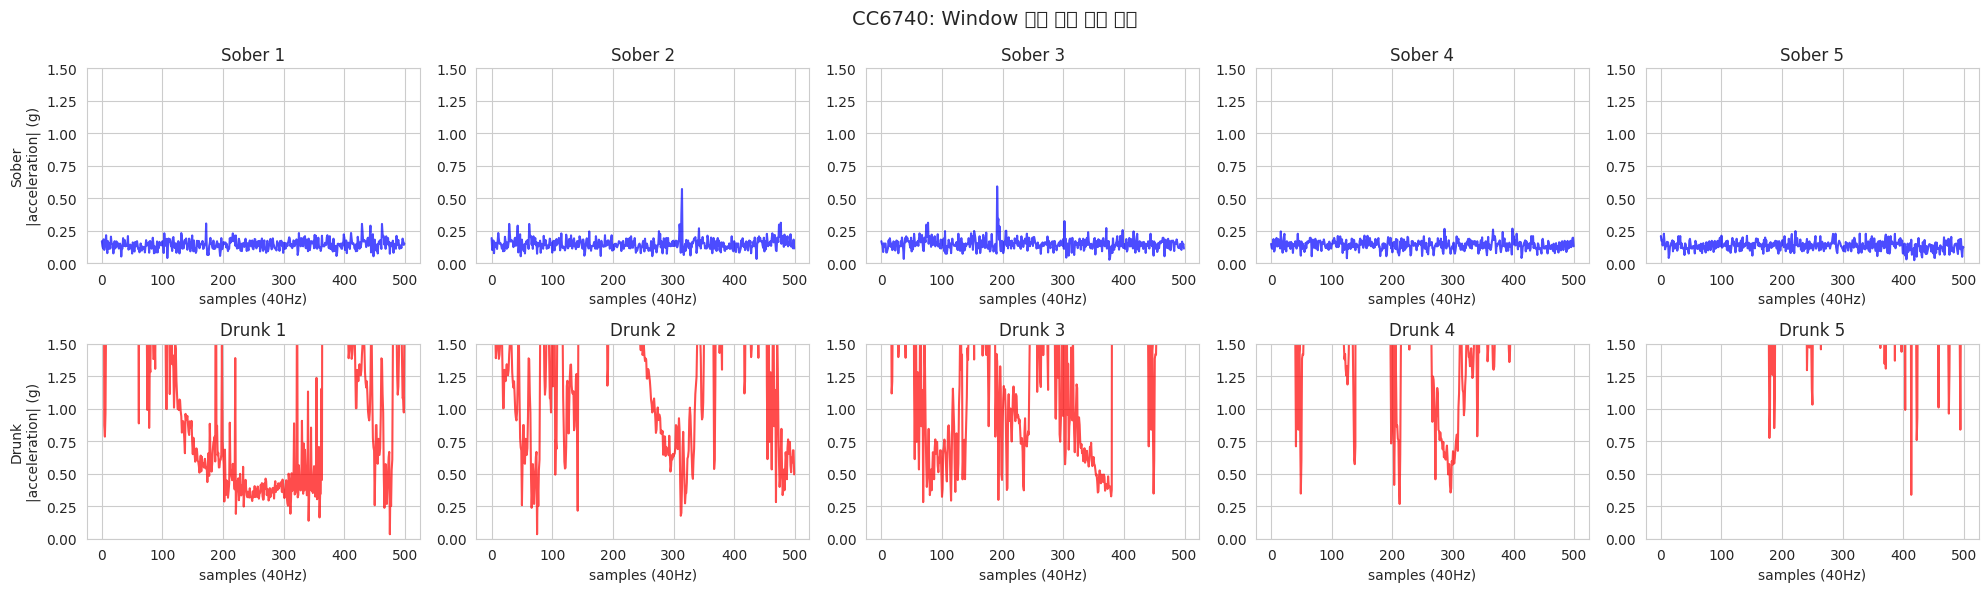

/tmp/ipykernel_6266/1715301703.py:117: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:117: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:117: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:117: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:117: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:117: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:117: UserWarning: Glyph 52825 (\N{HANGUL SYLLABLE CIG}) missing from font(s) DejaVu Sans.
  plt.t


=== 주파수 분석 (FFT) ===
정상 보행: 걸음 주기 약 1~2Hz → FFT에서 peak
음주 보행: 주파수 성분이 불규칙해짐


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

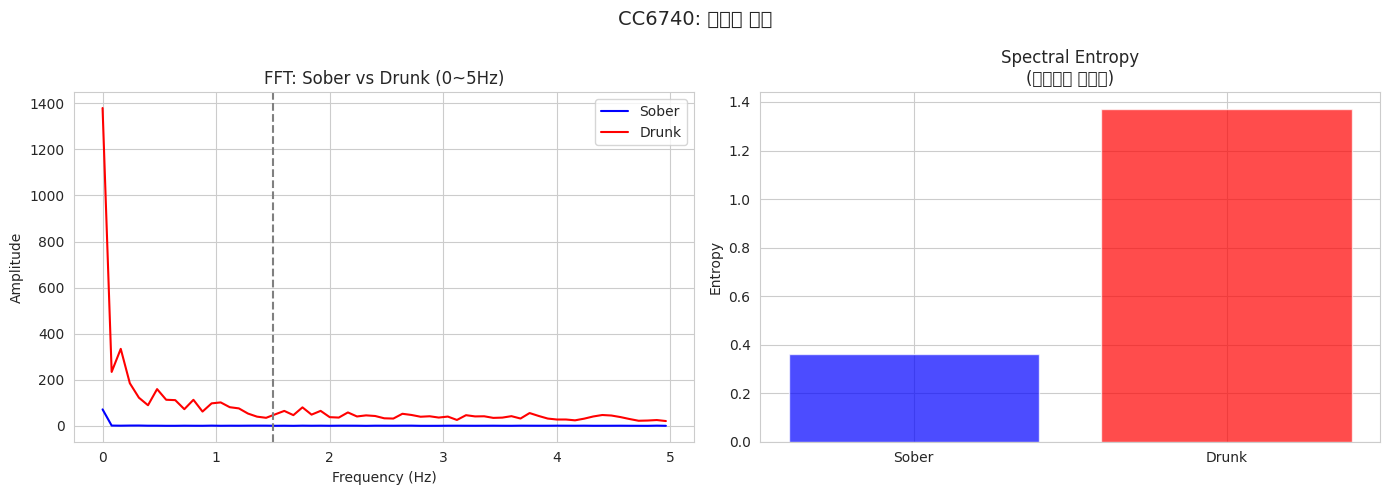


분석 3: 윈도우 간 변화 (시간에 따른 특징 변화)


/tmp/ipykernel_6266/1715301703.py:205: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:205: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:205: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:205: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:205: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:205: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6266/1715301703.py:205: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.

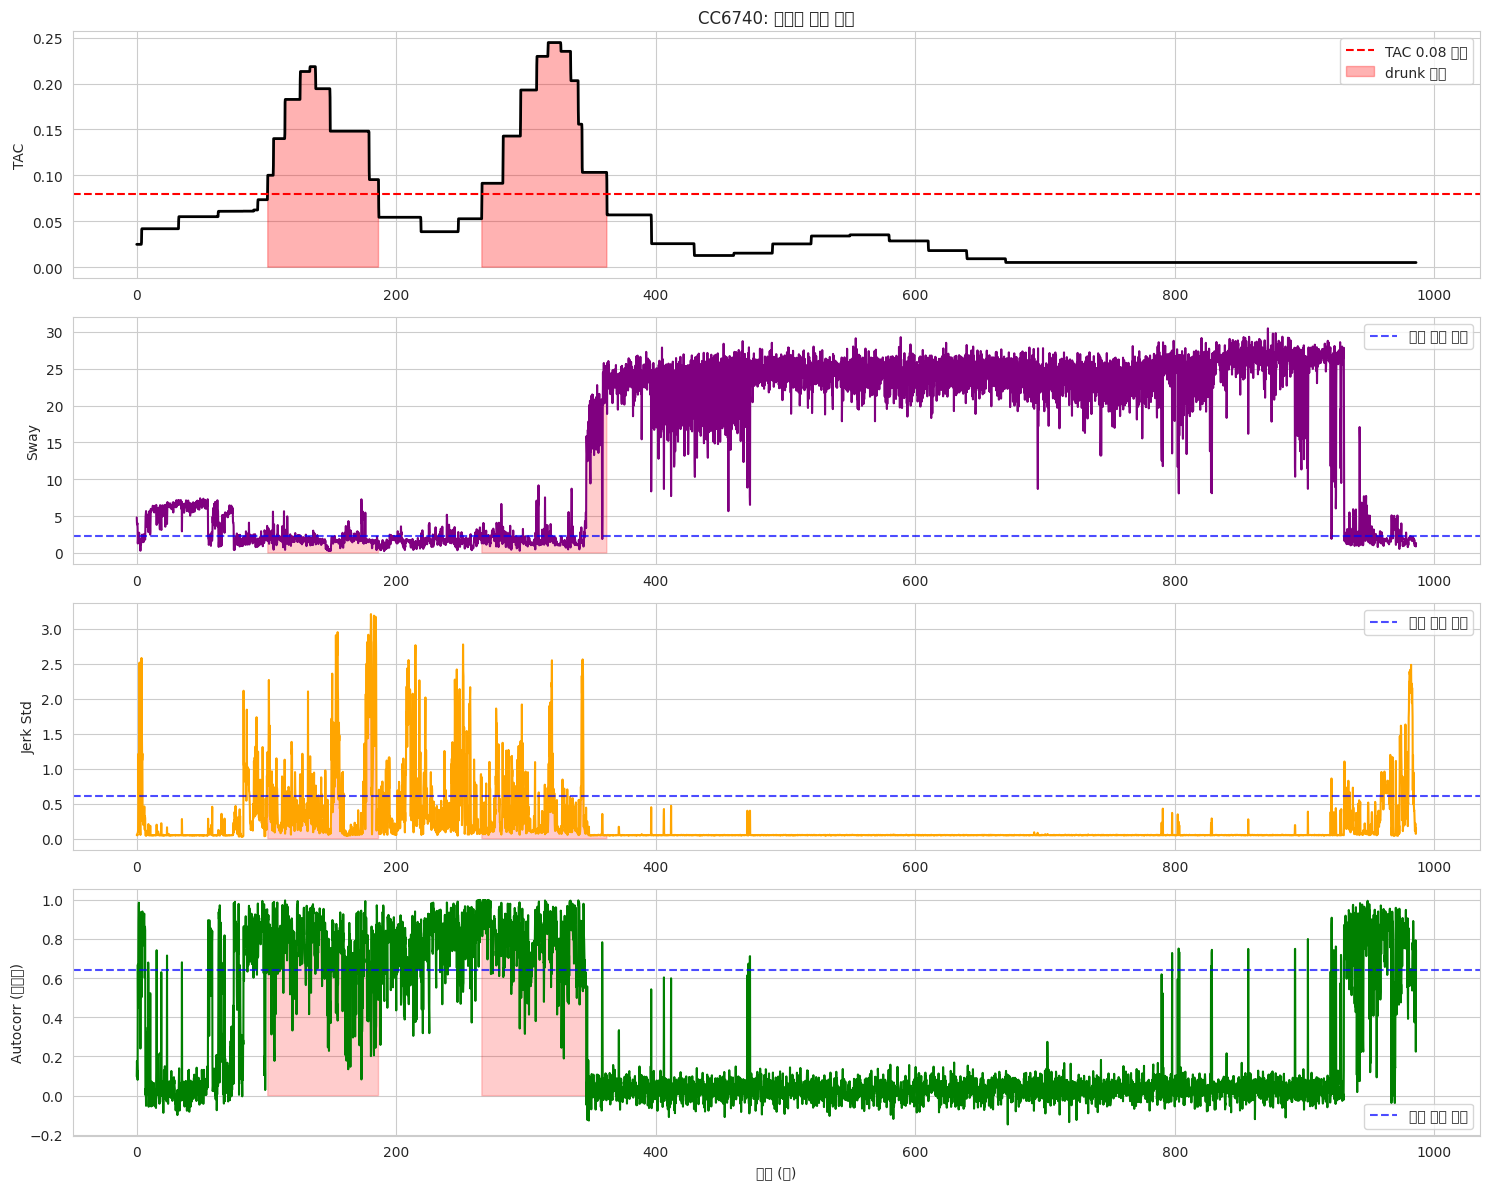


=== 윈도우 간 변화량 분석 ===
연속된 윈도우 사이의 특징값 변화가
sober→drunk 전환 시 어떻게 달라지는가

특징              |  sober delta |  drunk delta |    p-value
-------------------------------------------------------
sway            |       2.4325 |       0.8469 |   0.000000 ✅
jerk_std        |       0.0531 |       0.2141 |   0.000000 ✅
autocorr        |       0.0747 |       0.1112 |   0.000000 ✅
mag_std         |       0.0942 |       0.4122 |   0.000000 ✅

분석 5: 지표별 sober vs drunk 분리 능력

특징              | sober mean | drunk mean |    AUC |    유의미
-------------------------------------------------------
sway            |    17.6660 |     3.2755 |  0.866 | ✅
jerk_std        |     0.1510 |     0.4694 |  0.835 | ✅
mag_mean        |     0.6759 |     1.1857 |  0.555 | ✅
mag_std         |     0.2153 |     0.8026 |  0.847 | ✅
x_std           |     0.2052 |     0.7643 |  0.850 | ✅
y_std           |     0.1911 |     0.7156 |  0.870 | ✅
z_std           |     0.2044 |     0.7445 |  0.851 | ✅
autocorr        |     0.1925 |     0.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from scipy.stats import ttest_ind

feat_cols = ['sway', 'jerk_std', 'mag_mean', 'mag_std',
             'x_std', 'y_std', 'z_std', 'autocorr', 'p2p']

# ─── 분석 1: 윈도우 내부 패턴 ────────────────────────────────
print("=" * 60)
print("분석 1: 윈도우 내부 패턴 (sober vs drunk)")
print("=" * 60)

# pid별로 sober/drunk 윈도우 내부 신호 비교
pid_check = 'CC6740'  # sober/drunk 둘 다 있는 사람

group = combined_df_clean[
    combined_df_clean['pid'] == pid_check
].sort_values('time').reset_index(drop=True)

x   = group['x'].values.astype(np.float32)
y   = group['y'].values.astype(np.float32)
z   = group['z'].values.astype(np.float32)
mag = group['mag'].values.astype(np.float32)
lbl = group['label'].values
tac = group['TAC_Reading'].values

# sober/drunk 윈도우 각각 5개씩 수집
sober_windows = []
drunk_windows = []

for s in range(0, len(mag) - WINDOW_SIZE, STEP):
    e     = s + WINDOW_SIZE
    label = int(lbl[s:e].mean() >= 0.5)
    if label == 0 and len(sober_windows) < 5:
        sober_windows.append(mag[s:e])
    if label == 1 and len(drunk_windows) < 5:
        drunk_windows.append(mag[s:e])
    if len(sober_windows) >= 5 and len(drunk_windows) >= 5:
        break

fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i in range(5):
    # sober
    axes[0, i].plot(sober_windows[i], color='blue', alpha=0.7)
    axes[0, i].set_title(f'Sober {i+1}')
    axes[0, i].set_ylim(0, 1.5)
    axes[0, i].set_xlabel('samples (40Hz)')

    # drunk
    axes[1, i].plot(drunk_windows[i], color='red', alpha=0.7)
    axes[1, i].set_title(f'Drunk {i+1}')
    axes[1, i].set_ylim(0, 1.5)
    axes[1, i].set_xlabel('samples (40Hz)')

axes[0, 0].set_ylabel('Sober\n|acceleration| (g)')
axes[1, 0].set_ylabel('Drunk\n|acceleration| (g)')
plt.suptitle(f'{pid_check}: Window 내부 신호 패턴 비교',
             fontsize=14)
plt.tight_layout()
plt.savefig('window_internal_pattern.png', dpi=150)
plt.show()


# ─── 분석 2: 주파수 분석 (FFT) ───────────────────────────────
print("\n=== 주파수 분석 (FFT) ===")
print("정상 보행: 걸음 주기 약 1~2Hz → FFT에서 peak")
print("음주 보행: 주파수 성분이 불규칙해짐")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sober_ffts = []
drunk_ffts = []

for i in range(min(5, len(sober_windows))):
    freqs = np.fft.rfftfreq(WINDOW_SIZE, d=1/40)
    fft_s = np.abs(np.fft.rfft(sober_windows[i]))
    fft_d = np.abs(np.fft.rfft(drunk_windows[i]))
    sober_ffts.append(fft_s)
    drunk_ffts.append(fft_d)

sober_fft_mean = np.mean(sober_ffts, axis=0)
drunk_fft_mean = np.mean(drunk_ffts, axis=0)

# 0~5Hz만 표시 (걸음 관련 주파수)
mask = freqs <= 5
axes[0].plot(freqs[mask], sober_fft_mean[mask],
             color='blue', label='Sober')
axes[0].plot(freqs[mask], drunk_fft_mean[mask],
             color='red', label='Drunk')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('FFT: Sober vs Drunk (0~5Hz)')
axes[0].legend()
axes[0].axvline(x=1.5, color='gray',
                linestyle='--', label='보행주기 1.5Hz')

# 주파수 엔트로피 (불규칙성 측정)
def spectral_entropy(signal, fs=40):
    freqs_se = np.fft.rfftfreq(len(signal), d=1/fs)
    fft_se   = np.abs(np.fft.rfft(signal))
    psd      = fft_se**2
    psd_norm = psd / (psd.sum() + 1e-10)
    entropy  = -np.sum(psd_norm * np.log(psd_norm + 1e-10))
    return entropy

sober_entropy = [spectral_entropy(w) for w in sober_windows]
drunk_entropy = [spectral_entropy(w) for w in drunk_windows]
axes[1].bar(['Sober', 'Drunk'],
            [np.mean(sober_entropy), np.mean(drunk_entropy)],
            color=['blue', 'red'], alpha=0.7)
axes[1].set_title('Spectral Entropy\n(높을수록 불규칙)')
axes[1].set_ylabel('Entropy')

plt.suptitle(f'{pid_check}: 주파수 분석', fontsize=14)
plt.tight_layout()
plt.savefig('fft_analysis.png', dpi=150)
plt.show()


# ─── 분석 3: 윈도우 간 변화 ──────────────────────────────────
print("\n" + "=" * 60)
print("분석 3: 윈도우 간 변화 (시간에 따른 특징 변화)")
print("=" * 60)

# 각 윈도우별 특징 추출 + TAC 변화 같이 보기
window_timeline = []

for s in range(0, len(mag) - WINDOW_SIZE, STEP):
    e     = s + WINDOW_SIZE
    m_w   = mag[s:e]
    x_w   = x[s:e]
    y_w   = y[s:e]
    z_w   = z[s:e]

    feat  = extract_features_from_signal(
        x_w, y_w, z_w, m_w)
    feat['window_idx'] = s // STEP
    feat['tac_mean']   = tac[s:e].mean()
    feat['label']      = int(lbl[s:e].mean() >= 0.5)
    feat['time_min']   = s / 40 / 60  # 분 단위
    window_timeline.append(feat)

tl_df = pd.DataFrame(window_timeline)

# 시간에 따른 특징 변화 시각화
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# TAC
axes[0].plot(tl_df['time_min'], tl_df['tac_mean'],
             color='black', linewidth=2)
axes[0].axhline(y=0.08, color='red',
                linestyle='--', label='TAC 0.08 기준')
axes[0].fill_between(tl_df['time_min'],
                     tl_df['tac_mean'],
                     where=tl_df['label']==1,
                     alpha=0.3, color='red',
                     label='drunk 구간')
axes[0].set_ylabel('TAC')
axes[0].legend()
axes[0].set_title(f'{pid_check}: 시간에 따른 변화')

# sway
axes[1].plot(tl_df['time_min'], tl_df['sway'],
             color='purple', linewidth=1.5)
axes[1].fill_between(tl_df['time_min'],
                     tl_df['sway'],
                     where=tl_df['label']==1,
                     alpha=0.2, color='red')
# WISDM 정상 범위 표시
axes[1].axhline(y=normal_stats['sway']['upper'],
                color='blue', linestyle='--',
                alpha=0.7, label='정상 범위 상한')
axes[1].set_ylabel('Sway')
axes[1].legend()

# jerk_std
axes[2].plot(tl_df['time_min'], tl_df['jerk_std'],
             color='orange', linewidth=1.5)
axes[2].fill_between(tl_df['time_min'],
                     tl_df['jerk_std'],
                     where=tl_df['label']==1,
                     alpha=0.2, color='red')
axes[2].axhline(y=normal_stats['jerk_std']['upper'],
                color='blue', linestyle='--',
                alpha=0.7, label='정상 범위 상한')
axes[2].set_ylabel('Jerk Std')
axes[2].legend()

# autocorr (규칙성)
axes[3].plot(tl_df['time_min'], tl_df['autocorr'],
             color='green', linewidth=1.5)
axes[3].fill_between(tl_df['time_min'],
                     tl_df['autocorr'],
                     where=tl_df['label']==1,
                     alpha=0.2, color='red')
axes[3].axhline(y=normal_stats['autocorr']['lower'],
                color='blue', linestyle='--',
                alpha=0.7, label='정상 범위 하한')
axes[3].set_xlabel('시간 (분)')
axes[3].set_ylabel('Autocorr (규칙성)')
axes[3].legend()

plt.tight_layout()
plt.savefig('window_timeline.png', dpi=150)
plt.show()


# ─── 분석 4: 윈도우 간 변화량 (delta) ───────────────────────
print("\n=== 윈도우 간 변화량 분석 ===")
print("연속된 윈도우 사이의 특징값 변화가")
print("sober→drunk 전환 시 어떻게 달라지는가")

delta_cols = ['sway', 'jerk_std', 'autocorr', 'mag_std']
tl_df_delta = tl_df.copy()

for col in delta_cols:
    tl_df_delta[f'd_{col}'] = tl_df[col].diff().abs()

# sober 구간 vs drunk 구간의 delta 비교
print(f"\n{'특징':15s} | {'sober delta':>12} | {'drunk delta':>12} | {'p-value':>10}")
print("-" * 55)

for col in delta_cols:
    dcol   = f'd_{col}'
    sober_ = tl_df_delta[tl_df_delta['label']==0][dcol].dropna()
    drunk_ = tl_df_delta[tl_df_delta['label']==1][dcol].dropna()

    if len(sober_) > 1 and len(drunk_) > 1:
        t, p = ttest_ind(sober_, drunk_)
        print(f"{col:15s} | "
              f"{sober_.mean():>12.4f} | "
              f"{drunk_.mean():>12.4f} | "
              f"{p:>10.6f} "
              f"{'✅' if p < 0.05 else '❌'}")


# ─── 분석 5: 중요 지표 확인 ──────────────────────────────────
print("\n" + "=" * 60)
print("분석 5: 지표별 sober vs drunk 분리 능력")
print("=" * 60)

from sklearn.metrics import roc_auc_score

print(f"\n{'특징':15s} | {'sober mean':>10} | "
      f"{'drunk mean':>10} | {'AUC':>6} | {'유의미':>6}")
print("-" * 55)

for col in feat_cols + [f'd_{col}' for col in delta_cols]:
    if col not in tl_df_delta.columns:
        continue
    sober_ = tl_df_delta[tl_df_delta['label']==0][col].dropna()
    drunk_ = tl_df_delta[tl_df_delta['label']==1][col].dropna()

    if len(sober_) < 2 or len(drunk_) < 2:
        continue

    all_vals  = pd.concat([sober_, drunk_])
    all_label = ([0]*len(sober_) + [1]*len(drunk_))

    try:
        auc = roc_auc_score(all_label, all_vals)
        auc = max(auc, 1-auc)  # 방향 무관
        _, p = ttest_ind(sober_, drunk_)
        print(f"{col:15s} | "
              f"{sober_.mean():>10.4f} | "
              f"{drunk_.mean():>10.4f} | "
              f"{auc:>6.3f} | "
              f"{'✅' if p<0.05 else '❌'}")
    except:
        pass

In [53]:
# sway 이상값 확인
print("Bar Crawl sway 분포:")
print(barcrawl_df['sway'].describe())
print(f"\nsway > 100인 윈도우: {(barcrawl_df['sway'] > 100).sum()}")
print(f"sway > 10인 윈도우:  {(barcrawl_df['sway'] > 10).sum()}")

# pid별로 확인
print("\npid별 sway 평균:")
print(barcrawl_df.groupby('pid')['sway'].mean().round(2))

Bar Crawl sway 분포:
count    33669.000000
mean         7.755486
std          7.887281
min          0.122388
25%          1.777163
50%          3.206012
75%         13.531202
max         36.860607
Name: sway, dtype: float64

sway > 100인 윈도우: 0
sway > 10인 윈도우:  10783

pid별 sway 평균:
pid
BK7610     5.07
BU4707     2.14
CC6740    15.01
DC6359     1.98
DK3500    14.85
HV0618     6.88
JB3156     2.95
JR8022     2.72
MC7070     4.14
MJ8002     2.09
PC6771     8.29
SA0297     3.80
SF3079     1.70
Name: sway, dtype: float32


In [54]:
# ─── sway 재정의 ──────────────────────────────────────────────
# 기존: sqrt(x²+z²) / |y|  ← 폰 방향에 의존
# 수정: 가속도 방향 변화량으로 측정

def compute_sway_v2(x, y, z):
    """
    방향 변화 기반 sway
    → 폰 방향과 무관하게 움직임 불안정성 측정
    """
    # 방법 1: 가속도 벡터 방향 변화량
    # 연속된 샘플 간 각도 변화
    vec = np.stack([x, y, z], axis=1)  # (T, 3)
    norms = np.linalg.norm(vec, axis=1, keepdims=True) + 1e-8
    vec_norm = vec / norms  # 단위벡터

    # 연속된 단위벡터 간 내적 → 각도 변화
    cos_sim = np.sum(vec_norm[:-1] * vec_norm[1:], axis=1)
    cos_sim = np.clip(cos_sim, -1, 1)
    angle_change = np.arccos(cos_sim)  # 라디안

    return angle_change.std()  # 방향 변화의 불규칙성

def compute_lateral_instability(x, y, z, mag):
    """
    방법 2: 전체 크기 대비 수평 성분 비율의 변동성
    → 수직(중력) 방향이 어디든 상관없이
      움직임이 얼마나 불안정한가
    """
    # 각 축의 변동계수 (CV = std/mean)
    cv_x = x.std() / (np.abs(x).mean() + 1e-8)
    cv_y = y.std() / (np.abs(y).mean() + 1e-8)
    cv_z = z.std() / (np.abs(z).mean() + 1e-8)
    return (cv_x + cv_y + cv_z) / 3  # 평균 변동계수

# ─── 특징 재추출 ──────────────────────────────────────────────
def extract_features_v2(x, y, z, mag):
    return {
        'jerk_std'    : float(np.std(np.diff(mag))),
        'mag_mean'    : float(mag.mean()),
        'mag_std'     : float(mag.std()),
        'x_std'       : float(x.std()),
        'y_std'       : float(y.std()),
        'z_std'       : float(z.std()),
        'autocorr'    : float(np.corrcoef(mag[:-1], mag[1:])[0,1])
                        if mag.std() > 1e-8 else 0.0,
        'p2p'         : float(mag.max() - mag.min()),
        # 수정된 sway
        'sway_v2'     : float(compute_sway_v2(x, y, z)),
        # 추가 특징
        'lateral_inst': float(compute_lateral_instability(
                            x, y, z, mag)),
        # 주파수 엔트로피
        'spec_entropy': float(
            -np.sum(
                (lambda p: p)(
                    np.abs(np.fft.rfft(mag))**2 /
                    (np.abs(np.fft.rfft(mag))**2).sum() + 1e-10
                ) *
                np.log(
                    np.abs(np.fft.rfft(mag))**2 /
                    (np.abs(np.fft.rfft(mag))**2).sum() + 1e-10
                )
            )
        ),
    }

# ─── Bar Crawl 재추출 ─────────────────────────────────────────
print("Bar Crawl 특징 재추출 중...")
barcrawl_feats_v2 = []

for pid, group in combined_df_clean.groupby('pid'):
    group = group[group['time'] > 0].sort_values('time')
    x   = group['x'].values.astype(np.float32)
    y   = group['y'].values.astype(np.float32)
    z   = group['z'].values.astype(np.float32)
    mag = group['mag'].values.astype(np.float32)
    tac = group['TAC_Reading'].values.astype(np.float32)
    lbl = group['label'].values

    n = len(x)
    for s in range(0, n - WINDOW_SIZE, STEP):
        e    = s + WINDOW_SIZE
        feat = extract_features_v2(
            x[s:e], y[s:e], z[s:e], mag[s:e]
        )
        feat['pid']   = pid
        feat['tac']   = float(tac[s:e].mean())
        feat['label'] = int(lbl[s:e].mean() >= 0.5)
        barcrawl_feats_v2.append(feat)

bc_v2 = pd.DataFrame(barcrawl_feats_v2)
print(f"윈도우 수: {len(bc_v2):,}개")

# ─── 분리 능력 재확인 ─────────────────────────────────────────
feat_cols_v2 = ['jerk_std', 'mag_mean', 'mag_std',
                'x_std', 'y_std', 'z_std',
                'autocorr', 'p2p', 'sway_v2',
                'lateral_inst', 'spec_entropy']

print(f"\n{'특징':15s} | {'sober mean':>10} | "
      f"{'drunk mean':>10} | {'AUC':>6} | {'유의미':>4}")
print("-" * 55)

from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_ind

auc_scores = {}
for col in feat_cols_v2:
    sober_ = bc_v2[bc_v2['label']==0][col].dropna()
    drunk_ = bc_v2[bc_v2['label']==1][col].dropna()

    if len(sober_) < 2 or len(drunk_) < 2:
        continue

    all_vals  = np.concatenate([sober_, drunk_])
    all_label = np.array([0]*len(sober_) + [1]*len(drunk_))

    try:
        auc = roc_auc_score(all_label, all_vals)
        auc = max(auc, 1-auc)
        _, p = ttest_ind(sober_, drunk_)
        auc_scores[col] = auc
        print(f"{col:15s} | "
              f"{sober_.mean():>10.4f} | "
              f"{drunk_.mean():>10.4f} | "
              f"{auc:>6.3f} | "
              f"{'✅' if p<0.05 else '❌'}")
    except:
        pass

Bar Crawl 특징 재추출 중...
윈도우 수: 33,669개

특징              | sober mean | drunk mean |    AUC |  유의미
-------------------------------------------------------
jerk_std        |     0.0908 |     0.1588 |  0.707 | ✅
mag_mean        |     0.2431 |     0.3294 |  0.643 | ✅
mag_std         |     0.1229 |     0.2418 |  0.739 | ✅
x_std           |     0.1113 |     0.2233 |  0.744 | ✅
y_std           |     0.1063 |     0.2113 |  0.754 | ✅
z_std           |     0.1294 |     0.2302 |  0.725 | ✅
autocorr        |     0.3172 |     0.6876 |  0.748 | ✅
p2p             |     0.8201 |     1.6747 |  0.750 | ✅
sway_v2         |     0.3960 |     0.5007 |  0.630 | ✅
lateral_inst    |     1.1194 |     1.5488 |  0.771 | ✅
spec_entropy    |     0.8046 |     1.6291 |  0.766 | ✅


In [49]:
# ─── 4. 이상 점수 계산 ───────────────────────────────────────
# 각 특징이 정상 범위를 얼마나 벗어났는가
# z-score 기반 이상 점수

def compute_anomaly_score(row, normal_stats, feat_cols):
    """
    정상 분포 대비 z-score 합산
    → 얼마나 정상 걸음에서 벗어났는가
    """
    score = 0
    for col in feat_cols:
        z = abs(row[col] - normal_stats[col]['mean']) / \
            (normal_stats[col]['std'] + 1e-8)
        score += z
    return score / len(feat_cols)  # 평균 z-score

print("이상 점수 계산 중...")
barcrawl_df['anomaly_score'] = barcrawl_df[feat_cols].apply(
    lambda row: compute_anomaly_score(row, normal_stats, feat_cols),
    axis=1
)

print("\n=== sober vs drunk 이상 점수 비교 ===")
sober_score = barcrawl_df[barcrawl_df['label']==0]['anomaly_score']
drunk_score = barcrawl_df[barcrawl_df['label']==1]['anomaly_score']

print(f"sober: mean={sober_score.mean():.4f} | "
      f"std={sober_score.std():.4f}")
print(f"drunk: mean={drunk_score.mean():.4f} | "
      f"std={drunk_score.std():.4f}")

# t-test: 두 그룹이 통계적으로 다른가?
t_stat, p_val = stats.ttest_ind(sober_score, drunk_score)
print(f"\nt-test: t={t_stat:.4f} | p={p_val:.6f}")
if p_val < 0.05:
    print("→ 통계적으로 유의미한 차이 있음 ✅")
else:
    print("→ 통계적으로 유의미한 차이 없음 ❌")

# AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(barcrawl_df['label'],
                     barcrawl_df['anomaly_score'])
print(f"\nAUC (이상 점수 기반): {auc:.4f}")

이상 점수 계산 중...

=== sober vs drunk 이상 점수 비교 ===
sober: mean=5.7169 | std=2.7235
drunk: mean=3.2684 | std=2.2407

t-test: t=73.3961 | p=0.000000
→ 통계적으로 유의미한 차이 있음 ✅

AUC (이상 점수 기반): 0.2090


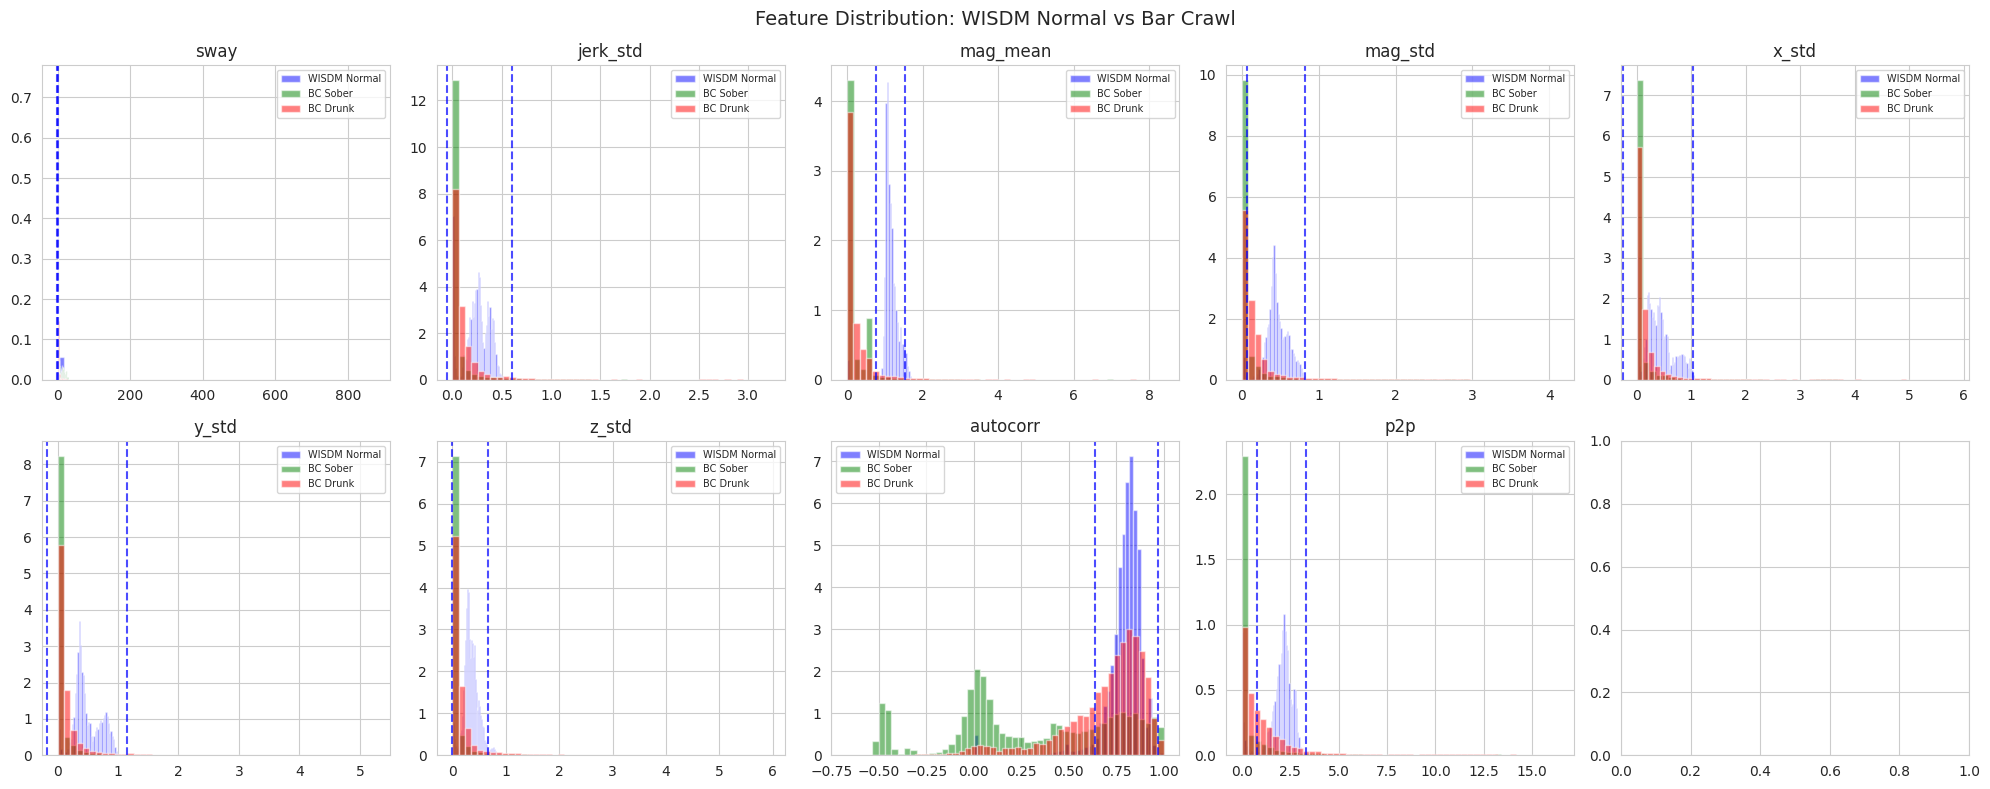

그래프 저장: feature_distribution.png


In [50]:
# ─── 5. 특징별 분포 비교 시각화 ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    ax = axes[i]

    # WISDM 정상 분포
    ax.hist(normal_df[col].values, bins=50,
            alpha=0.5, color='blue',
            label='WISDM Normal', density=True)

    # Bar Crawl sober
    ax.hist(barcrawl_df[barcrawl_df['label']==0][col].values,
            bins=50, alpha=0.5, color='green',
            label='BC Sober', density=True)

    # Bar Crawl drunk
    ax.hist(barcrawl_df[barcrawl_df['label']==1][col].values,
            bins=50, alpha=0.5, color='red',
            label='BC Drunk', density=True)

    # 정상 범위 표시
    ax.axvline(normal_stats[col]['lower'],
               color='blue', linestyle='--', alpha=0.7)
    ax.axvline(normal_stats[col]['upper'],
               color='blue', linestyle='--', alpha=0.7)

    ax.set_title(col)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distribution: WISDM Normal vs Bar Crawl',
             fontsize=14)
plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=150)
plt.show()
print("그래프 저장: feature_distribution.png")

In [51]:
# ─── 6. TAC vs 이상 점수 관계 ────────────────────────────────
print("\n=== TAC 구간별 이상 점수 평균 ===")
barcrawl_df['tac_bin'] = pd.cut(
    barcrawl_df['tac'],
    bins=[0, 0.02, 0.04, 0.08, 0.15, 0.30, 1.0],
    labels=['0~0.02', '0.02~0.04', '0.04~0.08',
            '0.08~0.15', '0.15~0.30', '0.30+']
)
tac_group = barcrawl_df.groupby('tac_bin')['anomaly_score'].agg(
    ['mean', 'std', 'count']
).round(4)
print(tac_group)

print("\n=== pid별 이상 점수 vs drunk 비율 ===")
pid_group = barcrawl_df.groupby('pid').agg(
    n_windows   = ('label', 'count'),
    drunk_pct   = ('label', 'mean'),
    score_sober = ('anomaly_score',
                   lambda x: x[barcrawl_df.loc[x.index,'label']==0].mean()),
    score_drunk = ('anomaly_score',
                   lambda x: x[barcrawl_df.loc[x.index,'label']==1].mean()),
).round(4)
pid_group['drunk_pct'] = (pid_group['drunk_pct'] * 100).round(1)
print(pid_group.to_string())


=== TAC 구간별 이상 점수 평균 ===
             mean     std  count
tac_bin                         
0~0.02     6.8104  2.2707  11857
0.02~0.04  6.2792  2.8824   2485
0.04~0.08  3.9821  2.7060   8076
0.08~0.15  3.4217  2.4749   5458
0.15~0.30  2.9534  1.6094   2637
0.30+         NaN     NaN      0

=== pid별 이상 점수 vs drunk 비율 ===
        n_windows  drunk_pct  score_sober  score_drunk
pid                                                   
BK7610       3064       54.3       4.5994       3.0587
BU4707       1118       36.0       2.6696       2.8464
CC6740       5917       18.5       7.7275       4.5471
DC6359       1478       16.7       3.1082       3.0268
DK3500       3348        0.0       6.6374       2.7939
HV0618       4689        4.9       5.0564       2.4785
JB3156       1495       18.3       5.9003       6.0718
JR8022        768       99.6       2.7036       3.2046
MC7070        796       87.7       4.1488       3.7482
MJ8002       1578       30.5       3.3680       2.5238
PC6771       5354 

/tmp/ipykernel_6266/1784403956.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tac_group = barcrawl_df.groupby('tac_bin')['anomaly_score'].agg(


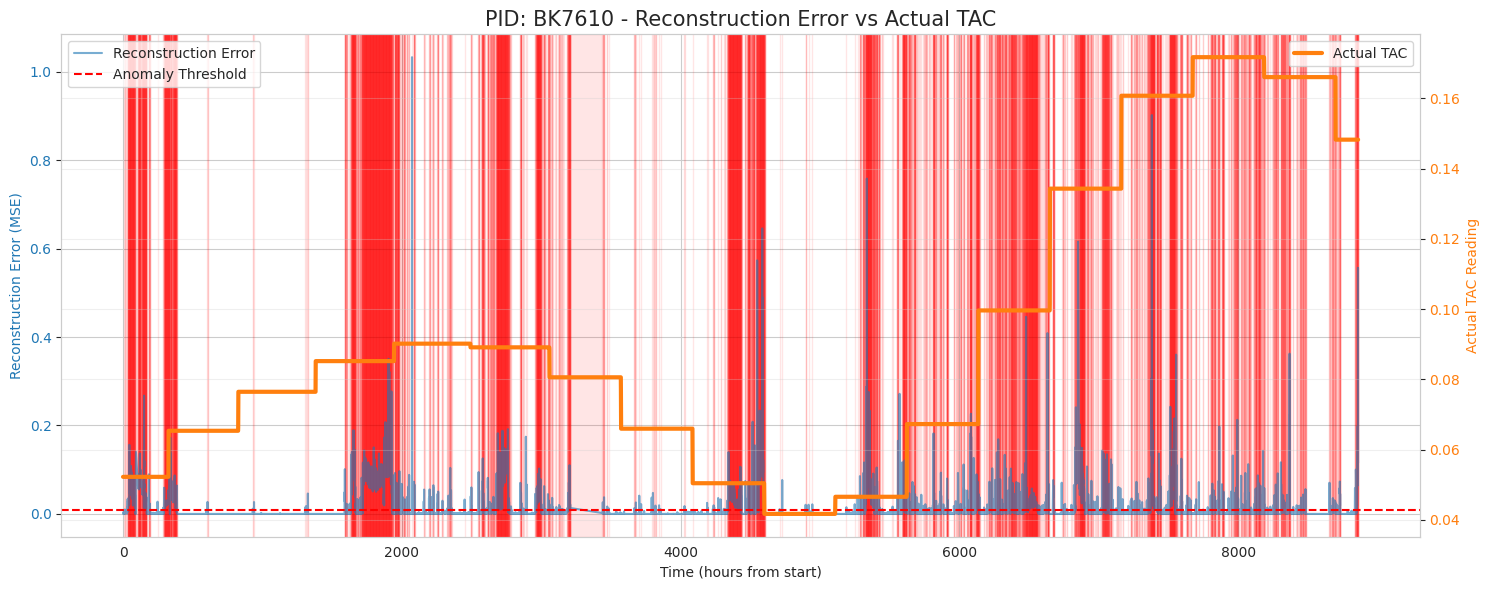

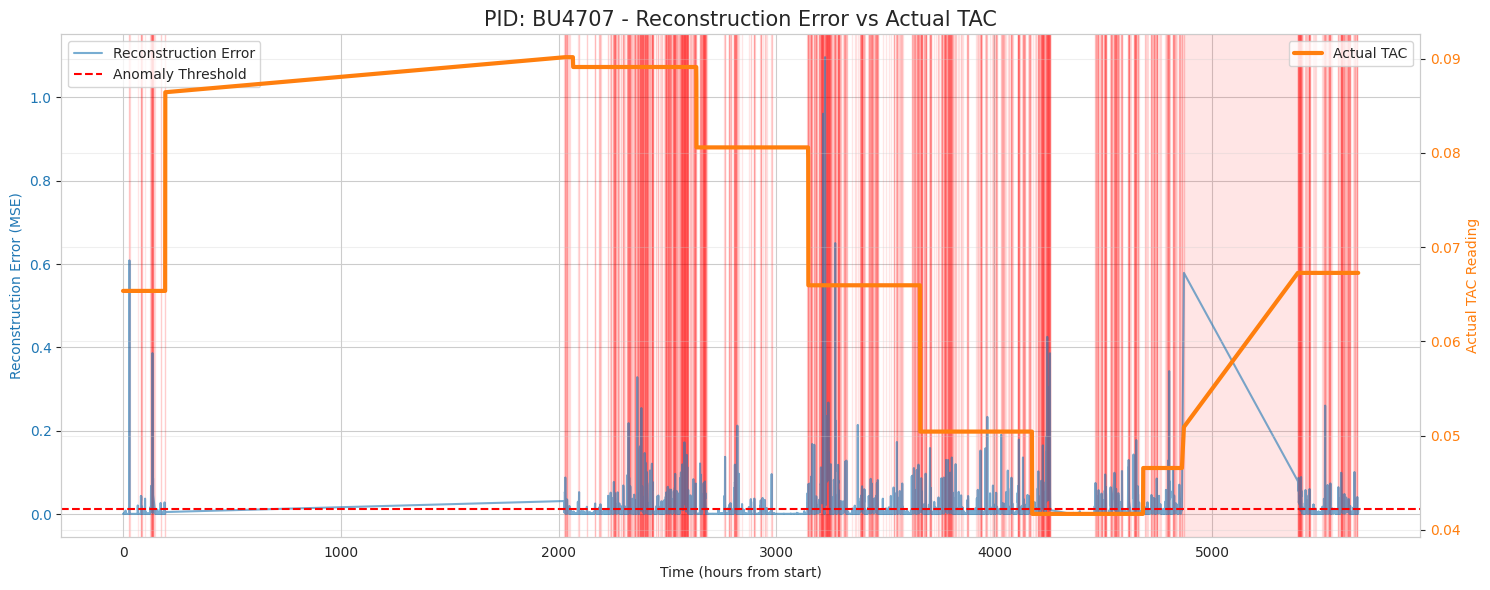

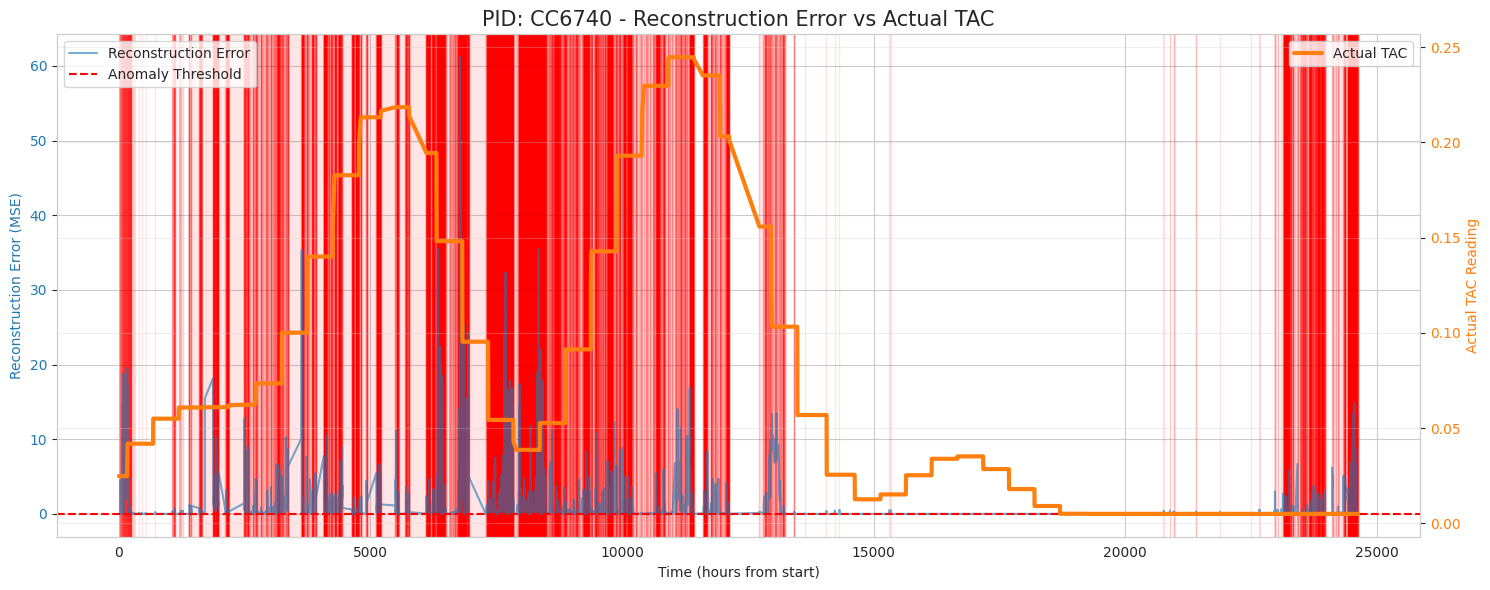

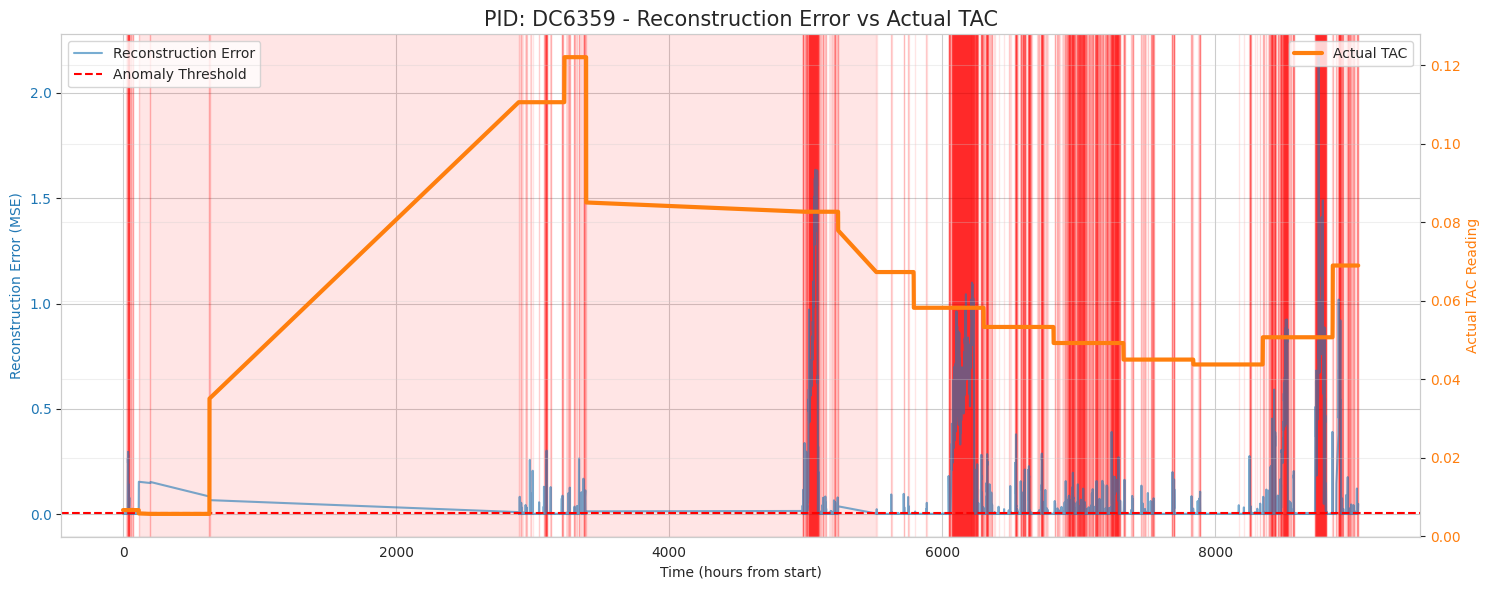

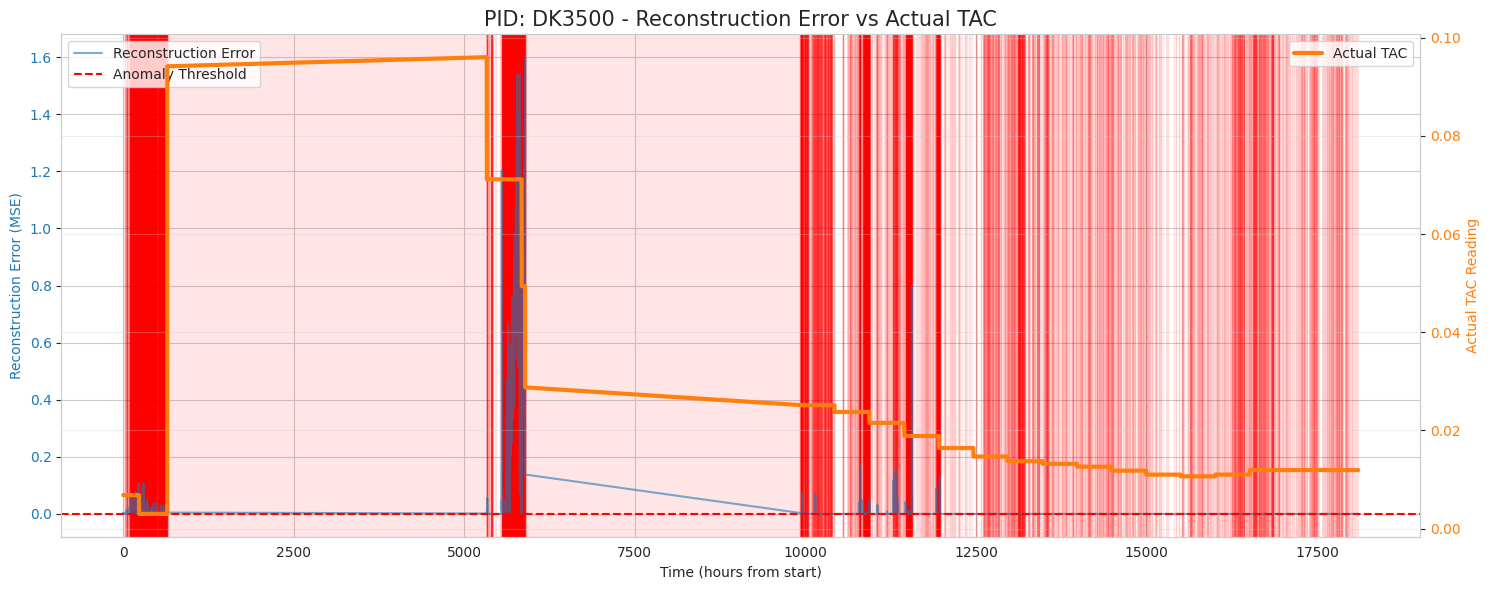

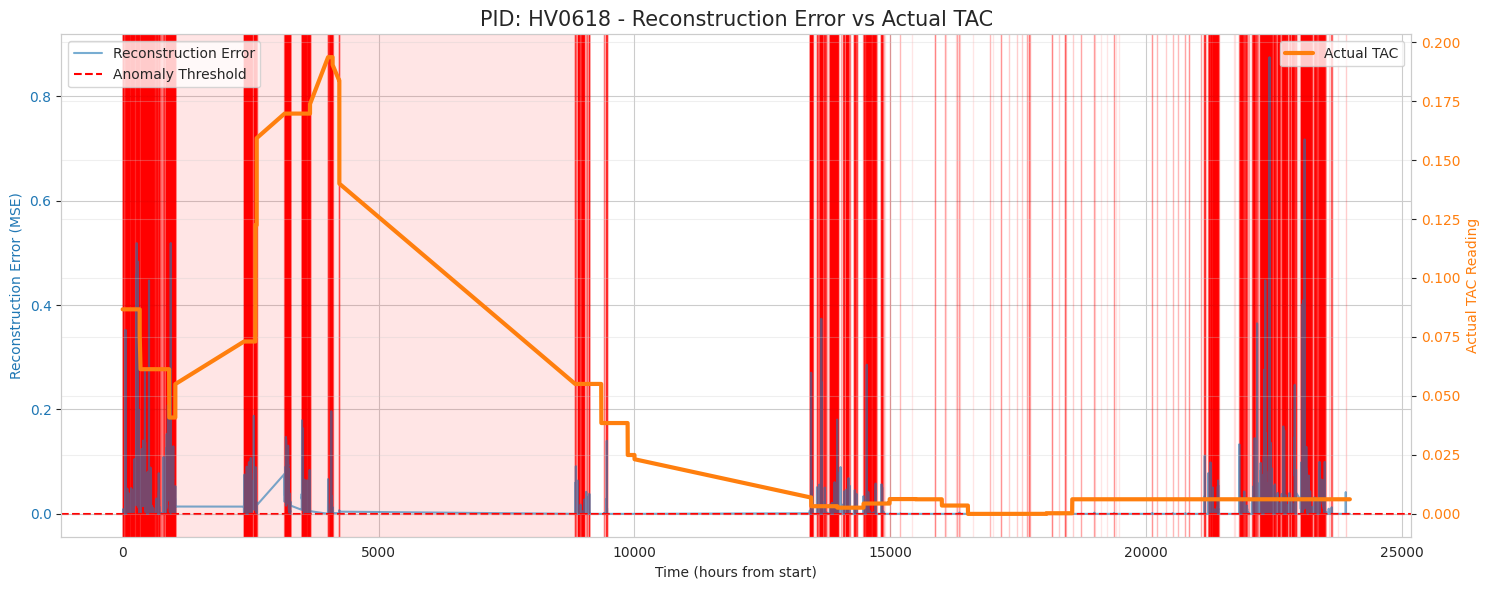

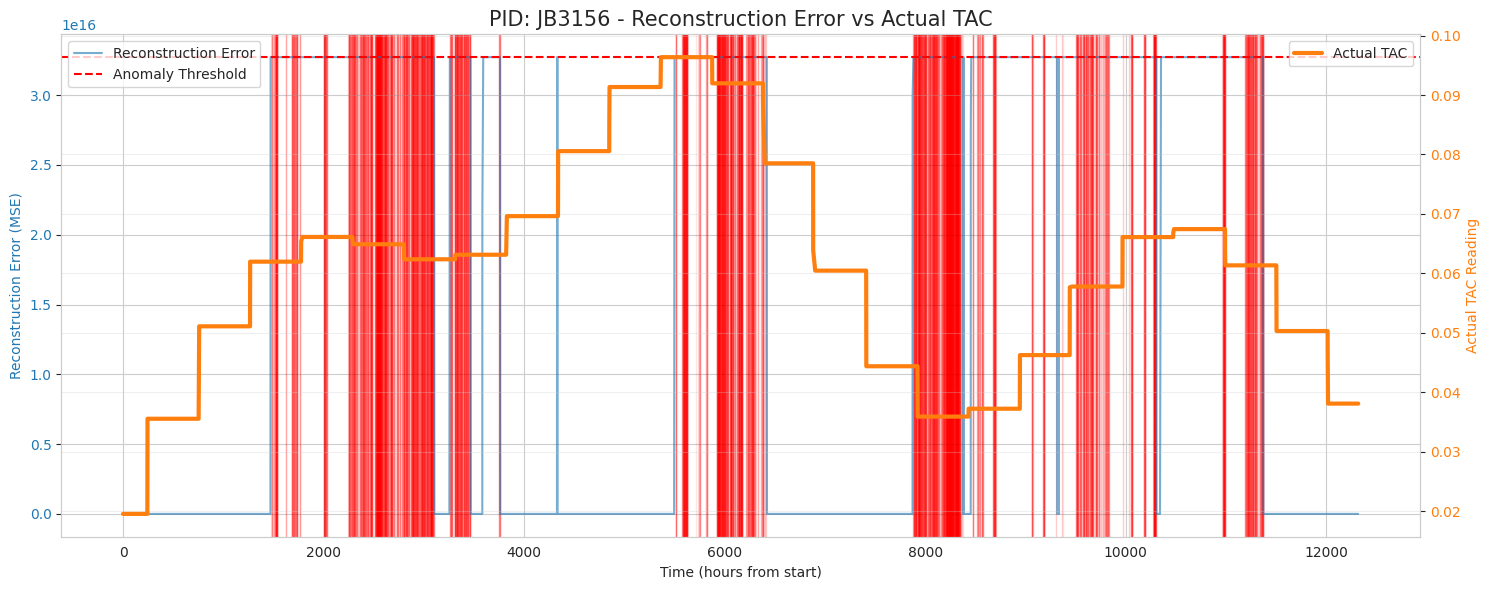

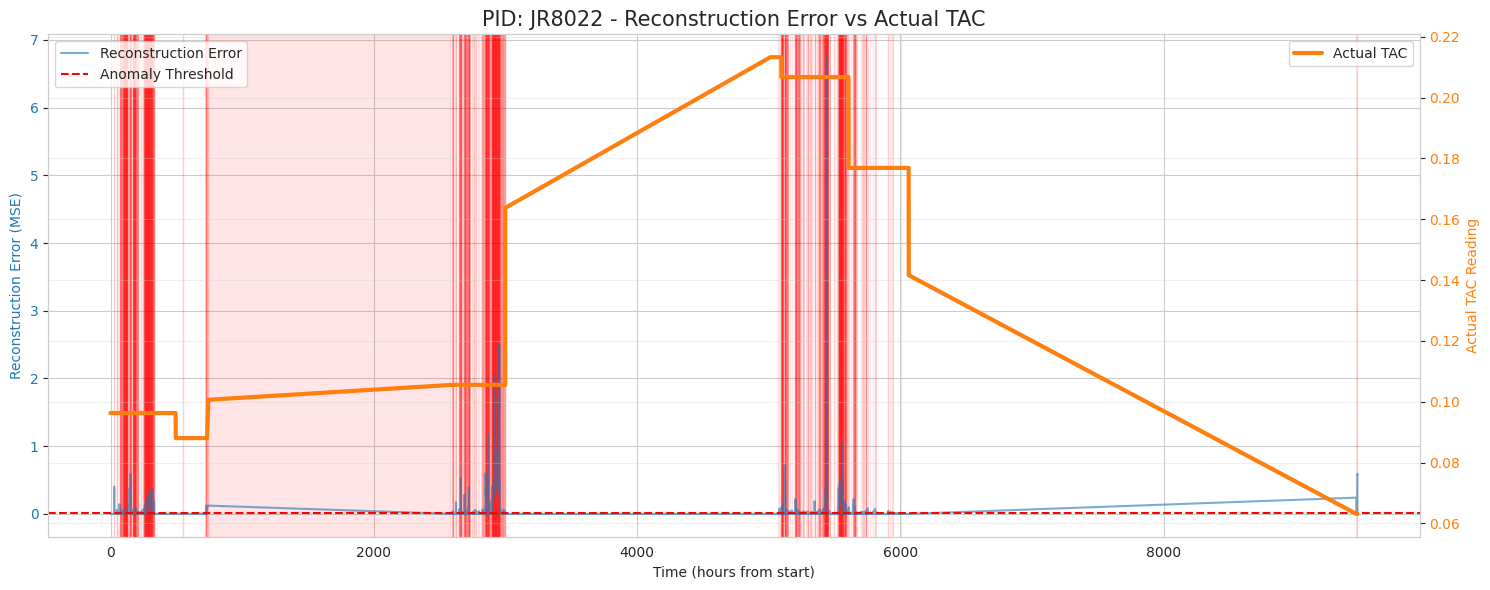

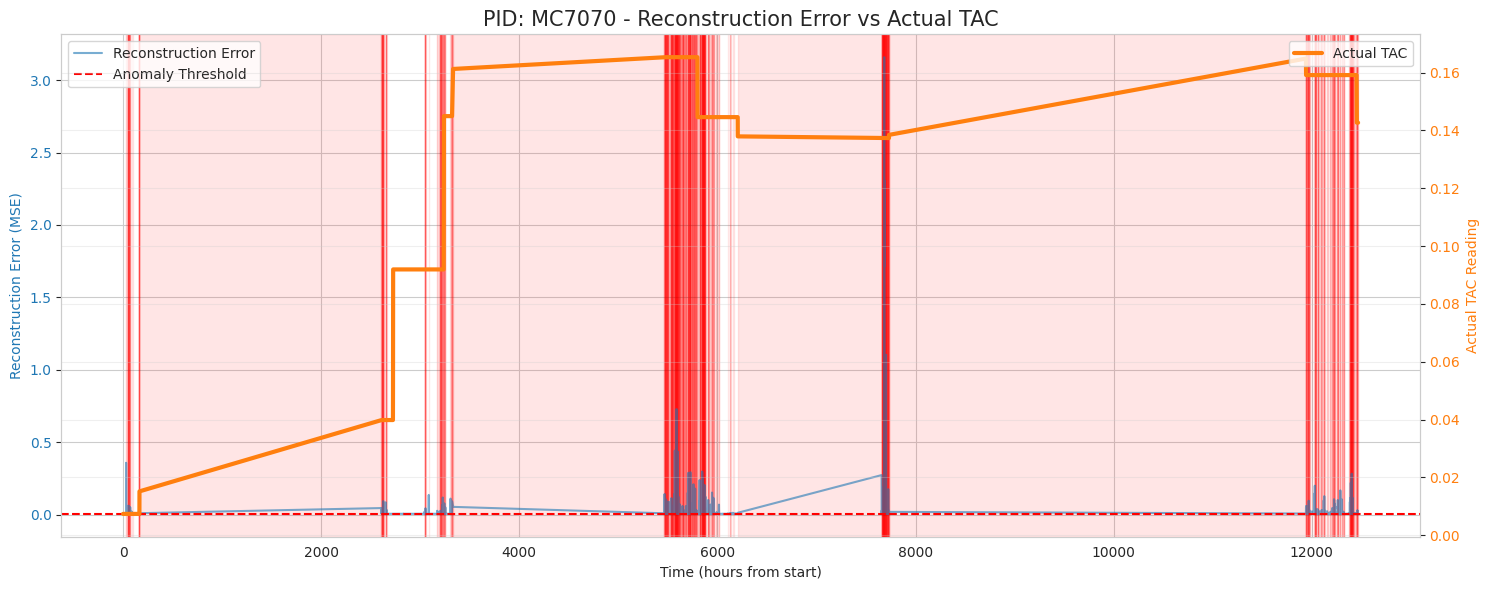

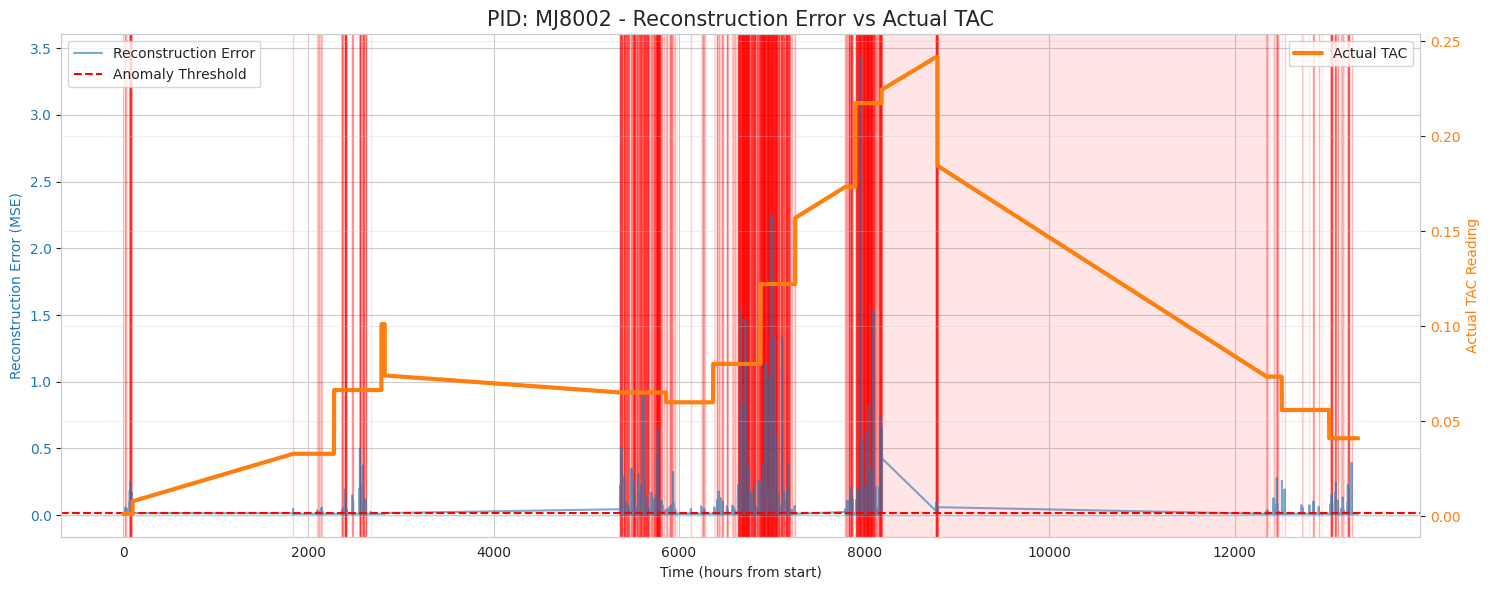

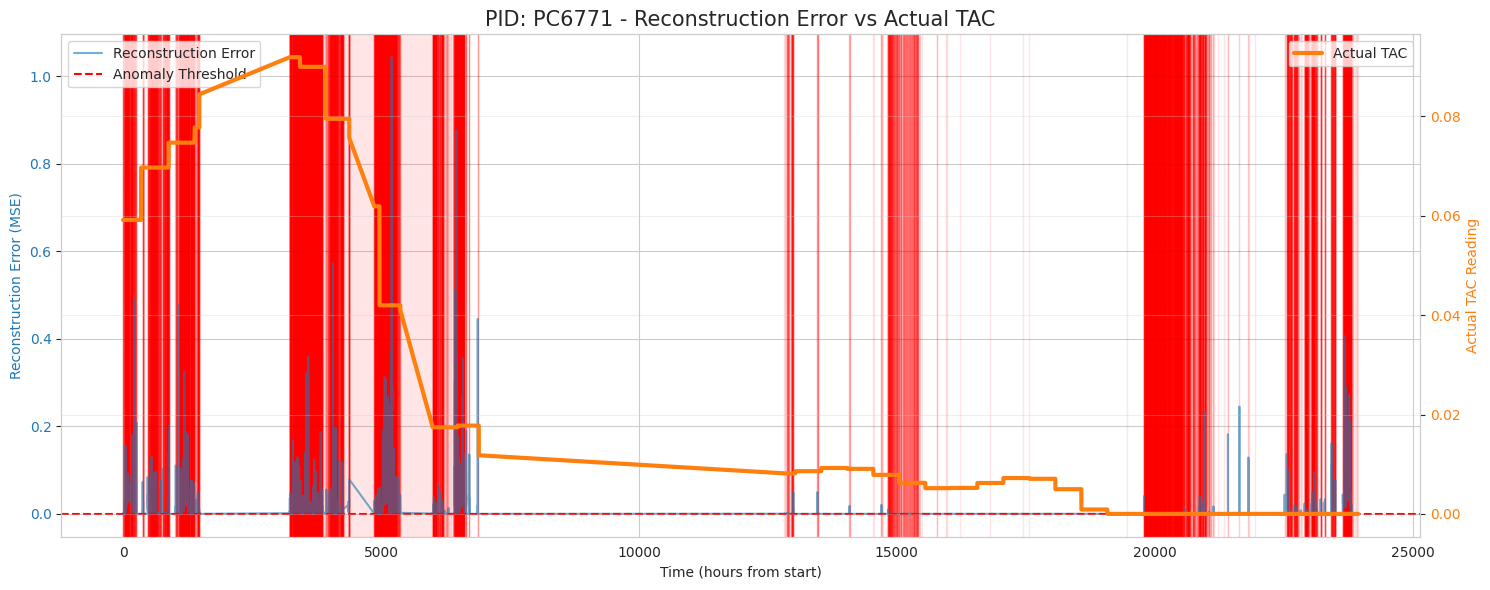

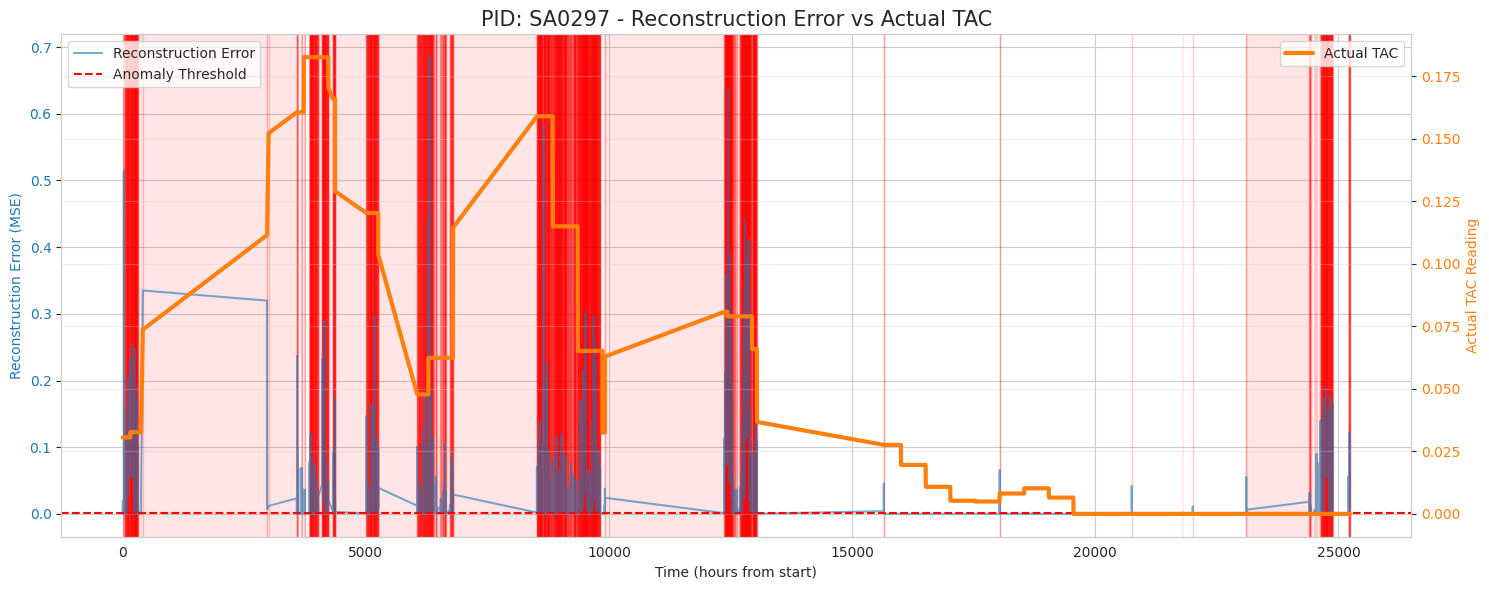

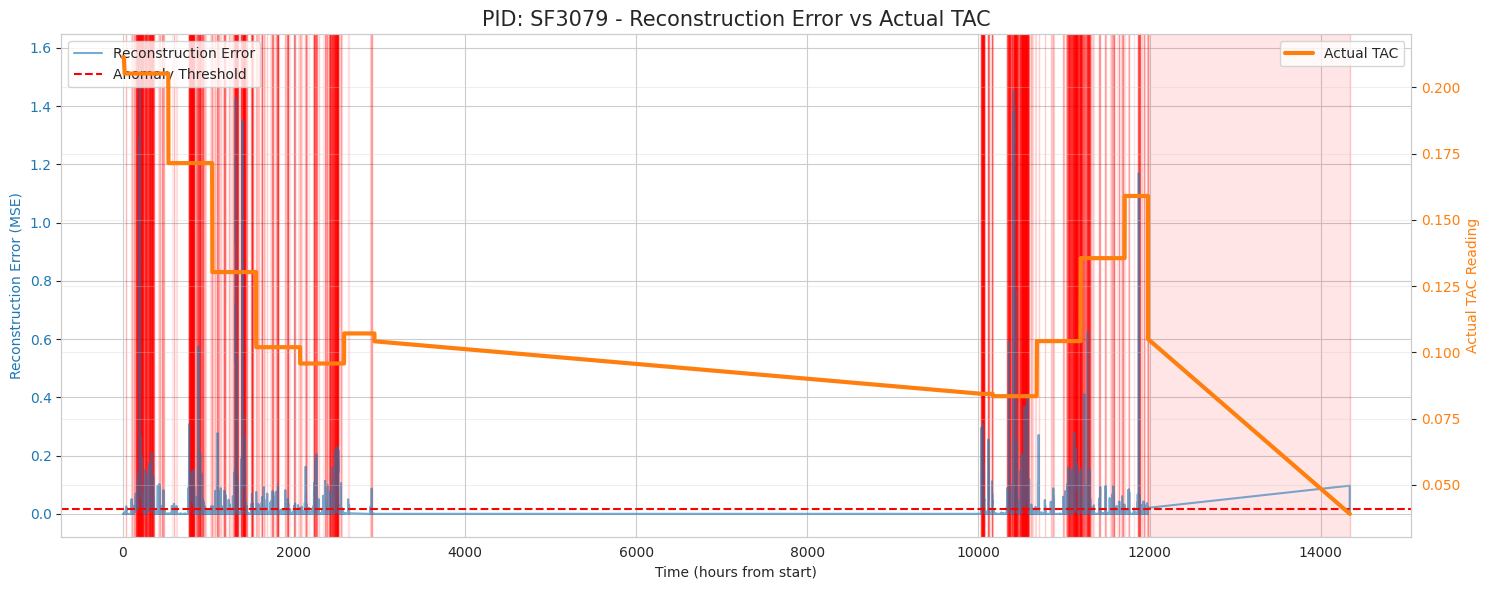

/tmp/ipykernel_6266/317636519.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='TAC_Mean', data=melt_df, palette='Set2')


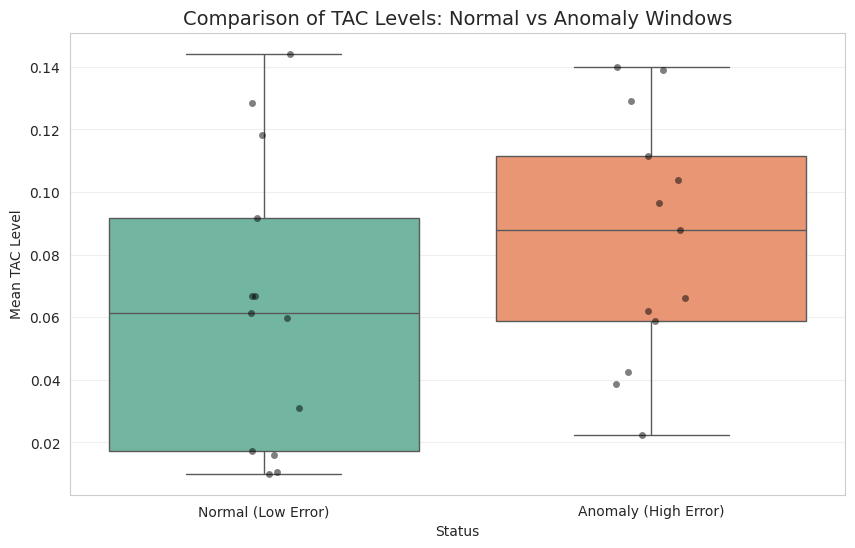

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pid_analysis(pid, result):
    """
    특정 PID에 대한 재구성 오차와 TAC 상관관계 시각화
    """
    errors = result['errors']
    tac_vals = result['tac_vals']
    threshold = result['threshold']
    anomaly = result['anomaly']
    times = result['times']

    # 시간 단위를 보기 편하게 변환 (예: 시작점을 0으로)
    relative_times = (times - times[0]) / 3600 # 시간 단위(hours)

    fig, ax1 = plt.subplots(figsize=(15, 6))
    plt.title(f"PID: {pid} - Reconstruction Error vs Actual TAC", fontsize=15)

    # 1. 재구성 오차 (Reconstruction Error) 그래프 - 왼쪽 축
    color1 = 'tab:blue'
    ax1.set_xlabel('Time (hours from start)')
    ax1.set_ylabel('Reconstruction Error (MSE)', color=color1)
    ax1.plot(relative_times, errors, color=color1, alpha=0.6, label='Reconstruction Error')
    ax1.axhline(y=threshold, color='red', linestyle='--', label='Anomaly Threshold')
    ax1.tick_params(axis='y', labelcolor=color1)

    # 이상치 구간 강조 (배경색 칠하기)
    for i in range(len(anomaly)):
        if anomaly[i] == 1:
            ax1.axvspan(relative_times[i], relative_times[min(i+1, len(relative_times)-1)],
                        color='red', alpha=0.1)

    # 2. 실제 TAC 농도 그래프 - 오른쪽 축
    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.set_ylabel('Actual TAC Reading', color=color2)
    ax2.plot(relative_times, tac_vals, color=color2, linewidth=3, label='Actual TAC')
    ax2.tick_params(axis='y', labelcolor=color2)

    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_tac_distribution(explain_df):
    """
    정상 구간 vs 이상 구간의 TAC 분포 비교 박스플롯
    """
    plt.figure(figsize=(10, 6))

    # 시각화를 위해 데이터 재구성
    melt_df = explain_df.melt(id_vars=['pid'],
                              value_vars=['tac_normal_mean', 'tac_anomal_mean'],
                              var_name='Status', value_name='TAC_Mean')

    melt_df['Status'] = melt_df['Status'].map({
        'tac_normal_mean': 'Normal (Low Error)',
        'tac_anomal_mean': 'Anomaly (High Error)'
    })

    sns.boxplot(x='Status', y='TAC_Mean', data=melt_df, palette='Set2')
    sns.stripplot(x='Status', y='TAC_Mean', data=melt_df, color='black', alpha=0.5)

    plt.title('Comparison of TAC Levels: Normal vs Anomaly Windows', fontsize=14)
    plt.ylabel('Mean TAC Level')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# ─── 실행 ───────────────────────────────────────────

# 1. 모든 PID에 대해 시계열 그래프 그리기 (데이터가 있는 경우)
for pid, result in pid_ae_results.items():
    plot_pid_analysis(pid, result)

# 2. 전체 PID의 정상/이상 구간 TAC 분포 비교하기
plot_tac_distribution(explain_df)

In [ ]:
# ─── 7. Finetune — pretrain 가중치 → FusionModelV2 ────────────
print("\n=== Finetune 시작 (Bar Crawl 데이터) ===")

# FusionModelV2에 pretrain 가중치 복사
model_ft = FusionModelV2(n_hand_feats=5,
                          window_size=500).to(device)

# pretrain encoder 가중치 복사
pre_dict = pre_model.state_dict()
ft_dict  = model_ft.state_dict()

# 이름 매핑 (같은 레이어명)
copied = 0
for k in ft_dict:
    if k in pre_dict and ft_dict[k].shape == pre_dict[k].shape:
        ft_dict[k] = pre_dict[k].clone()
        copied += 1

model_ft.load_state_dict(ft_dict)
print(f"Pretrain 가중치 복사: {copied}개 레이어")

# Conv branch 앞부분 freeze (stem + layer1)
# → pretrain에서 배운 기본 패턴 보존
freeze_layers = ['stem', 'layer1']
for name, param in model_ft.named_parameters():
    if any(name.startswith(l) for l in freeze_layers):
        param.requires_grad = False

frozen = sum(1 for p in model_ft.parameters()
             if not p.requires_grad)
trainable = sum(1 for p in model_ft.parameters()
                if p.requires_grad)
print(f"Frozen:    {frozen}개 파라미터 그룹")
print(f"Trainable: {trainable}개 파라미터 그룹")

# ─── Finetune 학습 ────────────────────────────────────────────
n_sober  = (labels_train == 0).sum()
n_drunk  = (labels_train == 1).sum()
w        = torch.tensor(
    [1.0, n_sober / max(n_drunk, 1)],
    dtype=torch.float
).to(device)

criterion_ft = nn.CrossEntropyLoss(weight=w)
optimizer_ft = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4,        # pretrain보다 작은 lr
    weight_decay=1e-4
)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=100, eta_min=1e-6
)

FINETUNE_EPOCHS = 100
best_ft_auc     = 0
best_ft_state   = None

from sklearn.metrics import roc_auc_score

for epoch in range(FINETUNE_EPOCHS):
    t = time.time()

    # 20 epoch 후 freeze 해제 → 전체 학습
    if epoch == 20:
        for param in model_ft.parameters():
            param.requires_grad = True
        optimizer_ft = torch.optim.AdamW(
            model_ft.parameters(),
            lr=5e-5,   # 더 작은 lr
            weight_decay=1e-4
        )
        print(f"  epoch {epoch+1}: 전체 레이어 학습 시작")

    model_ft.train()
    total_loss = 0
    for sig, feat, lbl in train_loader:
        sig  = sig.to(device)
        feat = feat.to(device)
        lbl  = lbl.to(device)
        optimizer_ft.zero_grad()
        out  = model_ft(sig, feat)
        loss = criterion_ft(out, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model_ft.parameters(), 1.0)
        optimizer_ft.step()
        total_loss += loss.item()
    scheduler_ft.step()

    model_ft.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for sig, feat, lbl in valid_loader:
            prob = torch.softmax(
                model_ft(sig.to(device),
                         feat.to(device)), dim=1
            )[:, 1]
            val_probs.extend(prob.cpu().numpy())
            val_true.extend(lbl.numpy())

    val_auc = roc_auc_score(val_true, val_probs)
    if val_auc > best_ft_auc:
        best_ft_auc   = val_auc
        best_ft_state = {k: v.clone()
                         for k, v in model_ft.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:3d}/{FINETUNE_EPOCHS} | "
              f"loss={total_loss/len(train_loader):.4f} | "
              f"val_auc={val_auc:.4f} | "
              f"best={best_ft_auc:.4f} | "
              f"{time.time()-t:.1f}s")

# ─── 최종 테스트 ──────────────────────────────────────────────
model_ft.load_state_dict(best_ft_state)
model_ft.eval()

test_probs, test_preds, test_true = [], [], []
with torch.no_grad():
    for sig, feat, lbl in test_loader:
        logits = model_ft(sig.to(device), feat.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(lbl.numpy())

test_true  = np.array(test_true)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

m_ft = evaluate_metrics(test_true, test_preds,
                         test_probs, beta=2)

print(f"\n=== Finetune 최종 결과 ===")
print(f"  auroc={m_ft['auroc']:.4f} | "
      f"auprc={m_ft['auprc']:.4f} | "
      f"f1={m_ft['f1']:.4f} | "
      f"sens={m_ft['sens']:.4f} | "
      f"spec={m_ft['spec']:.4f}")

# ─── 최종 비교표 ──────────────────────────────────────────────
print("\n=== 전체 모델 최종 비교 ===")
comparison = pd.DataFrame([
    {'model': 'XGBoost',
     'auroc': 0.856, 'f1': 0.605,
     'sens': 0.940, 'spec': 0.634},
    {'model': 'RF + SMOTE',
     'auroc': 0.855, 'f1': 0.631,
     'sens': 0.830, 'spec': 0.750},
    {'model': 'TabNet',
     'auroc': 0.818, 'f1': 0.577,
     'sens': 0.891, 'spec': 0.625},
    {'model': 'FusionModel V1',
     'auroc': 0.811, 'f1': 0.542,
     'sens': 0.929, 'spec': 0.542},
    {'model': 'FusionModel V2 (scratch)',
     'auroc': 0.000, 'f1': 0.000,   # 이전 결과로 교체
     'sens': 0.000, 'spec': 0.000},
    {'model': 'FusionModel V2 (pretrain)',
     'auroc': m_ft['auroc'],
     'f1'   : m_ft['f1'],
     'sens' : m_ft['sens'],
     'spec' : m_ft['spec']},
]).sort_values('auroc', ascending=False)
print(comparison.to_string(index=False))


=== Finetune 시작 (Bar Crawl 데이터) ===
Pretrain 가중치 복사: 120개 레이어
Frozen:    15개 파라미터 그룹
Trainable: 68개 파라미터 그룹
  epoch  10/100 | loss=0.4179 | val_auc=0.7978 | best=0.7979 | 0.6s
  epoch  20/100 | loss=0.4192 | val_auc=0.7981 | best=0.7987 | 0.6s
  epoch 21: 전체 레이어 학습 시작
  epoch  30/100 | loss=0.4152 | val_auc=0.7713 | best=0.7997 | 0.7s
  epoch  40/100 | loss=0.4127 | val_auc=0.7988 | best=0.8000 | 0.7s
  epoch  50/100 | loss=0.4194 | val_auc=0.7995 | best=0.8000 | 0.7s
  epoch  60/100 | loss=0.4148 | val_auc=0.7971 | best=0.8001 | 0.7s
  epoch  70/100 | loss=0.4181 | val_auc=0.8002 | best=0.8004 | 0.7s
  epoch  80/100 | loss=0.4166 | val_auc=0.8005 | best=0.8005 | 0.7s
  epoch  90/100 | loss=0.4095 | val_auc=0.8003 | best=0.8005 | 0.7s
  epoch 100/100 | loss=0.4105 | val_auc=0.7990 | best=0.8006 | 0.7s

=== Finetune 최종 결과 ===
  auroc=0.8109 | auprc=0.4977 | f1=0.5421 | sens=0.9239 | spec=0.5473

=== 전체 모델 최종 비교 ===
                    model  auroc     f1   sens   spec
                 

In [55]:
import torch
import torch.nn as nn
import numpy as np

# ─── AUC 기반 초기 가중치 ────────────────────────────────────
# 순서: lateral_inst, spec_entropy, y_std, p2p, autocorr,
#       x_std, z_std, mag_std, jerk_std, sway_v2, mag_mean
auc_weights = torch.tensor([
    0.771,  # lateral_inst
    0.766,  # spec_entropy
    0.754,  # y_std
    0.750,  # p2p
    0.748,  # autocorr
    0.744,  # x_std
    0.725,  # z_std
    0.739,  # mag_std
    0.707,  # jerk_std
    0.630,  # sway_v2
    0.643,  # mag_mean
], dtype=torch.float32)

n_hand_feats = len(auc_weights)  # 11개
feat_cols_v2 = ['lateral_inst', 'spec_entropy', 'y_std',
                'p2p', 'autocorr', 'x_std', 'z_std',
                'mag_std', 'jerk_std', 'sway_v2', 'mag_mean']

print(f"수동 특징 수: {n_hand_feats}개")
print(f"AUC 가중치: {auc_weights.numpy()}")


# ─── Dataset 재정의 ───────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch

class AccelFusionDatasetV2(Dataset):
    """
    수정된 특징 (sway_v2, lateral_inst, spec_entropy 포함)
    AUC 기반 가중치 초기화
    """
    def __init__(self, df, window_size=500, step=400,
                 scaler=None):
        self.samples    = []
        self.hand_feats = []
        self.labels     = []
        self.tac_vals   = []

        for pid, group in df.groupby('pid'):
            group = group[group['time'] > 0].sort_values('time')
            x   = group['x'].values.astype(np.float32)
            y   = group['y'].values.astype(np.float32)
            z   = group['z'].values.astype(np.float32)
            mag = group['mag'].values.astype(np.float32)
            lbl = group['label'].values
            tac = group['TAC_Reading'].values.astype(np.float32)

            n = len(x)
            for s in range(0, n - window_size, step):
                e   = s + window_size
                x_w = x[s:e]; y_w = y[s:e]
                z_w = z[s:e]; m_w = mag[s:e]

                # Raw signal
                sig = np.stack([x_w, y_w, z_w, m_w])

                # 수정된 수동 특징 11개
                feat_dict = extract_features_v2(
                    x_w, y_w, z_w, m_w)
                hand_feat = np.array([
                    feat_dict['lateral_inst'],
                    feat_dict['spec_entropy'],
                    feat_dict['y_std'],
                    feat_dict['p2p'],
                    feat_dict['autocorr'],
                    feat_dict['x_std'],
                    feat_dict['z_std'],
                    feat_dict['mag_std'],
                    feat_dict['jerk_std'],
                    feat_dict['sway_v2'],
                    feat_dict['mag_mean'],
                ], dtype=np.float32)

                self.samples.append(sig)
                self.hand_feats.append(hand_feat)
                self.labels.append(int(lbl[s:e].mean() >= 0.5))
                self.tac_vals.append(tac[s:e].mean())

        self.samples    = np.array(self.samples,    dtype=np.float32)
        self.hand_feats = np.array(self.hand_feats, dtype=np.float32)
        self.labels     = np.array(self.labels,     dtype=np.int64)
        self.tac_vals   = np.array(self.tac_vals,   dtype=np.float32)

        # 정규화
        if scaler is None:
            self.scaler = StandardScaler()
            self.hand_feats = self.scaler.fit_transform(
                self.hand_feats).astype(np.float32)
        else:
            self.scaler = scaler
            self.hand_feats = self.scaler.transform(
                self.hand_feats).astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sig  = self.samples[idx].copy()
        feat = self.hand_feats[idx].copy()

        # 증강
        if np.random.rand() < 0.5:
            sig += np.random.normal(
                0, 0.005, sig.shape).astype(np.float32)
        if np.random.rand() < 0.5:
            sig *= np.random.uniform(0.9, 1.1)
        if np.random.rand() < 0.3:
            shift = np.random.randint(-20, 20)
            sig   = np.roll(sig, shift, axis=1)
        if np.random.rand() < 0.2:
            ch = np.random.randint(0, 4)
            sig[ch] = 0

        return torch.tensor(sig), torch.tensor(feat), \
               torch.tensor(self.labels[idx])


# ─── FusionModel V3 ───────────────────────────────────────────
class FusionModelV3(nn.Module):
    """
    개선점:
    1. AUC 기반 학습 가능한 가중치
    2. 더 깊은 Conv branch (ResNet-18)
    3. Differential LR 지원
    4. spec_entropy, lateral_inst 추가
    """
    def __init__(self, n_hand_feats=11, auc_weights=None):
        super().__init__()

        # Branch 1 — ResNet-18 스타일
        self.stem = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(3, stride=2, padding=1)
        )
        self.layer1 = self._make(64,  64,  2, stride=1)
        self.layer2 = self._make(64,  128, 2, stride=2)
        self.layer3 = self._make(128, 256, 2, stride=2)
        self.layer4 = self._make(256, 512, 2, stride=2)
        self.gap    = nn.AdaptiveAvgPool1d(1)

        # Branch 2 — AUC 기반 가중치 + MLP
        if auc_weights is not None:
            self.feat_weights = nn.Parameter(
                auc_weights.clone())
        else:
            self.feat_weights = nn.Parameter(
                torch.ones(n_hand_feats))

        self.feat_branch = nn.Sequential(
            nn.Linear(n_hand_feats, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
        )

        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(512 + 256, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def _make(self, in_ch, out_ch, n, stride):
        layers = [ResBlock1D(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(ResBlock1D(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, signal, hand_feat):
        # Branch 1 — raw signal
        x = self.stem(signal)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)

        # Branch 2 — AUC 가중치 적용
        w = torch.softmax(self.feat_weights, dim=0)
        f = self.feat_branch(hand_feat * w)

        return self.fusion(torch.cat([x, f], dim=1))

    def get_param_groups(self):
        """Differential LR용 파라미터 그룹"""
        return [
            {'params': self.stem.parameters(),
             'lr': 1e-5},      # 가장 낮음
            {'params': list(self.layer1.parameters()) +
                       list(self.layer2.parameters()),
             'lr': 5e-5},
            {'params': list(self.layer3.parameters()) +
                       list(self.layer4.parameters()),
             'lr': 1e-4},
            {'params': self.feat_branch.parameters(),
             'lr': 2e-4},      # 특징 branch
            {'params': [self.feat_weights],
             'lr': 5e-4},      # 가중치 가장 높음
            {'params': self.fusion.parameters(),
             'lr': 2e-4},
        ]


# ─── 학습 실행 ────────────────────────────────────────────────
device = torch.device('cuda')

print("Dataset 생성 중...")
full_ds_v3 = AccelFusionDatasetV2(
    combined_df_clean, window_size=500, step=400
)
print(f"전체 윈도우: {len(full_ds_v3):,}개 | "
      f"drunk {full_ds_v3.labels.mean()*100:.1f}%")

n       = len(full_ds_v3)
n_test  = int(n * 0.2)
n_valid = int(n * 0.2)
n_train = n - n_test - n_valid

torch.manual_seed(42)
train_ds, valid_ds, test_ds = torch.utils.data.random_split(
    full_ds_v3, [n_train, n_valid, n_test]
)

labels_train = np.array([
    full_ds_v3.labels[i] for i in train_ds.indices
])
n_sober = (labels_train == 0).sum()
n_drunk = (labels_train == 1).sum()
ratio   = n_sober / max(n_drunk, 1)

# WeightedSampler
weights = np.where(labels_train == 1, ratio, 1.0)
sampler = torch.utils.data.WeightedRandomSampler(
    torch.tensor(weights, dtype=torch.float),
    num_samples=len(weights), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=512,
                          sampler=sampler,
                          num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=512,
                          shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512,
                          shuffle=False,
                          num_workers=4, pin_memory=True)

# 모델
model_v3  = FusionModelV3(
    n_hand_feats=n_hand_feats,
    auc_weights=auc_weights
).to(device)

total = sum(p.numel() for p in model_v3.parameters())
print(f"파라미터 수: {total:,}")

# Loss — sqrt 스케일링
w_tensor  = torch.tensor(
    [1.0, float(np.sqrt(ratio))],
    dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=w_tensor)

# Differential LR
optimizer = torch.optim.AdamW(
    model_v3.get_param_groups(),
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=100, eta_min=1e-7
)

# ─── 학습 루프 ────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score
import time

EPOCHS       = 100
best_val_auc = 0
best_state   = None

print("\n=== FusionModel V3 학습 시작 ===")
print(f"  Loss weight: sqrt({ratio:.2f}) = {np.sqrt(ratio):.2f}")
print(f"  Differential LR: stem=1e-5 ~ feat_weights=5e-4")

for epoch in range(EPOCHS):
    t = time.time()

    model_v3.train()
    total_loss = 0
    for sig, feat, lbl in train_loader:
        sig  = sig.to(device)
        feat = feat.to(device)
        lbl  = lbl.to(device)
        optimizer.zero_grad()
        out  = model_v3(sig, feat)
        loss = criterion(out, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model_v3.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    model_v3.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for sig, feat, lbl in valid_loader:
            prob = torch.softmax(
                model_v3(sig.to(device),
                         feat.to(device)), dim=1
            )[:, 1]
            val_probs.extend(prob.cpu().numpy())
            val_true.extend(lbl.numpy())

    val_auc = roc_auc_score(val_true, val_probs)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.clone()
                        for k, v in model_v3.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        # 학습된 가중치 확인
        w = torch.softmax(
            model_v3.feat_weights, dim=0).detach().cpu().numpy()
        top2 = np.argsort(w)[-2:][::-1]
        print(f"  epoch {epoch+1:3d}/{EPOCHS} | "
              f"loss={total_loss/len(train_loader):.4f} | "
              f"val_auc={val_auc:.4f} | "
              f"best={best_val_auc:.4f} | "
              f"top feat: {feat_cols_v2[top2[0]]}({w[top2[0]]:.3f}) "
              f"{feat_cols_v2[top2[1]]}({w[top2[1]]:.3f}) | "
              f"{time.time()-t:.1f}s")

# ─── 테스트 ───────────────────────────────────────────────────
model_v3.load_state_dict(best_state)
model_v3.eval()

test_probs, test_preds, test_true = [], [], []
with torch.no_grad():
    for sig, feat, lbl in test_loader:
        logits = model_v3(sig.to(device), feat.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(lbl.numpy())

test_true  = np.array(test_true)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

m_v3 = evaluate_metrics(test_true, test_preds,
                         test_probs, beta=2)

print(f"\n=== FusionModel V3 최종 결과 ===")
print(f"  auroc={m_v3['auroc']:.4f} | "
      f"auprc={m_v3['auprc']:.4f} | "
      f"f1={m_v3['f1']:.4f} | "
      f"sens={m_v3['sens']:.4f} | "
      f"spec={m_v3['spec']:.4f}")

# 학습된 feature 가중치 출력
print("\n=== 학습된 Feature 가중치 (AUC 초기화 후) ===")
final_w = torch.softmax(
    model_v3.feat_weights, dim=0).detach().cpu().numpy()
feat_importance = pd.DataFrame({
    'feature'   : feat_cols_v2,
    'init_auc'  : auc_weights.numpy(),
    'learned_w' : final_w
}).sort_values('learned_w', ascending=False)
print(feat_importance.to_string(index=False))

# 최종 비교표
print("\n=== 전체 모델 최종 비교 ===")
comparison = pd.DataFrame([
    {'model': 'XGBoost',
     'auroc': 0.856, 'f1': 0.605,
     'sens': 0.940, 'spec': 0.634},
    {'model': 'RF + SMOTE',
     'auroc': 0.855, 'f1': 0.631,
     'sens': 0.830, 'spec': 0.750},
    {'model': 'TabNet',
     'auroc': 0.818, 'f1': 0.577,
     'sens': 0.891, 'spec': 0.625},
    {'model': 'FusionModel V1',
     'auroc': 0.811, 'f1': 0.542,
     'sens': 0.929, 'spec': 0.542},
    {'model': 'FusionModel V3 (AUC weighted)',
     'auroc': m_v3['auroc'],
     'f1'   : m_v3['f1'],
     'sens' : m_v3['sens'],
     'spec' : m_v3['spec']},
]).sort_values('auroc', ascending=False)
print(comparison.to_string(index=False))

수동 특징 수: 11개
AUC 가중치: [0.771 0.766 0.754 0.75  0.748 0.744 0.725 0.739 0.707 0.63  0.643]
Dataset 생성 중...
전체 윈도우: 33,669개 | drunk 24.0%
파라미터 수: 4,407,821

=== FusionModel V3 학습 시작 ===
  Loss weight: sqrt(3.14) = 1.77
  Differential LR: stem=1e-5 ~ feat_weights=5e-4
  epoch  10/100 | loss=0.3867 | val_auc=0.8253 | best=0.8661 | top feat: lateral_inst(0.102) spec_entropy(0.095) | 0.8s
  epoch  20/100 | loss=0.3424 | val_auc=0.8696 | best=0.8756 | top feat: lateral_inst(0.105) autocorr(0.094) | 0.8s
  epoch  30/100 | loss=0.2864 | val_auc=0.8680 | best=0.8784 | top feat: lateral_inst(0.107) spec_entropy(0.094) | 0.8s
  epoch  40/100 | loss=0.2686 | val_auc=0.8698 | best=0.8818 | top feat: lateral_inst(0.107) spec_entropy(0.094) | 0.8s
  epoch  50/100 | loss=0.2401 | val_auc=0.8757 | best=0.8878 | top feat: lateral_inst(0.108) spec_entropy(0.094) | 0.8s
  epoch  60/100 | loss=0.2178 | val_auc=0.8841 | best=0.8941 | top feat: lateral_inst(0.108) spec_entropy(0.094) | 0.8s
  epoch  70/100 | 

In [ ]:
# Apply to each participant separately to avoid mixing data

windowed_data = (
    combined_df
    .groupby('pid')
    .apply(extract_window_features, include_groups=False)
    .reset_index(drop=True)
)




print(f"Created {len(windowed_data)} windows across {windowed_data['pid'].nunique()} participants.")
print(windowed_data.head())

In [ ]:
print(df_tac['pid'].unique())

In [ ]:
print(df_tac.shape)

In [ ]:
combined_df.head()

In [ ]:
# Create magnitude column
combined_df['mag'] = (combined_df['x']**2 + combined_df['y']**2 + combined_df['z']**2)**0.5


In [ ]:
print(f"행 수: {len(df):,}")

In [ ]:
X = windowed_data.drop(['label', 'pid'], axis=1)
y = windowed_data['label']
groups = windowed_data['pid']


In [ ]:
# This ensures StandardScaler is fit ONLY on the training groups in each fold.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

gkf = GroupKFold(n_splits=5)

# 'cross_validate' allows us to see multiple metrics (Accuracy, F1, etc.)
metrics = ['accuracy', 'precision', 'recall', 'f1']
results = cross_validate(pipeline, X, y, groups=groups, cv=gkf, scoring=metrics)

print(f"Mean Accuracy: {np.mean(results['test_accuracy']):.3f}")
print(f"Mean F1-Score: {np.mean(results['test_f1']):.3f}")
print(f"Mean Recall (Sensitivity): {np.mean(results['test_recall']):.3f}")

## I need more time to change underline. I worked for increasing F1 score, making better model.
### I am tring to make trianing set which cares rate of Drunk during the measuring 'accer' datas. I can find it is diffrent by pid. For example one thing is almost 0. and athor 99% we have to care about this, when split the data.
## under line, the code is before calculating the rate of drunk. I will change as a result

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import pandas as pd
import numpy as np

# ─── 데이터 준비 ──────────────────────────────────────────────
feature_cols = [c for c in windowed_data.columns
                if c not in ['pid', 'label']]

X = windowed_data[feature_cols]
y = windowed_data['label']

# ─── 배분 정의 ────────────────────────────────────────────────
pid_seed  = 'JB3156'
pid_val   = 'CC6740'
pid_train = ['SA0297', 'DC6359', 'MJ8002', 'BK7610', 'DK3500']
pid_test  = ['PC6771', 'HV0618', 'SF3079', 'BU4707', 'JR8022']
train_order = [pid_seed, pid_val] + pid_train



# ─── 비교할 모델 정의 ─────────────────────────────────────────
# ImbPipeline: SMOTE가 포함될 때 사용 (imblearn 제공)
# SMOTE는 train 데이터에만 적용되도록 pipeline 안에 넣음

models = {
    # 1. Weighted Logistic Regression
    'Logistic (weighted)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',  # 음주 24% 불균형 자동 보정
            max_iter=1000,
            random_state=42
        ))
    ]),

    # 2. Logistic Regression + SMOTE (오버샘플링)
    'Logistic + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),  # 소수 클래스 합성 샘플 생성
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    # 3. Random Forest (class_weight)
    'Random Forest (weighted)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42
        ))
    ]),

    # 4. Random Forest + SMOTE
    'Random Forest + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    # 5. Gradient Boosting (불균형에 강함)
    'Gradient Boosting': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),
}

# ─── Walk-forward validation ──────────────────────────────────
print("=" * 60)
print("Walk-forward validation")
print("=" * 60)

# 모델별 fold 결과 저장
all_results = {name: [] for name in models}

for i in range(1, len(train_order)):
    seen  = train_order[:i]
    next_ = train_order[i]

    train_df = windowed_data[windowed_data['pid'].isin(seen)]
    test_df  = windowed_data[windowed_data['pid'] == next_]

    X_train = train_df[feature_cols]
    y_train = train_df['label']
    X_test  = test_df[feature_cols]
    y_test  = test_df['label']

    print(f"\nFold {i}: train={[p[:4] for p in seen]} → test={next_}")
    print(f"  train: {len(X_train):,}개 | test: {len(X_test):,}개 | "
          f"음주 비율 train={y_train.mean()*100:.1f}% test={y_test.mean()*100:.1f}%")

    for name, pipe in models.items():
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        f1_drunk  = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_sober  = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
        f1_macro  = f1_score(y_test, y_pred, average='macro', zero_division=0)

        all_results[name].append({
            'fold'     : i,
            'test_pid' : next_,
            'f1_drunk' : round(f1_drunk, 3),
            'f1_sober' : round(f1_sober, 3),
            'f1_macro' : round(f1_macro, 3),
        })
        print(f"  [{name}] f1_drunk={f1_drunk:.3f} | "
              f"f1_sober={f1_sober:.3f} | f1_macro={f1_macro:.3f}")

# ─── Walk-forward 결과 요약 ───────────────────────────────────
print("\n" + "=" * 60)
print("Walk-forward 평균 성능 요약")
print("=" * 60)

summary_rows = []
for name, folds in all_results.items():
    df_fold = pd.DataFrame(folds)
    summary_rows.append({
        'model'         : name,
        'f1_drunk (avg)': round(df_fold['f1_drunk'].mean(), 3),
        'f1_sober (avg)': round(df_fold['f1_sober'].mean(), 3),
        'f1_macro (avg)': round(df_fold['f1_macro'].mean(), 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('f1_drunk (avg)', ascending=False)
print(summary_df.to_string(index=False))

# ─── 최종 모델 선택 → 홀드아웃 테스트 ───────────────────────
# walk-forward에서 f1_drunk 가장 높은 모델 자동 선택
best_model_name = summary_df.iloc[0]['model']
best_pipe = models[best_model_name]
print(f"\n최고 모델: {best_model_name}")

# 7명 전체로 재학습
train_final = windowed_data[windowed_data['pid'].isin(train_order)]
best_pipe.fit(train_final[feature_cols], train_final['label'])

# 홀드아웃 5명 테스트
print("\n" + "=" * 60)
print(f"홀드아웃 테스트 — {best_model_name}")
print("=" * 60)

holdout_rows = []
for pid in pid_test:
    test_df = windowed_data[windowed_data['pid'] == pid]
    y_true  = test_df['label']
    y_pred  = best_pipe.predict(test_df[feature_cols])

    f1_drunk = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    holdout_rows.append({
        'pid'      : pid,
        'n_windows': len(test_df),
        'drunk_pct': round(y_true.mean() * 100, 1),
        'f1_drunk' : round(f1_drunk, 3),
        'f1_macro' : round(f1_macro, 3),
    })

    print(f"\n{pid} (음주 {holdout_rows[-1]['drunk_pct']}%) ")
    print(classification_report(y_true, y_pred,
                                 target_names=['sober', 'drunk'],
                                 zero_division=0))

print("\n홀드아웃 요약:")
print(pd.DataFrame(holdout_rows).to_string(index=False))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    roc_auc_score
)
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import pandas as pd
import numpy as np

# ─── 데이터 준비 ──────────────────────────────────────────────
feature_cols = [c for c in windowed_data.columns
                if c not in ['pid', 'label']]

# ─── 배분 정의 ────────────────────────────────────────────────
pid_seed  = 'JB3156'
pid_val   = 'CC6740'
pid_train = ['SA0297', 'DC6359', 'MJ8002', 'BK7610', 'HV0618']
pid_test  = ['PC6771', 'BU4707', 'MC7070']
# 제외: DK3500(drunk 0%), SF3079(99%), JR8022(99%)
train_order = [pid_seed, pid_val] + pid_train

# ─── 모델 정의 ────────────────────────────────────────────────
models = {
    'Logistic (weighted)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]),
    'Logistic + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest (weighted)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'Random Forest + SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),
    'Gradient Boosting': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),
}

# ─── Walk-forward validation ──────────────────────────────────
print("=" * 60)
print("Walk-forward validation")
print("=" * 60)

all_results = {name: [] for name in models}

for i in range(1, len(train_order)):
    seen  = train_order[:i]
    next_ = train_order[i]

    train_df = windowed_data[windowed_data['pid'].isin(seen)]
    test_df  = windowed_data[windowed_data['pid'] == next_]

    X_train = train_df[feature_cols]
    y_train = train_df['label']
    X_test  = test_df[feature_cols]
    y_test  = test_df['label']

    # drunk 없는 fold 스킵
    if y_test.nunique() < 2:
        print(f"\nFold {i}: {next_} — drunk 없음, 스킵")
        continue

    print(f"\nFold {i}: train={[p[:4] for p in seen]} → test={next_}")
    print(f"  train {len(X_train):,}개 | test {len(X_test):,}개 | "
          f"drunk train={y_train.mean()*100:.1f}% test={y_test.mean()*100:.1f}%")

    for name, pipe in models.items():
        fresh_pipe = clone(pipe)   # 매 fold 새 모델
        fresh_pipe.fit(X_train, y_train)
        y_pred = fresh_pipe.predict(X_test)

        # predict_proba (AUC용)
        try:
            y_prob = fresh_pipe.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = float('nan')

        bal_acc = balanced_accuracy_score(y_test, y_pred)

        all_results[name].append({
            'fold'     : i,
            'test_pid' : next_,
            'drunk_pct': round(y_test.mean() * 100, 1),
            'bal_acc'  : round(bal_acc, 3),
            'auc'      : round(auc, 3),
        })
        print(f"  [{name}] "
              f"bal_acc={bal_acc:.3f} | auc={auc:.3f}")

# ─── Walk-forward 결과 요약 ───────────────────────────────────
print("\n" + "=" * 60)
print("Walk-forward 평균 성능 요약")
print("=" * 60)

summary_rows = []
for name, folds in all_results.items():
    df_fold = pd.DataFrame(folds)
    if len(df_fold) == 0:
        continue
    summary_rows.append({
        'model'          : name,
        'bal_acc (avg)'  : round(df_fold['bal_acc'].mean(), 3),
        'auc (avg)'      : round(df_fold['auc'].mean(), 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('auc (avg)', ascending=False)
print(summary_df.to_string(index=False))

# ─── 최종 모델 선택 → 홀드아웃 테스트 ───────────────────────
best_model_name = summary_df.iloc[0]['model']
print(f"\n최고 모델 (AUC 기준): {best_model_name}")

train_final     = windowed_data[windowed_data['pid'].isin(train_order)]
best_pipe_final = clone(models[best_model_name])
best_pipe_final.fit(train_final[feature_cols], train_final['label'])

# ─── 홀드아웃 테스트 ─────────────────────────────────────────
print("\n" + "=" * 60)
print(f"홀드아웃 테스트 — {best_model_name}")
print("=" * 60)

holdout_rows = []
for pid in pid_test:
    test_df = windowed_data[windowed_data['pid'] == pid]
    y_true  = test_df['label']
    y_pred  = best_pipe_final.predict(test_df[feature_cols])

    if y_true.nunique() < 2:
        print(f"\n{pid} — drunk 없음, 스킵")
        continue

    y_prob   = best_pipe_final.predict_proba(test_df[feature_cols])[:, 1]
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    auc      = roc_auc_score(y_true, y_prob)

    holdout_rows.append({
        'pid'      : pid,
        'n_windows': len(test_df),
        'drunk_pct': round(y_true.mean() * 100, 1),
        'bal_acc'  : round(bal_acc, 3),
        'auc'      : round(auc, 3),
    })

    print(f"\n{pid} (음주 {holdout_rows[-1]['drunk_pct']}%)")
    print(classification_report(y_true, y_pred,
                                 target_names=['sober', 'drunk'],
                                 zero_division=0))

print("\n홀드아웃 요약:")
print(pd.DataFrame(holdout_rows).to_string(index=False))

In [ ]:
# combined_df 기준으로도 한 번 더 확인 (merge 후 레이블이 제대로 붙었는지)
print("\n" + "=" * 60)
print("combined_df 기준 레이블 분포 (merge 후)")
print("=" * 60)

merged_summary = []
for pid, group in combined_df.groupby('pid'):
    merged_summary.append({
        'pid'        : pid,
        'n_rows'     : len(group),
        'label_1_pct': round(group['label'].mean() * 100, 1),
        'tac_min'    : round(group['TAC_Reading'].min(), 4),
        'tac_max'    : round(group['TAC_Reading'].max(), 4),
        'tac_mean'   : round(group['TAC_Reading'].mean(), 4),
    })

merged_df_summary = pd.DataFrame(merged_summary).sort_values(
    'label_1_pct', ascending=False)
print(merged_df_summary.to_string(index=False))

In [ ]:
person_stats = windowed_data.groupby('pid').agg(
    n_windows   = ('label', 'count'),
    drunk_pct   = ('label', 'mean'),
    n_drunk     = ('label', 'sum'),
).reset_index()

person_stats['drunk_pct'] = (person_stats['drunk_pct'] * 100).round(1)
person_stats = person_stats.sort_values('drunk_pct', ascending=False)
print(person_stats.to_string(index=False))
